# Klasifikasi Emosi Wajah - GLCM + Logistic Regression

---

**Dataset:** Subset FER2013 (48×48 px, grayscale) — `angry, happy, sad, surprise`  
**Fitur:** Gray-Level Co-occurrence Matrix (GLCM) → Contrast, Homogeneity, Energy, Correlation  
**Model:** Logistic Regression (Softmax / OvR)  

---

## Alur Kerja Notebook

```
BAGIAN 0  ──  Setup & Import Library
BAGIAN 1  ──  Load Dataset + Preprocessing
              └── Visualisasi: Before/After + Histogram Pixel
BAGIAN 2  ──  Ekstraksi Fitur GLCM (Step-by-Step Lengkap)
              ├── STEP A: Gambar Asli
              ├── STEP B: Kuantisasi & Matriks Keabuan
              ├── STEP C: Matriks Koheren (Overview)
              ├── STEP D: 4 GLCM per Sudut (Heatmap + Angka)
              ├── STEP E: Matriks Koheren Final + Tabel Fitur
              └── STEP F: Visualisasi Interpretatif (Mengapa nilai segitu?)
BAGIAN 3  ──  Pemodelan Logistic Regression
              ├── Cara Kerja LR Step-by-Step (Visualisasi)
              ├── Decision Boundary (PCA 2D)
              ├── Bobot Model (Coefficient Heatmap)
              └── Distribusi Probabilitas
BAGIAN 4  ──  Evaluasi Lengkap (6 Skenario)
              ├── Classification Report
              ├── Confusion Matrix
              ├── Perbandingan 6 Skenario
              └── Error Analysis
BAGIAN 5  ──  Analisis Wajib (Jawaban 5 Pertanyaan Tugas)
```


---
# BAGIAN 0 — Setup & Import Library

| Library | Fungsi |
|---|---|
| `numpy` | Komputasi array pixel, statistik |
| `matplotlib` / `seaborn` | Semua visualisasi |
| `PIL` / `cv2` | Buka gambar, filter Sobel |
| `skimage.feature` | `graycomatrix()` dan `graycoprops()` |
| `sklearn` | Logistic Regression, StandardScaler, PCA, t-SNE, metrik |
| `pickle` / `pathlib` | Simpan/muat cache fitur & model |


In [36]:
#  CELL 0 — Import & Konfigurasi Global
import os, glob, pickle, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns

from PIL import Image
import cv2

from skimage.feature import graycomatrix, graycoprops

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score
)

# Tampilan global
plt.rcParams.update({
    'figure.dpi'      : 130,
    'font.size'       : 11,
    'axes.titlesize'  : 12,
    'axes.spines.top' : False,
    'axes.spines.right': False,
})
sns.set_palette('husl')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Konstanta dataset & GLCM
BASE_DIR  = 'dataset'
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
TEST_DIR  = os.path.join(BASE_DIR, 'test')

CLASSES        = ['angry', 'happy', 'sad', 'surprise']
COLORS         = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']
IMG_SIZE       = (48, 48)
DISTANCES      = [1]
ANGLES         = [0, np.pi/4, np.pi/2, 3*np.pi/4]
ANGLE_LABELS   = ['0°', '45°', '90°', '135°']
LEVELS_TO_TEST = [8, 16, 32]
GLCM_PROPS     = ['contrast', 'homogeneity', 'energy', 'correlation']

# Folder output
OUT_ROOT    = Path('outputs')
OUT_PREPROC = OUT_ROOT / 'preprocessed'
OUT_FEAT    = OUT_ROOT / 'features'
OUT_MODELS  = OUT_ROOT / 'models'
OUT_FIGS    = OUT_ROOT / 'figures'
for f in [OUT_PREPROC, OUT_FEAT, OUT_MODELS, OUT_FIGS]:
    f.mkdir(parents=True, exist_ok=True)

print("Setup selesai! Folder output berhasil dibuat.")
print(f"   GLCM Properties  : {GLCM_PROPS}")
print(f"   Levels to test   : {LEVELS_TO_TEST}")
print(f"   Angles (rad)     : {[round(a,4) for a in ANGLES]}")


Setup selesai! Folder output berhasil dibuat.
   GLCM Properties  : ['contrast', 'homogeneity', 'energy', 'correlation']
   Levels to test   : [8, 16, 32]
   Angles (rad)     : [0, 0.7854, 1.5708, 2.3562]


---
# BAGIAN 1 — Load Dataset & Preprocessing

## Tahapan Preprocessing

| # | Operasi | Alasan |
|---|---|---|
| 1 | Buka dengan PIL | Format universal |
| 2 | Konversi Grayscale `'L'` | GLCM butuh array 2D 1-channel |
| 3 | Resize 48×48 LANCZOS | Seragamkan dimensi, kualitas terbaik |
| 4 | Simpan `uint8` [0–255] | Referensi asli & visualisasi |
| 5 | Normalisasi `/255.0` → float32 | Input GLCM skala [0,1] |

> **Mengapa menyimpan cache `.npy`?** Setelah ekstraksi fitur (proses berat), simpan ke disk  
> sehingga jika notebook di-restart kita langsung load tanpa hitung ulang.


In [37]:
#  CELL 1.1 — Fungsi Load, Preprocess, & Cache ke Disk

def load_and_preprocess(data_dir, split_name, img_size=IMG_SIZE,
                         classes=CLASSES, force_reload=False):
    path_raw    = OUT_PREPROC / f'{split_name}_raw.npy'
    path_norm   = OUT_PREPROC / f'{split_name}_norm.npy'
    path_labels = OUT_PREPROC / f'{split_name}_labels.pkl'

    if not force_reload and path_raw.exists():
        print(f"  Memuat '{split_name}' dari cache...")
        images_raw  = list(np.load(str(path_raw),  allow_pickle=True))
        images_norm = list(np.load(str(path_norm), allow_pickle=True))
        with open(path_labels, 'rb') as f:
            labels = pickle.load(f)
        print(f"     {len(labels)} gambar dimuat.")
        return images_raw, images_norm, labels

    print(f"  Memproses '{split_name}'...")
    images_raw, images_norm, labels = [], [], []
    for cls in classes:
        folder_path = os.path.join(data_dir, cls)
        img_paths   = (glob.glob(os.path.join(folder_path, '*.jpg')) +
                       glob.glob(os.path.join(folder_path, '*.png')))
        print(f"     [{cls:>10}]: {len(img_paths)} gambar")
        for img_path in img_paths:
            try:
                img      = Image.open(img_path).convert('L')
                img      = img.resize(img_size, Image.LANCZOS)
                arr_raw  = np.array(img, dtype=np.uint8)
                arr_norm = arr_raw.astype(np.float32) / 255.0
                images_raw.append(arr_raw)
                images_norm.append(arr_norm)
                labels.append(cls)
            except Exception as e:
                print(f"     Skip: {img_path} ({e})")

    np.save(str(path_raw),  np.array(images_raw,  dtype=object))
    np.save(str(path_norm), np.array(images_norm, dtype=object))
    with open(path_labels, 'wb') as f:
        pickle.dump(labels, f)
    print(f"      Disimpan ({len(labels)} gambar)")
    return images_raw, images_norm, labels


print("LOADING DATASET:")
train_raw, train_norm, train_labels = load_and_preprocess(TRAIN_DIR, 'train')
test_raw,  test_norm,  test_labels  = load_and_preprocess(TEST_DIR,  'test')

print(f"\nRingkasan:")
print(f"   Training : {len(train_labels)} gambar")
print(f"   Test     : {len(test_labels)} gambar")
print(f"   Shape    : {train_raw[0].shape} per gambar")

# Distribusi kelas
from collections import Counter
tr_dist = Counter(train_labels)
te_dist = Counter(test_labels)
print("\n   Distribusi Training :", {k: tr_dist[k] for k in CLASSES})
print("   Distribusi Test     :", {k: te_dist[k] for k in CLASSES})


LOADING DATASET:
  Memproses 'train'...
     [     angry]: 2028 gambar
     [     happy]: 2028 gambar
     [       sad]: 2028 gambar
     [  surprise]: 2028 gambar
      Disimpan (8112 gambar)
  Memproses 'test'...
     [     angry]: 507 gambar
     [     happy]: 507 gambar
     [       sad]: 507 gambar
     [  surprise]: 507 gambar
      Disimpan (2028 gambar)

Ringkasan:
   Training : 8112 gambar
   Test     : 2028 gambar
   Shape    : (48, 48) per gambar

   Distribusi Training : {'angry': 2028, 'happy': 2028, 'sad': 2028, 'surprise': 2028}
   Distribusi Test     : {'angry': 507, 'happy': 507, 'sad': 507, 'surprise': 507}


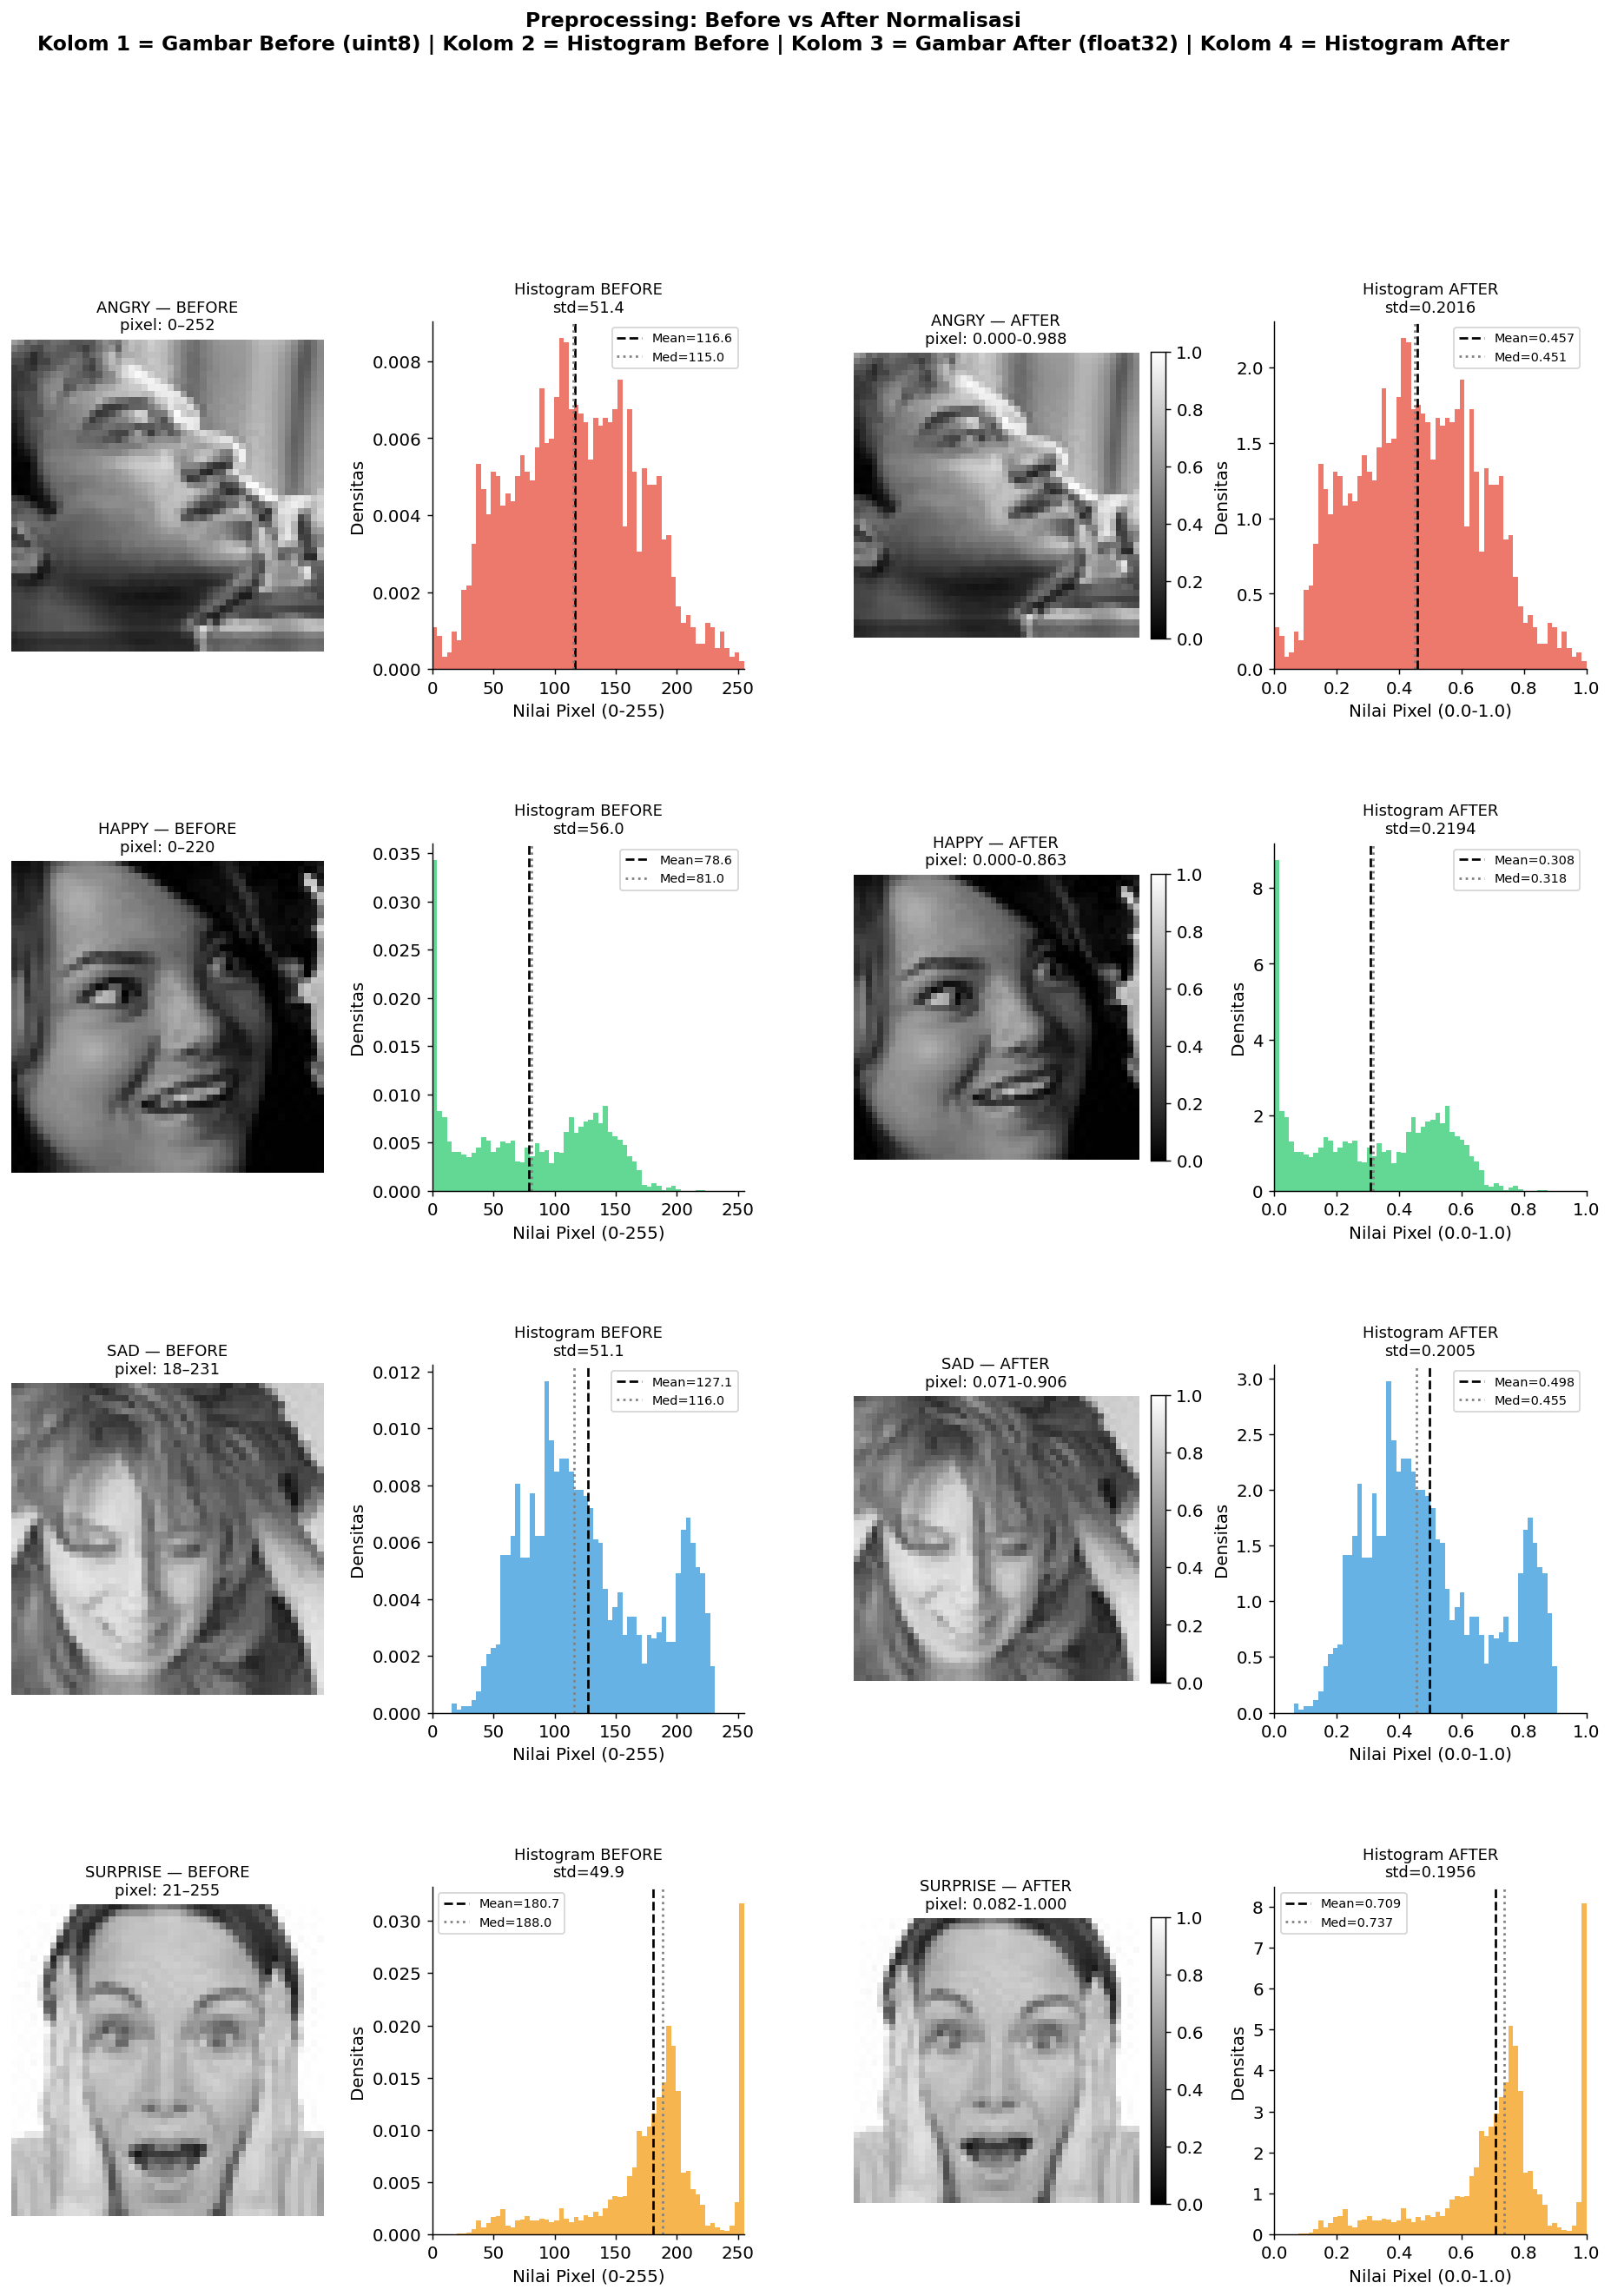

Disimpan: outputs\figures\01_before_after.png


In [38]:
#  CELL 1.2 — Visualisasi Before/After Normalisasi + Histogram

def get_sample_per_class(raw_list, norm_list, label_list, classes=CLASSES):
    return {
        cls: {'raw': raw_list[label_list.index(cls)],
              'norm': norm_list[label_list.index(cls)]}
        for cls in classes
    }

samples = get_sample_per_class(train_raw, train_norm, train_labels)

fig = plt.figure(figsize=(18, 5.5 * len(CLASSES)))
fig.suptitle(
    'Preprocessing: Before vs After Normalisasi\n'
    'Kolom 1 = Gambar Before (uint8) | Kolom 2 = Histogram Before | '
    'Kolom 3 = Gambar After (float32) | Kolom 4 = Histogram After',
    fontsize=13, fontweight='bold', y=1.005
)
gs = gridspec.GridSpec(len(CLASSES), 4, figure=fig, hspace=0.5, wspace=0.35)

for row, (cls, color) in enumerate(zip(CLASSES, COLORS)):
    img_raw  = samples[cls]['raw']
    img_norm = samples[cls]['norm']

    # Gambar BEFORE
    ax = fig.add_subplot(gs[row, 0])
    ax.imshow(img_raw, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'{cls.upper()} — BEFORE\npixel: {img_raw.min()}–{img_raw.max()}', fontsize=10)
    ax.axis('off')
    for sp in ax.spines.values():
        sp.set_visible(True); sp.set_edgecolor(color); sp.set_linewidth(2.5)

    # Histogram BEFORE
    ax = fig.add_subplot(gs[row, 1])
    ax.hist(img_raw.ravel(), bins=64, range=(0,255), color=color, alpha=0.75, density=True)
    ax.axvline(img_raw.mean(), color='black', lw=1.5, ls='--',
               label=f'Mean={img_raw.mean():.1f}')
    ax.axvline(np.median(img_raw), color='gray', lw=1.5, ls=':',
               label=f'Med={np.median(img_raw):.1f}')
    ax.set_title(f'Histogram BEFORE\nstd={img_raw.std():.1f}', fontsize=10)
    ax.set_xlabel('Nilai Pixel (0-255)'); ax.set_ylabel('Densitas')
    ax.legend(fontsize=8); ax.set_xlim(0, 255)

    # Gambar AFTER
    ax = fig.add_subplot(gs[row, 2])
    im = ax.imshow(img_norm, cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'{cls.upper()} — AFTER\npixel: {img_norm.min():.3f}-{img_norm.max():.3f}',
                 fontsize=10)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    for sp in ax.spines.values():
        sp.set_visible(True); sp.set_edgecolor(color); sp.set_linewidth(2.5)

    # Histogram AFTER
    ax = fig.add_subplot(gs[row, 3])
    ax.hist(img_norm.ravel(), bins=64, range=(0,1), color=color, alpha=0.75, density=True)
    ax.axvline(img_norm.mean(), color='black', lw=1.5, ls='--',
               label=f'Mean={img_norm.mean():.3f}')
    ax.axvline(np.median(img_norm), color='gray', lw=1.5, ls=':',
               label=f'Med={np.median(img_norm):.3f}')
    ax.set_title(f'Histogram AFTER\nstd={img_norm.std():.4f}', fontsize=10)
    ax.set_xlabel('Nilai Pixel (0.0-1.0)'); ax.set_ylabel('Densitas')
    ax.legend(fontsize=8); ax.set_xlim(0, 1)

plt.savefig(str(OUT_FIGS / '01_before_after.png'), bbox_inches='tight', dpi=150)
plt.show()
print("Disimpan:", OUT_FIGS / '01_before_after.png')


---
# BAGIAN 2 - Representasi Fitur: GLCM (Step-by-Step Lengkap)

---

## Apa itu GLCM?

**Gray-Level Co-occurrence Matrix (GLCM)** adalah matriks statistik tekstur yang  
merekam **seberapa sering dua piksel dengan nilai keabuan tertentu muncul bertetangga**  
pada jarak `d` dan arah `θ` tertentu.

> **Ide inti:** Bukan melihat nilai piksel satu per satu, melainkan  
> melihat **hubungan antar piksel yang berdekatan** — inilah yang disebut "tekstur".

```
GLCM[i][j] = berapa kali piksel bernilai i bersebelahan dengan piksel bernilai j
             (pada jarak d dan arah θ)
```

---

## Langkah 1 - Kuantisasi: Mengapa Diperlukan?

Gambar grayscale asli memiliki **256 nilai** (0–255).  
Jika langsung dipakai → GLCM berukuran **256 × 256 = 65.536 sel** → sangat jarang (*sparse*)!

**Solusi: Kuantisasi** — perkecil jumlah level ke 8, 16, atau 32:

```
Rumus: level = ⌊ pixel_norm × L ⌋   di mana L = jumlah level

Contoh (L = 8):
  pixel=200 → norm=0.784 → ⌊0.784 × 8⌋ = 6
  pixel= 90 → norm=0.353 → ⌊0.353 × 8⌋ = 2
  pixel= 30 → norm=0.118 → ⌊0.118 × 8⌋ = 0
```

| Level (L) | Ukuran GLCM | Sel Total | Karakteristik |
|:---------:|:-----------:|:---------:|:-------------|
| **8**     | 8 × 8       | 64        | Kasar, cepat, padat |
| **16**    | 16 × 16     | 256       | Keseimbangan terbaik |
| **32**    | 32 × 32     | 1.024     | Detail, tapi banyak sel kosong |
| 256       | 256 × 256   | 65.536    | Terlalu sparse |

---

## Langkah 2 - Membangun GLCM dari Nol (Ilustrasi 3×3)

**Contoh gambar 3×3 setelah kuantisasi 4-level:**

```
Gambar asli (0–255):    Setelah kuantisasi L=4:
┌─────────────────┐     ┌───────────┐
│ 200  150   80   │     │  3   2   1│
│ 120   90   60   │ →   │  2   1   0│
│  50   40   30   │     │  0   0   0│
└─────────────────┘     └───────────┘
```

**Sudut 0° (arah horizontal →), d=1:**  
Setiap piksel dipasangkan dengan tetangga di sebelah KANAN-nya:

```
Baris 0:  (3→2), (2→1)
Baris 1:  (2→1), (1→0)
Baris 2:  (0→0), (0→0)

Total pasangan: 6
Dengan symmetric=True, setiap pasangan (i→j) juga dihitung sebagai (j→i)
Total setelah symmetric: 12
```

**GLCM Frekuensi (sebelum dinormalisasi):**

```
        j=0  j=1  j=2  j=3
   i=0 [  4    1    0    0 ]   ← (0,0)×4 dari dua pasangan (0→0) + symmetric
   i=1 [  1    0    2    0 ]   ← (1,0)×1, (1,2)×2 (dari (2,1) symmetric)
   i=2 [  0    2    0    2 ]   ← (2,1)×2, (2,3)×2 (dari (3,2) symmetric)
   i=3 [  0    0    2    0 ]   ← (3,2)×2 symmetric
```

**GLCM Probabilitas (normed=True, dibagi 12):**

```
        j=0    j=1    j=2    j=3
   i=0 [0.333  0.083  0.000  0.000]
   i=1 [0.083  0.000  0.167  0.000]
   i=2 [0.000  0.167  0.000  0.167]
   i=3 [0.000  0.000  0.167  0.000]
                           Σ semua = 1.000 ✓
```

> **Diagonal tinggi** → banyak pasangan piksel yang bernilai sama → **tekstur halus/homogen**  
> **Off-diagonal tinggi** → banyak pasangan yang nilai berbeda jauh → **tekstur kasar/kontras**

---

## Langkah 3 - 4 Sudut untuk Rotational Invariance

GLCM dihitung untuk **4 arah** agar tidak bergantung pada orientasi gambar:

```
  Sudut 0°  → piksel tetangga di KANAN       (baris sama, kolom+1)
  Sudut 45° → piksel tetangga di KANAN-BAWAH (baris+1,  kolom+1)
  Sudut 90° → piksel tetangga di BAWAH       (baris+1,  kolom sama)
  Sudut 135°→ piksel tetangga di KIRI-BAWAH  (baris+1,  kolom-1)

  Parameter: symmetric=True → (i,j) dan (j,i) dihitung bersamaan
             normed=True    → dibagi total → probabilitas [0,1]
```

---

## Langkah 4 — Ekstraksi 4 Fitur Statistik

Dari matriks probabilitas `P(i,j)`, dihitung 4 properti:

---

### Fitur 1: CONTRAST

$$\text{Contrast} = \sum_{i,j} (i - j)^2 \cdot P(i,j)$$

**Cara kerja:**
- Setiap pasangan piksel `(i,j)` diberi **bobot `(i-j)²`**
- Piksel yang nilainya **sama** → `(i-j)²=0` → kontribusi **NOL**
- Piksel yang nilainya **sangat berbeda** → `(i-j)²` besar → kontribusi **BESAR**

```
Contoh manual dari matriks di atas:
  P(0,0)=0.333 → bobot (0-0)²=0   → kontribusi = 0.333 × 0   = 0.000
  P(1,0)=0.083 → bobot (1-0)²=1   → kontribusi = 0.083 × 1   = 0.083
  P(2,1)=0.167 → bobot (2-1)²=1   → kontribusi = 0.167 × 1   = 0.167
  P(3,2)=0.167 → bobot (3-2)²=1   → kontribusi = 0.167 × 1   = 0.167
  ...
  Contrast = Σ semua kontribusi
```

> **Wajah emosi**: Happy biasanya punya **Contrast lebih tinggi** (tepi mulut senyum tajam)  
> dibanding Sad yang lebih flat.

---

### Fitur 2: HOMOGENEITY (Inverse Difference Moment)

$$\text{Homogeneity} = \sum_{i,j} \frac{P(i,j)}{1 + |i - j|}$$

**Cara kerja:**
- Setiap pasangan `(i,j)` dibagi dengan `(1 + |i-j|)`
- Piksel **diagonal** `i=j` → penyebut `=1` → kontribusi **PENUH** = P(i,j)
- Piksel **jauh dari diagonal** → penyebut besar → kontribusi **KECIL**

```
Contoh:
  P(0,0)=0.333 → dibagi (1+|0-0|)=1 → kontribusi = 0.333
  P(1,0)=0.083 → dibagi (1+|1-0|)=2 → kontribusi = 0.042
  P(2,1)=0.167 → dibagi (1+|2-1|)=2 → kontribusi = 0.083
  P(3,2)=0.167 → dibagi (1+|3-2|)=2 → kontribusi = 0.083
  Homogeneity = Σ semua kontribusi
```

> **Homogeneity tinggi** → area wajah seragam (kulit polos) → tidak banyak variasi tekstur

---

### Fitur 3: ENERGY (Angular Second Moment)

$$\text{Energy} = \sum_{i,j} P(i,j)^2$$

**Cara kerja:**
- Setiap nilai probabilitas **dikuadratkan**, lalu dijumlah
- Jika GLCM memiliki **1 sel dominan** (nilai besar, sel lain kecil) → `P²` besar → Energy **tinggi**
- Jika GLCM **tersebar merata** di semua sel → tiap `P` kecil → `P²` sangat kecil → Energy **rendah**

```
Contoh:
  P(0,0)=0.333 → 0.333² = 0.111
  P(1,0)=0.083 → 0.083² = 0.007
  P(2,1)=0.167 → 0.167² = 0.028
  ...
  Energy = 0.111 + 0.007 + 0.028 + ... = Σ P²
```

> **Energy tinggi** → tekstur sangat seragam/berulang (seperti dahi polos)  
> **Energy rendah** → tekstur kompleks dan bervariasi (seperti area mulut saat senyum)

---

### Fitur 4: CORRELATION

$$\text{Correlation} = \sum_{i,j} \frac{(i - \mu_i)(j - \mu_j) \cdot P(i,j)}{\sigma_i \cdot \sigma_j}$$

Di mana `μ` = mean dan `σ` = standar deviasi distribusi marginal GLCM:

```
μᵢ = Σᵢ [ i × P(i,:) ]     (rata-rata level baris)
σᵢ = √[ Σᵢ (i−μᵢ)² × P(i,:) ]  (std dev level baris)

μⱼ dan σⱼ sama untuk kolom (karena symmetric)
```

**Cara kerja:**
- Mengukur **seberapa linear hubungan** antara level piksel `i` dan tetangganya `j`
- Jika piksel terang selalu bertetangga dengan piksel terang → **Correlation tinggi (mendekati +1)**
- Jika hubungan acak → **Correlation mendekati 0**
- Range: **-1 sampai +1**

```
Contoh:
  Hitung μi dan σi dulu dari distribusi marginal P(i,:)
  Kemudian untuk setiap (i,j) yang nonzero:
    contrib = (i - μi) × (j - μj) × P(i,j)
  Bagi total dengan (σi × σj)
```

> **Correlation tinggi** → ada pola gradasi yang konsisten (seperti bayangan di wajah)

---

## Langkah 5 — Agregasi: Mean vs Concat

Setelah mendapat 4 nilai per fitur × 4 sudut = **16 angka total**:

```
             0°      45°     90°    135°
Contrast:  [0.42,   0.38,   0.45,  0.40]
Homog:     [0.71,   0.73,   0.70,  0.72]
Energy:    [0.08,   0.09,   0.07,  0.08]
Corr:      [0.89,   0.87,   0.88,  0.90]
```

**Strategi MEAN (→ 4D):**
```
Rata-rata tiap baris:
  Contrast_mean    = (0.42+0.38+0.45+0.40)/4 = 0.413
  Homog_mean       = (0.71+0.73+0.70+0.72)/4 = 0.715
  Energy_mean      = (0.08+0.09+0.07+0.08)/4 = 0.080
  Corr_mean        = (0.89+0.87+0.88+0.90)/4 = 0.885

Vektor fitur = [0.413, 0.715, 0.080, 0.885]  ← 4 angka saja
Rotational invariant (gambar diputar → fitur sama)
```

**Strategi CONCAT (→ 16D):**
```
Gabungkan semua nilai:
  [0.42, 0.38, 0.45, 0.40,   ← Contrast 4 sudut
   0.71, 0.73, 0.70, 0.72,   ← Homogeneity 4 sudut
   0.08, 0.09, 0.07, 0.08,   ← Energy 4 sudut
   0.89, 0.87, 0.88, 0.90]   ← Correlation 4 sudut

Vektor fitur = 16 angka
Menyimpan informasi orientasi tekstur
Sensitif rotasi, risiko overfitting lebih tinggi
```

| Aspek | MEAN (4D) | CONCAT (16D) |
|:------|:---------:|:------------:|
| Dimensi | 4 | 16 |
| Rotasi gambar | Fitur SAMA | Fitur BEDA |
| Info arah tekstur | Hilang | Tersimpan |
| Risiko overfitting | Rendah | Lebih tinggi |
| Rekomendasi | Foto frontal seragam | Jika orientasi penting |

---

## Pipeline Lengkap

```
Gambar Asli (uint8, 48×48, 0–255)
         │
         │ ÷ 255.0
         ▼
Gambar Ternormalisasi (float32, 0–1)
         │
         │ ⌊pixel × L⌋  (L = jumlah level)
         ▼
Gambar Terkuantisasi (int, 0 … L-1)
         │
         │ graycomatrix(distances=[1], angles=[0°,45°,90°,135°],
         │              symmetric=True, normed=True)
         ▼
GLCM per Sudut: shape = (L, L, 1, 4)
         │
         │ graycoprops(glcm, 'contrast')   → shape (1,4) → 4 nilai
         │ graycoprops(glcm, 'homogeneity')
         │ graycoprops(glcm, 'energy')
         │ graycoprops(glcm, 'correlation')
         ▼
16 Nilai Fitur (4 properti × 4 sudut)
         │
         ├─── agregasi MEAN   → Vektor 4D  (input Logistic Regression)
         └─── agregasi CONCAT → Vektor 16D (input Logistic Regression)
```


In [39]:
#  CELL 2.0 — Fungsi Inti GLCM (Kuantisasi + Ekstraksi)

def quantize_image(img_norm, levels):
    """
    Kuantisasi gambar float [0,1] → integer [0, levels-1].

    Cara kerja:
      pixel_norm x levels  →  ambil floor  →  clip ke [0, levels-1]
    Contoh (levels=16):
      0.75 → floor(0.75*16) = 12   (level ke-12 dari 0..15)
      1.00 → clip(16) = 15         (bukan 16, agar tidak out-of-bounds)
    """
    return np.clip(np.floor(img_norm * levels).astype(np.int32), 0, levels - 1)


def extract_glcm_features(img_norm, levels,
                           distances=DISTANCES, angles=ANGLES,
                           props=GLCM_PROPS, aggregation='mean'):
    """
    Ekstrak vektor fitur GLCM dari gambar grayscale.

    aggregation='mean'   → rata-rata 4 sudut → vektor 4D
    aggregation='concat' → concatenate 4 sudut → vektor 16D

    Returns
    -------
    feature_vector : np.ndarray  Vektor fitur 1D
    glcm_raw       : np.ndarray  Matriks GLCM mentah (L,L,1,4)
    """
    img_q = quantize_image(img_norm, levels)
    glcm  = graycomatrix(
        img_q,
        distances=distances, angles=angles, levels=levels,
        symmetric=True,   # GLCM(i,j) + GLCM(j,i) → simetris, lebih stabil
        normed=True       # Bagi total → nilai probabilitas [0,1]
    )
    feature_vector = []
    if aggregation == 'mean':
        for prop in props:
            feature_vector.append(graycoprops(glcm, prop).mean())
    elif aggregation == 'concat':
        for prop in props:
            feature_vector.extend(graycoprops(glcm, prop).flatten())
    return np.array(feature_vector, dtype=np.float32), glcm


def compute_coherence_matrix(glcm_4d, aggregation='mean'):
    """
    Hitung Matriks Koheren = agregasi GLCM dari semua sudut.

    C(i,j) = (1/n_angles) x Σ_θ GLCM_θ(i,j)

    Matriks ini merepresentasikan pola ko-okurens yang
    bersifat 'rotational invariant' (tidak bergantung arah).

    Returns
    -------
    coherence : np.ndarray  Shape (L, L)
    """
    glcm_3d = glcm_4d[:, :, 0, :]   # (L, L, n_angles)
    if aggregation == 'mean':
        return glcm_3d.mean(axis=-1)
    elif aggregation == 'max':
        return glcm_3d.max(axis=-1)
    return glcm_3d.mean(axis=-1)


# Test fungsi
feat_test, glcm_test = extract_glcm_features(train_norm[0], levels=16, aggregation='mean')
print("Fungsi GLCM berjalan normal.")
print(f"   Fitur (mean, L=16) : {np.round(feat_test, 4)}")
print(f"   Shape GLCM         : {glcm_test.shape}  ← (levels, levels, 1, 4_sudut)")
print(f"\n   Interpretasi fitur pertama:")
for prop, val in zip(GLCM_PROPS, feat_test):
    print(f"   {prop:15s} = {val:.6f}")


Fungsi GLCM berjalan normal.
   Fitur (mean, L=16) : [3.1174 0.6112 0.145  0.8499]
   Shape GLCM         : (16, 16, 1, 4)  ← (levels, levels, 1, 4_sudut)

   Interpretasi fitur pertama:
   contrast        = 3.117408
   homogeneity     = 0.611172
   energy          = 0.145018
   correlation     = 0.849857


## STEP A — Gambar Asli + Histogram Distribusi Intensitas

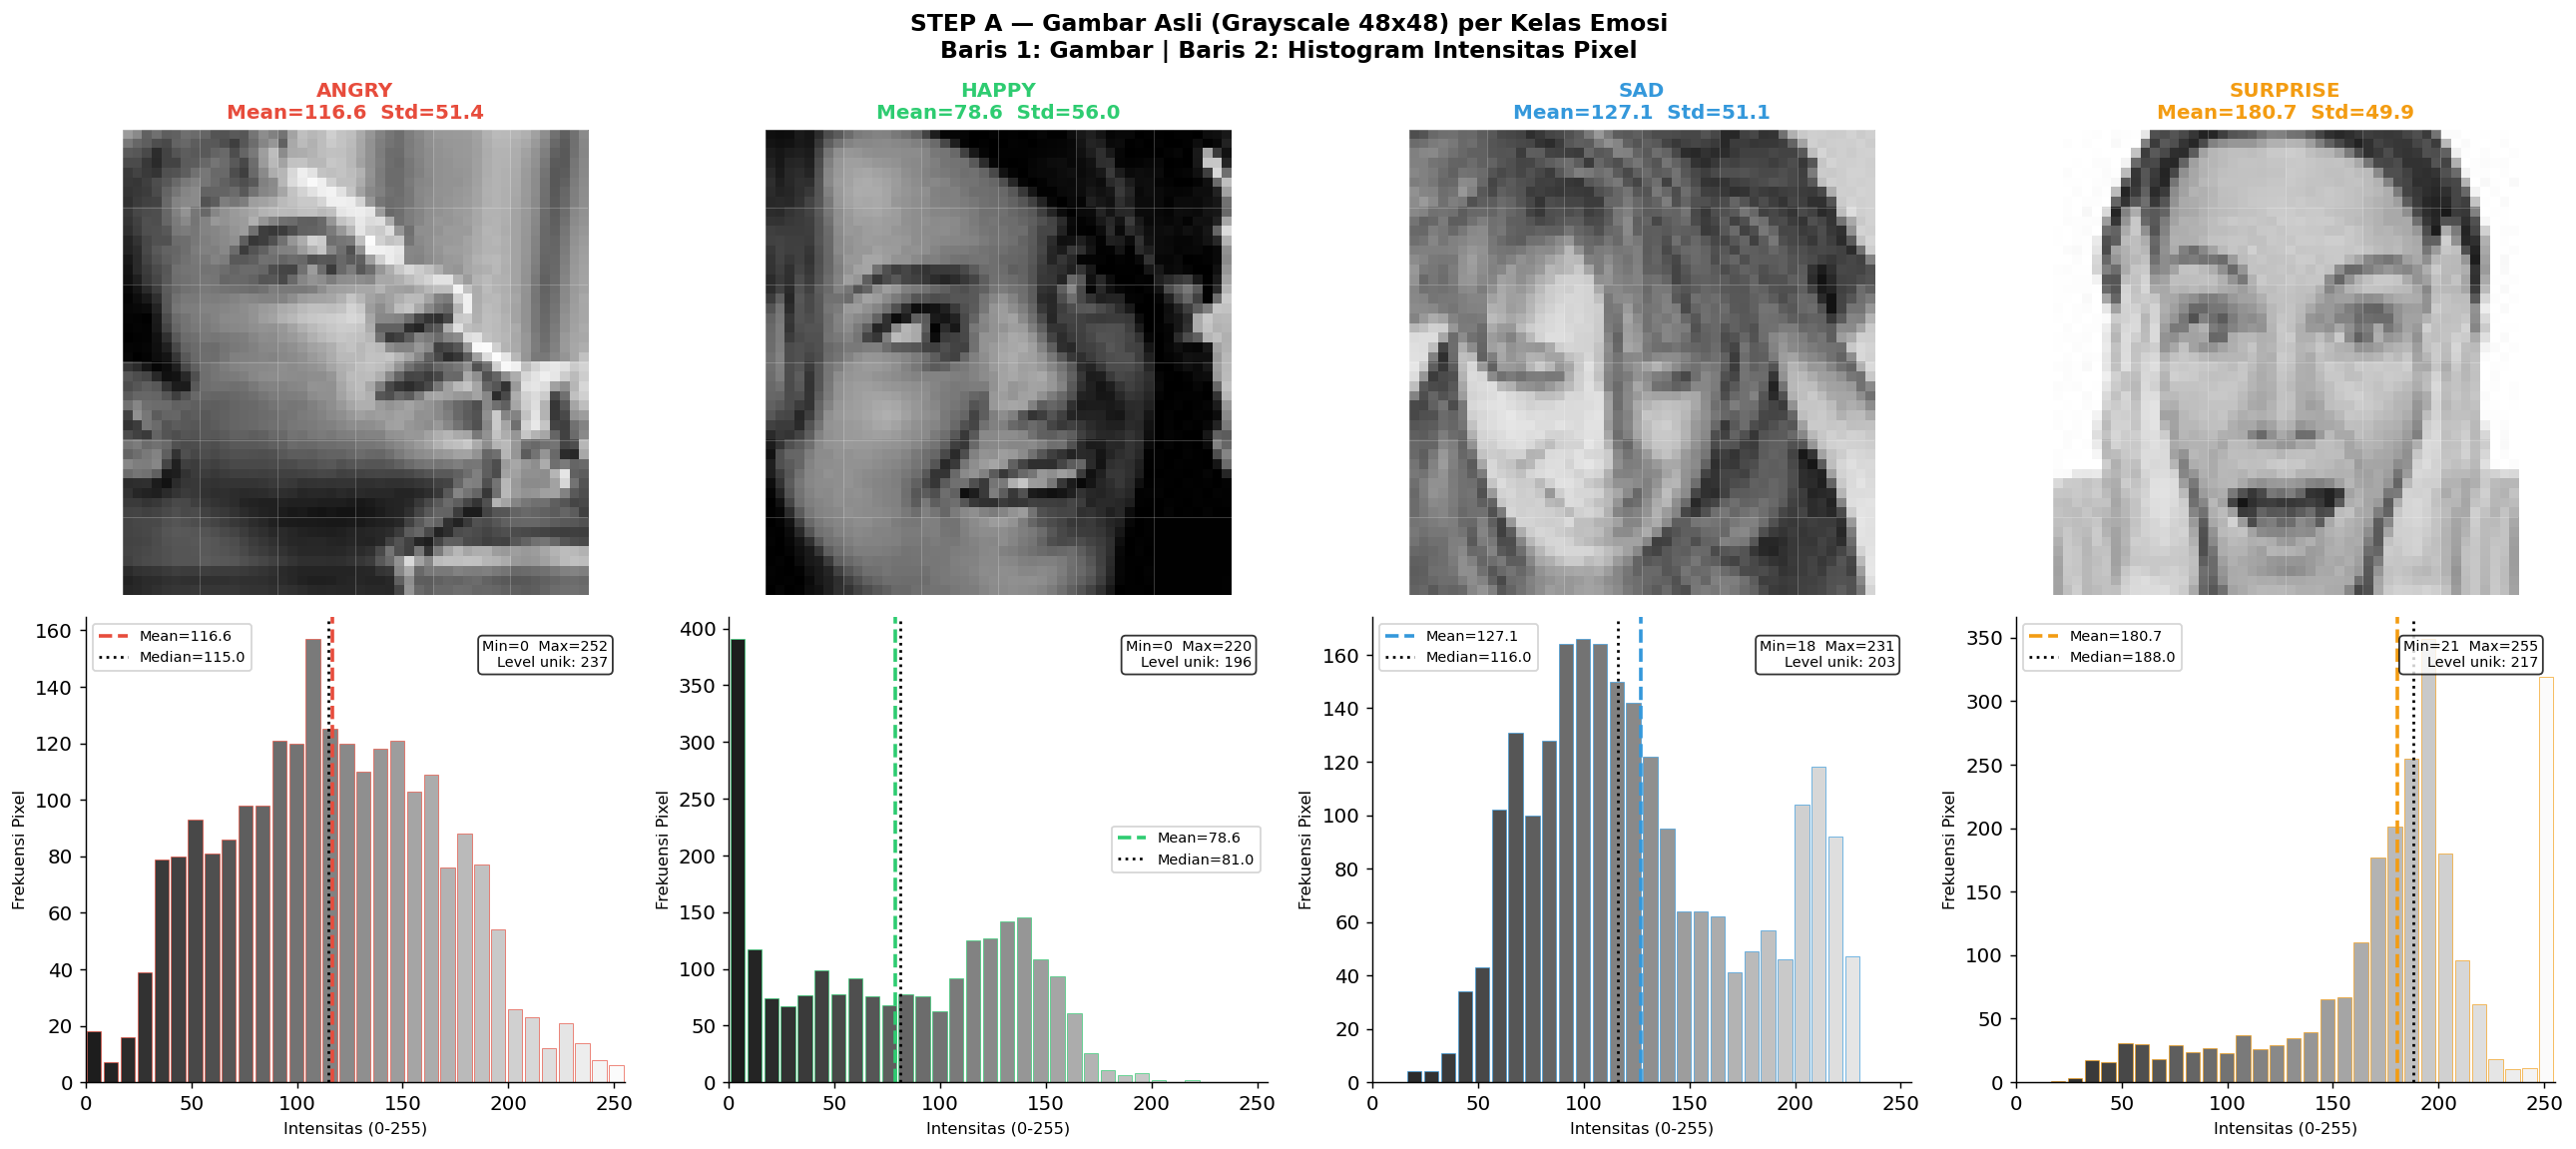

Disimpan: outputs\figures\02_step_a_gambar_asli.png


In [40]:
#  CELL 2.1 — STEP A: Gambar Asli per Kelas

fig, axes = plt.subplots(2, len(CLASSES), figsize=(5*len(CLASSES), 9))
fig.suptitle(
    'STEP A — Gambar Asli (Grayscale 48x48) per Kelas Emosi\n'
    'Baris 1: Gambar | Baris 2: Histogram Intensitas Pixel',
    fontsize=13, fontweight='bold'
)

for col, (cls, color) in enumerate(zip(CLASSES, COLORS)):
    img_raw = samples[cls]['raw']

    # Baris 0: Gambar
    ax = axes[0, col]
    ax.imshow(img_raw, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'{cls.upper()}\n'
                 f'Mean={img_raw.mean():.1f}  Std={img_raw.std():.1f}',
                 fontsize=11, color=color, fontweight='bold')
    ax.axis('off')
    for sp in ax.spines.values():
        sp.set_visible(True); sp.set_edgecolor(color); sp.set_linewidth(3)

    # Overlay grid koordinat 
    for x in range(0, 49, 8):
        ax.axvline(x - 0.5, color='white', lw=0.3, alpha=0.4)
    for y in range(0, 49, 8):
        ax.axhline(y - 0.5, color='white', lw=0.3, alpha=0.4)

    # Baris 1: Histogram
    ax = axes[1, col]
    hist_vals, bin_edges = np.histogram(img_raw.ravel(), bins=32, range=(0,255))
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # Warna bar berdasarkan intensitas (grayscale)
    for bv, bc in zip(hist_vals, bin_centers):
        gv = bc / 255.0
        ax.bar(bc, bv, width=(bin_edges[1]-bin_edges[0])*0.85,
               color=(gv, gv, gv), edgecolor=color, linewidth=0.4, alpha=0.9)

    ax.axvline(img_raw.mean(),      color=color,   lw=2, ls='--',
               label=f'Mean={img_raw.mean():.1f}')
    ax.axvline(np.median(img_raw),  color='black', lw=1.5, ls=':',
               label=f'Median={np.median(img_raw):.1f}')

    ax.set_xlabel('Intensitas (0-255)', fontsize=9)
    ax.set_ylabel('Frekuensi Pixel', fontsize=9)
    ax.set_xlim(0, 255)
    ax.legend(fontsize=8)

    # Anotasi statistik
    stats = (f"Min={img_raw.min()}  Max={img_raw.max()}\n"
             f"Level unik: {len(np.unique(img_raw))}")
    ax.text(0.97, 0.95, stats, transform=ax.transAxes,
            va='top', ha='right', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(str(OUT_FIGS / '02_step_a_gambar_asli.png'), bbox_inches='tight', dpi=150)
plt.show()
print("Disimpan:", OUT_FIGS / '02_step_a_gambar_asli.png')


## STEP B - Matriks Keabuan: Nilai Pixel & Kuantisasi

Sebelum membangun GLCM, gambar harus **dikuantisasi** ke jumlah level yang lebih kecil.

> **Mengapa Kuantisasi?**  
> Gambar 256-level → GLCM **256×256 = 65.536 sel** (sangat jarang/sparse).  
> Dengan kuantisasi ke 16 level → GLCM **16×16 = 256 sel** (lebih padat, informatif).

**Rumus:** `level = ⌊pixel_norm × L⌋`  clipped ke `[0, L-1]`


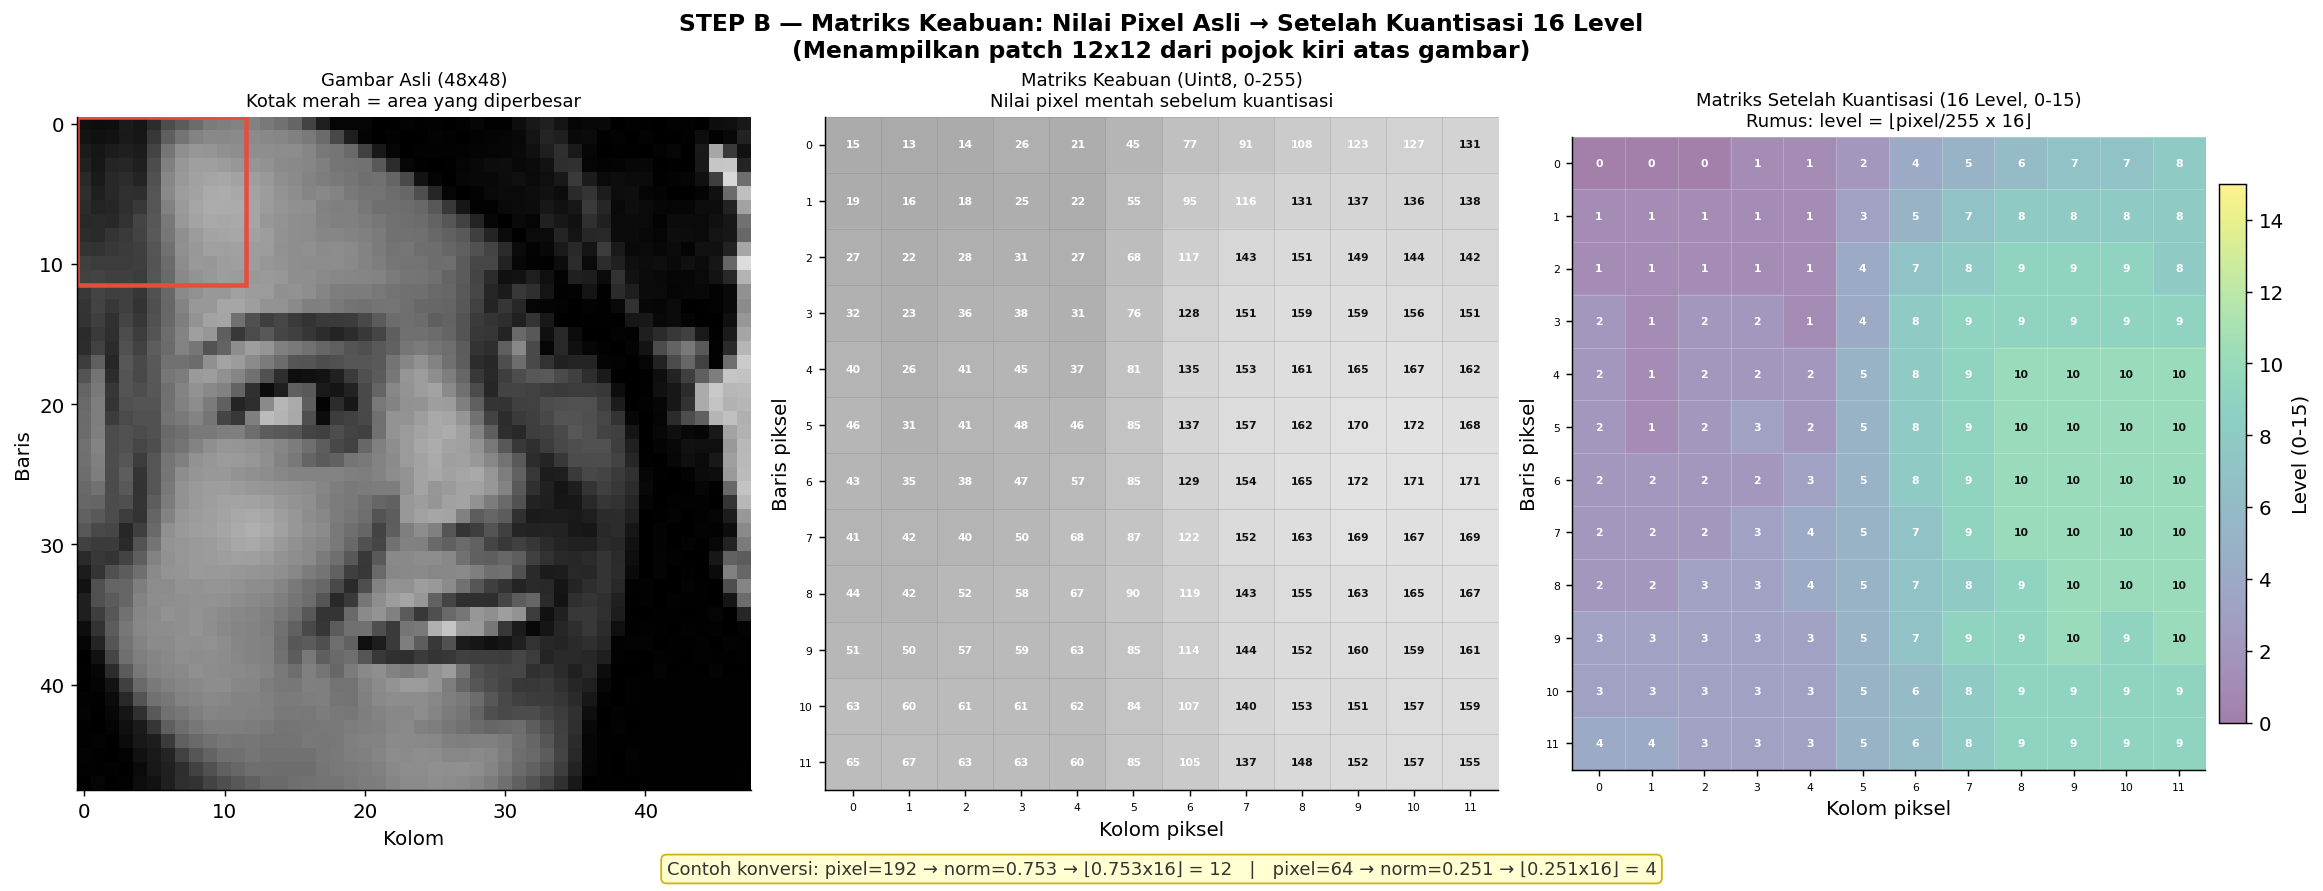

Disimpan: outputs\figures\03_step_b_matriks_keabuan.png


In [41]:
#  CELL 2.2 — STEP B: Matriks Keabuan (Pixel Grid + Kuantisasi)

LEVELS_DEMO = 16
GRID_SZ     = 12   # Tampilkan patch 12×12 agar angka terbaca

# Ambil gambar contoh 'happy'
idx_ex   = train_labels.index('happy')
img_raw_ex  = train_raw[idx_ex]
img_norm_ex = train_norm[idx_ex]
img_q_ex    = quantize_image(img_norm_ex, LEVELS_DEMO)

# Ambil patch kiri atas
patch_raw = img_raw_ex[:GRID_SZ, :GRID_SZ]
patch_q   = img_q_ex[:GRID_SZ, :GRID_SZ]

fig, axes = plt.subplots(1, 3, figsize=(18, 6.5))
fig.suptitle(
    f'STEP B — Matriks Keabuan: Nilai Pixel Asli → Setelah Kuantisasi {LEVELS_DEMO} Level\n'
    f'(Menampilkan patch {GRID_SZ}x{GRID_SZ} dari pojok kiri atas gambar)',
    fontsize=13, fontweight='bold'
)

tick_lbl = [str(i) for i in range(GRID_SZ)]

# Panel 1: Gambar Patch
ax = axes[0]
ax.imshow(img_raw_ex, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
rect = mpatches.Rectangle((0-0.5, 0-0.5), GRID_SZ, GRID_SZ,
                            linewidth=2.5, edgecolor='#e74c3c', facecolor='none')
ax.add_patch(rect)
ax.set_title(f'Gambar Asli (48x48)\nKotak merah = area yang diperbesar',
             fontsize=10)
ax.set_xlabel('Kolom'); ax.set_ylabel('Baris')

# Panel 2: Nilai uint8 (matriks angka)
ax = axes[1]
ax.imshow(patch_raw, cmap='gray', vmin=0, vmax=255,
          interpolation='nearest', aspect='equal', alpha=0.35)
for i in range(GRID_SZ):
    for j in range(GRID_SZ):
        val    = patch_raw[i, j]
        tcolor = 'white' if val < 128 else '#111'
        ax.text(j, i, str(val), ha='center', va='center',
                fontsize=6, color=tcolor, fontweight='bold')
for x in range(-1, GRID_SZ):
    ax.axvline(x+0.5, color='gray', lw=0.3, alpha=0.5)
for y in range(-1, GRID_SZ):
    ax.axhline(y+0.5, color='gray', lw=0.3, alpha=0.5)
ax.set_xticks(range(GRID_SZ)); ax.set_xticklabels(tick_lbl, fontsize=6)
ax.set_yticks(range(GRID_SZ)); ax.set_yticklabels(tick_lbl, fontsize=6)
ax.set_title(f'Matriks Keabuan (Uint8, 0-255)\nNilai pixel mentah sebelum kuantisasi',
             fontsize=10)
ax.set_xlabel('Kolom piksel'); ax.set_ylabel('Baris piksel')

# Panel 3: Nilai setelah kuantisasi
ax = axes[2]
cmap_q = plt.cm.viridis
norm_q = plt.Normalize(vmin=0, vmax=LEVELS_DEMO - 1)
im_q   = ax.imshow(patch_q, cmap='viridis', vmin=0, vmax=LEVELS_DEMO-1,
                   interpolation='nearest', aspect='equal', alpha=0.5)
for i in range(GRID_SZ):
    for j in range(GRID_SZ):
        val  = patch_q[i, j]
        rgba = cmap_q(norm_q(val))
        lum  = 0.299*rgba[0] + 0.587*rgba[1] + 0.114*rgba[2]
        tcolor = 'white' if lum < 0.5 else '#111'
        ax.text(j, i, str(val), ha='center', va='center',
                fontsize=6, color=tcolor, fontweight='bold')
for x in range(-1, GRID_SZ):
    ax.axvline(x+0.5, color='white', lw=0.3, alpha=0.4)
for y in range(-1, GRID_SZ):
    ax.axhline(y+0.5, color='white', lw=0.3, alpha=0.4)
ax.set_xticks(range(GRID_SZ)); ax.set_xticklabels(tick_lbl, fontsize=6)
ax.set_yticks(range(GRID_SZ)); ax.set_yticklabels(tick_lbl, fontsize=6)
ax.set_title(f'Matriks Setelah Kuantisasi ({LEVELS_DEMO} Level, 0-{LEVELS_DEMO-1})\n'
             f'Rumus: level = ⌊pixel/255 x {LEVELS_DEMO}⌋',
             fontsize=10)
ax.set_xlabel('Kolom piksel'); ax.set_ylabel('Baris piksel')
plt.colorbar(im_q, ax=ax, fraction=0.04, pad=0.02,
             label=f'Level (0-{LEVELS_DEMO-1})')

# Anotasi rumus di bawah
fig.text(0.5, -0.04,
         f'Contoh konversi: pixel=192 → norm=0.753 → ⌊0.753x{LEVELS_DEMO}⌋ = '
         f'{int(np.floor(192/255*LEVELS_DEMO))}   |   '
         f'pixel=64 → norm=0.251 → ⌊0.251x{LEVELS_DEMO}⌋ = '
         f'{int(np.floor(64/255*LEVELS_DEMO))}',
         ha='center', fontsize=10, color='#333',
         bbox=dict(boxstyle='round', facecolor='#ffffcc', edgecolor='#ccaa00', alpha=0.9))

plt.tight_layout()
plt.savefig(str(OUT_FIGS / '03_step_b_matriks_keabuan.png'), bbox_inches='tight', dpi=150)
plt.show()
print("Disimpan:", OUT_FIGS / '03_step_b_matriks_keabuan.png')


## STEP C - Matriks Koheren (Coherence Matrix): Gambaran Umum

**Matriks Koheren** adalah agregasi rata-rata GLCM dari semua sudut.  
Ini memberikan gambaran umum pola ko-okurens yang bersifat *rotational invariant*.

$$C(i,j) = \frac{1}{|\Theta|} \sum_{\theta \in \Theta} \text{GLCM}_{\theta}(i,j)$$

**Interpretasi:**
- **Nilai diagonal tinggi** → piksel cenderung bersebelahan dengan piksel bernilai sama (homogen)
- **Off-diagonal tinggi** → banyak transisi tajam antar level
- **Σ seluruh elemen ≈ 1.0** (karena `normed=True`)


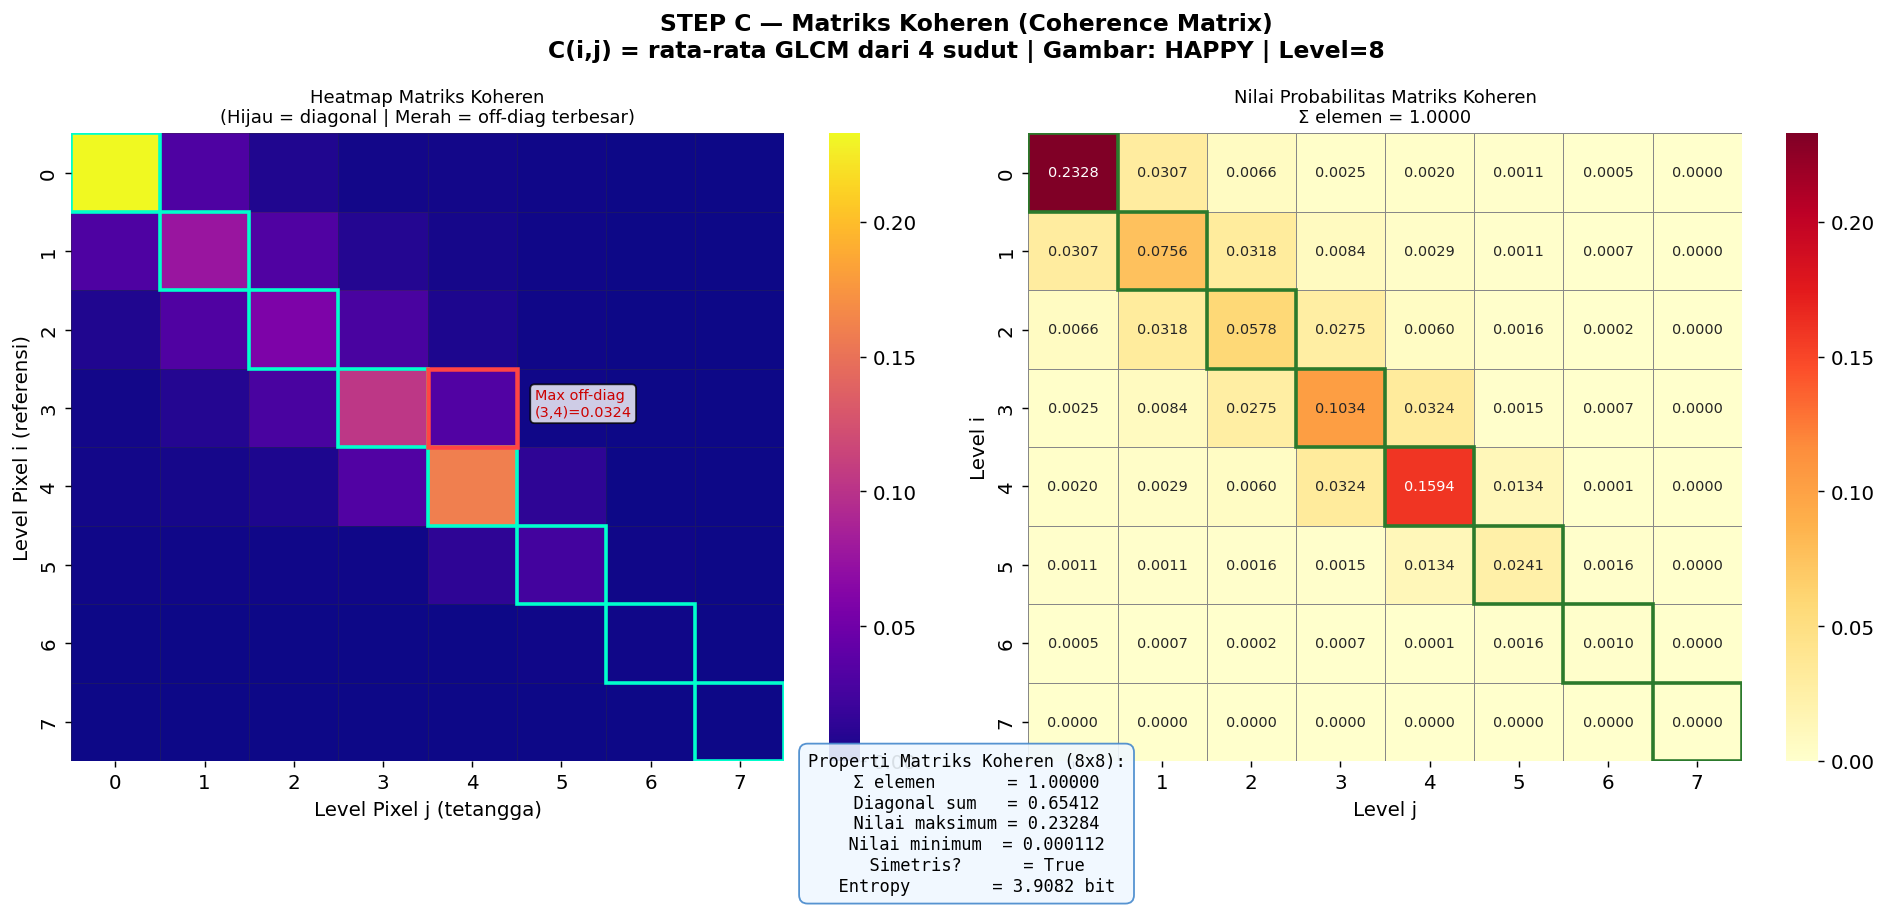

Disimpan: outputs\figures\04_step_c_coherence_overview.png


In [42]:
#  CELL 2.3 — STEP C: Matriks Koheren Overview

LEVELS_VIS = 8   # 8 level agar angka muat di tabel

img_q_vis = quantize_image(img_norm_ex, LEVELS_VIS)
glcm_ex   = graycomatrix(
    img_q_vis,
    distances=[1], angles=ANGLES, levels=LEVELS_VIS,
    symmetric=True, normed=True
)

# Coherence Matrix
coherence_mat = compute_coherence_matrix(glcm_ex, aggregation='mean')
tick_labels_v = [str(i) for i in range(LEVELS_VIS)]

# Properti per sudut untuk anotasi
props_per_angle = {prop: graycoprops(glcm_ex, prop)[0] for prop in GLCM_PROPS}

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
fig.suptitle(
    f'STEP C — Matriks Koheren (Coherence Matrix)\n'
    f'C(i,j) = rata-rata GLCM dari 4 sudut | Gambar: HAPPY | Level={LEVELS_VIS}',
    fontsize=13, fontweight='bold'
)

# Panel 1: Heatmap penuh
ax = axes[0]
sns.heatmap(
    coherence_mat, ax=ax, cmap='plasma',
    xticklabels=tick_labels_v, yticklabels=tick_labels_v,
    linewidths=0.4, linecolor='#33333355', cbar=True, annot=False
)
# Highlight diagonal
for i in range(LEVELS_VIS):
    ax.add_patch(mpatches.Rectangle((i, i), 1, 1, fill=False,
                                     edgecolor='#00ffcc', lw=2))
# Sel maksimum off-diagonal
off_d = coherence_mat.copy(); np.fill_diagonal(off_d, 0)
mi = np.unravel_index(off_d.argmax(), off_d.shape)
ax.add_patch(mpatches.Rectangle((mi[1], mi[0]), 1, 1, fill=False,
                                  edgecolor='#ff4444', lw=2.5))
ax.text(mi[1]+1.2, mi[0]+0.6, f'Max off-diag\n({mi[0]},{mi[1]})={off_d[mi]:.4f}',
        color='#cc0000', fontsize=8,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.set_title('Heatmap Matriks Koheren\n(Hijau = diagonal | Merah = off-diag terbesar)',
             fontsize=10)
ax.set_xlabel('Level Pixel j (tetangga)'); ax.set_ylabel('Level Pixel i (referensi)')

# Panel 2: Angka detail
ax = axes[1]
sns.heatmap(
    coherence_mat, ax=ax, annot=True, fmt='.4f', cmap='YlOrRd',
    xticklabels=tick_labels_v, yticklabels=tick_labels_v,
    linewidths=0.5, linecolor='#888', cbar=True,
    annot_kws={'size': 8}
)
for i in range(LEVELS_VIS):
    ax.add_patch(mpatches.Rectangle((i, i), 1, 1, fill=False,
                                     edgecolor='#2c7a2c', lw=2))
ax.set_title(f'Nilai Probabilitas Matriks Koheren\nΣ elemen = {coherence_mat.sum():.4f}',
             fontsize=10)
ax.set_xlabel('Level j'); ax.set_ylabel('Level i')

# Statistik ringkas
stats_txt = (
    f"Properti Matriks Koheren ({LEVELS_VIS}x{LEVELS_VIS}):\n"
    f"  Σ elemen       = {coherence_mat.sum():.5f}\n"
    f"  Diagonal sum   = {np.trace(coherence_mat):.5f}\n"
    f"  Nilai maksimum = {coherence_mat.max():.5f}\n"
    f"  Nilai minimum  = {coherence_mat[coherence_mat>0].min():.6f}\n"
    f"  Simetris?      = {np.allclose(coherence_mat, coherence_mat.T)}\n"
    f"  Entropy        = {-np.sum(coherence_mat * np.log2(coherence_mat+1e-12)):.4f} bit"
)
fig.text(0.5, -0.06, stats_txt, ha='center', fontsize=9.5,
         fontfamily='monospace',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#f0f8ff', edgecolor='#4488cc', alpha=0.9))

plt.tight_layout()
plt.savefig(str(OUT_FIGS / '04_step_c_coherence_overview.png'), bbox_inches='tight', dpi=150)
plt.show()
print("Disimpan:", OUT_FIGS / '04_step_c_coherence_overview.png')


## STEP D - Semua GLCM per Sudut (4 Sudut × 2 Format)

GLCM dihitung untuk **4 arah** agar hasil tidak bergantung pada orientasi gambar:

| Sudut | Arah | Piksel Tetangga |
|---|---|---|
| 0° | Horizontal → | Kanan |
| 45° | Diagonal ↘ | Kanan-Bawah |
| 90° | Vertikal ↓ | Bawah |
| 135° | Diagonal ↙ | Kiri-Bawah |

**Format visualisasi:**
- **Baris 1**: Heatmap warna → mudah melihat pola distribusi
- **Baris 2**: Nilai angka → verifikasi probabilitas eksak


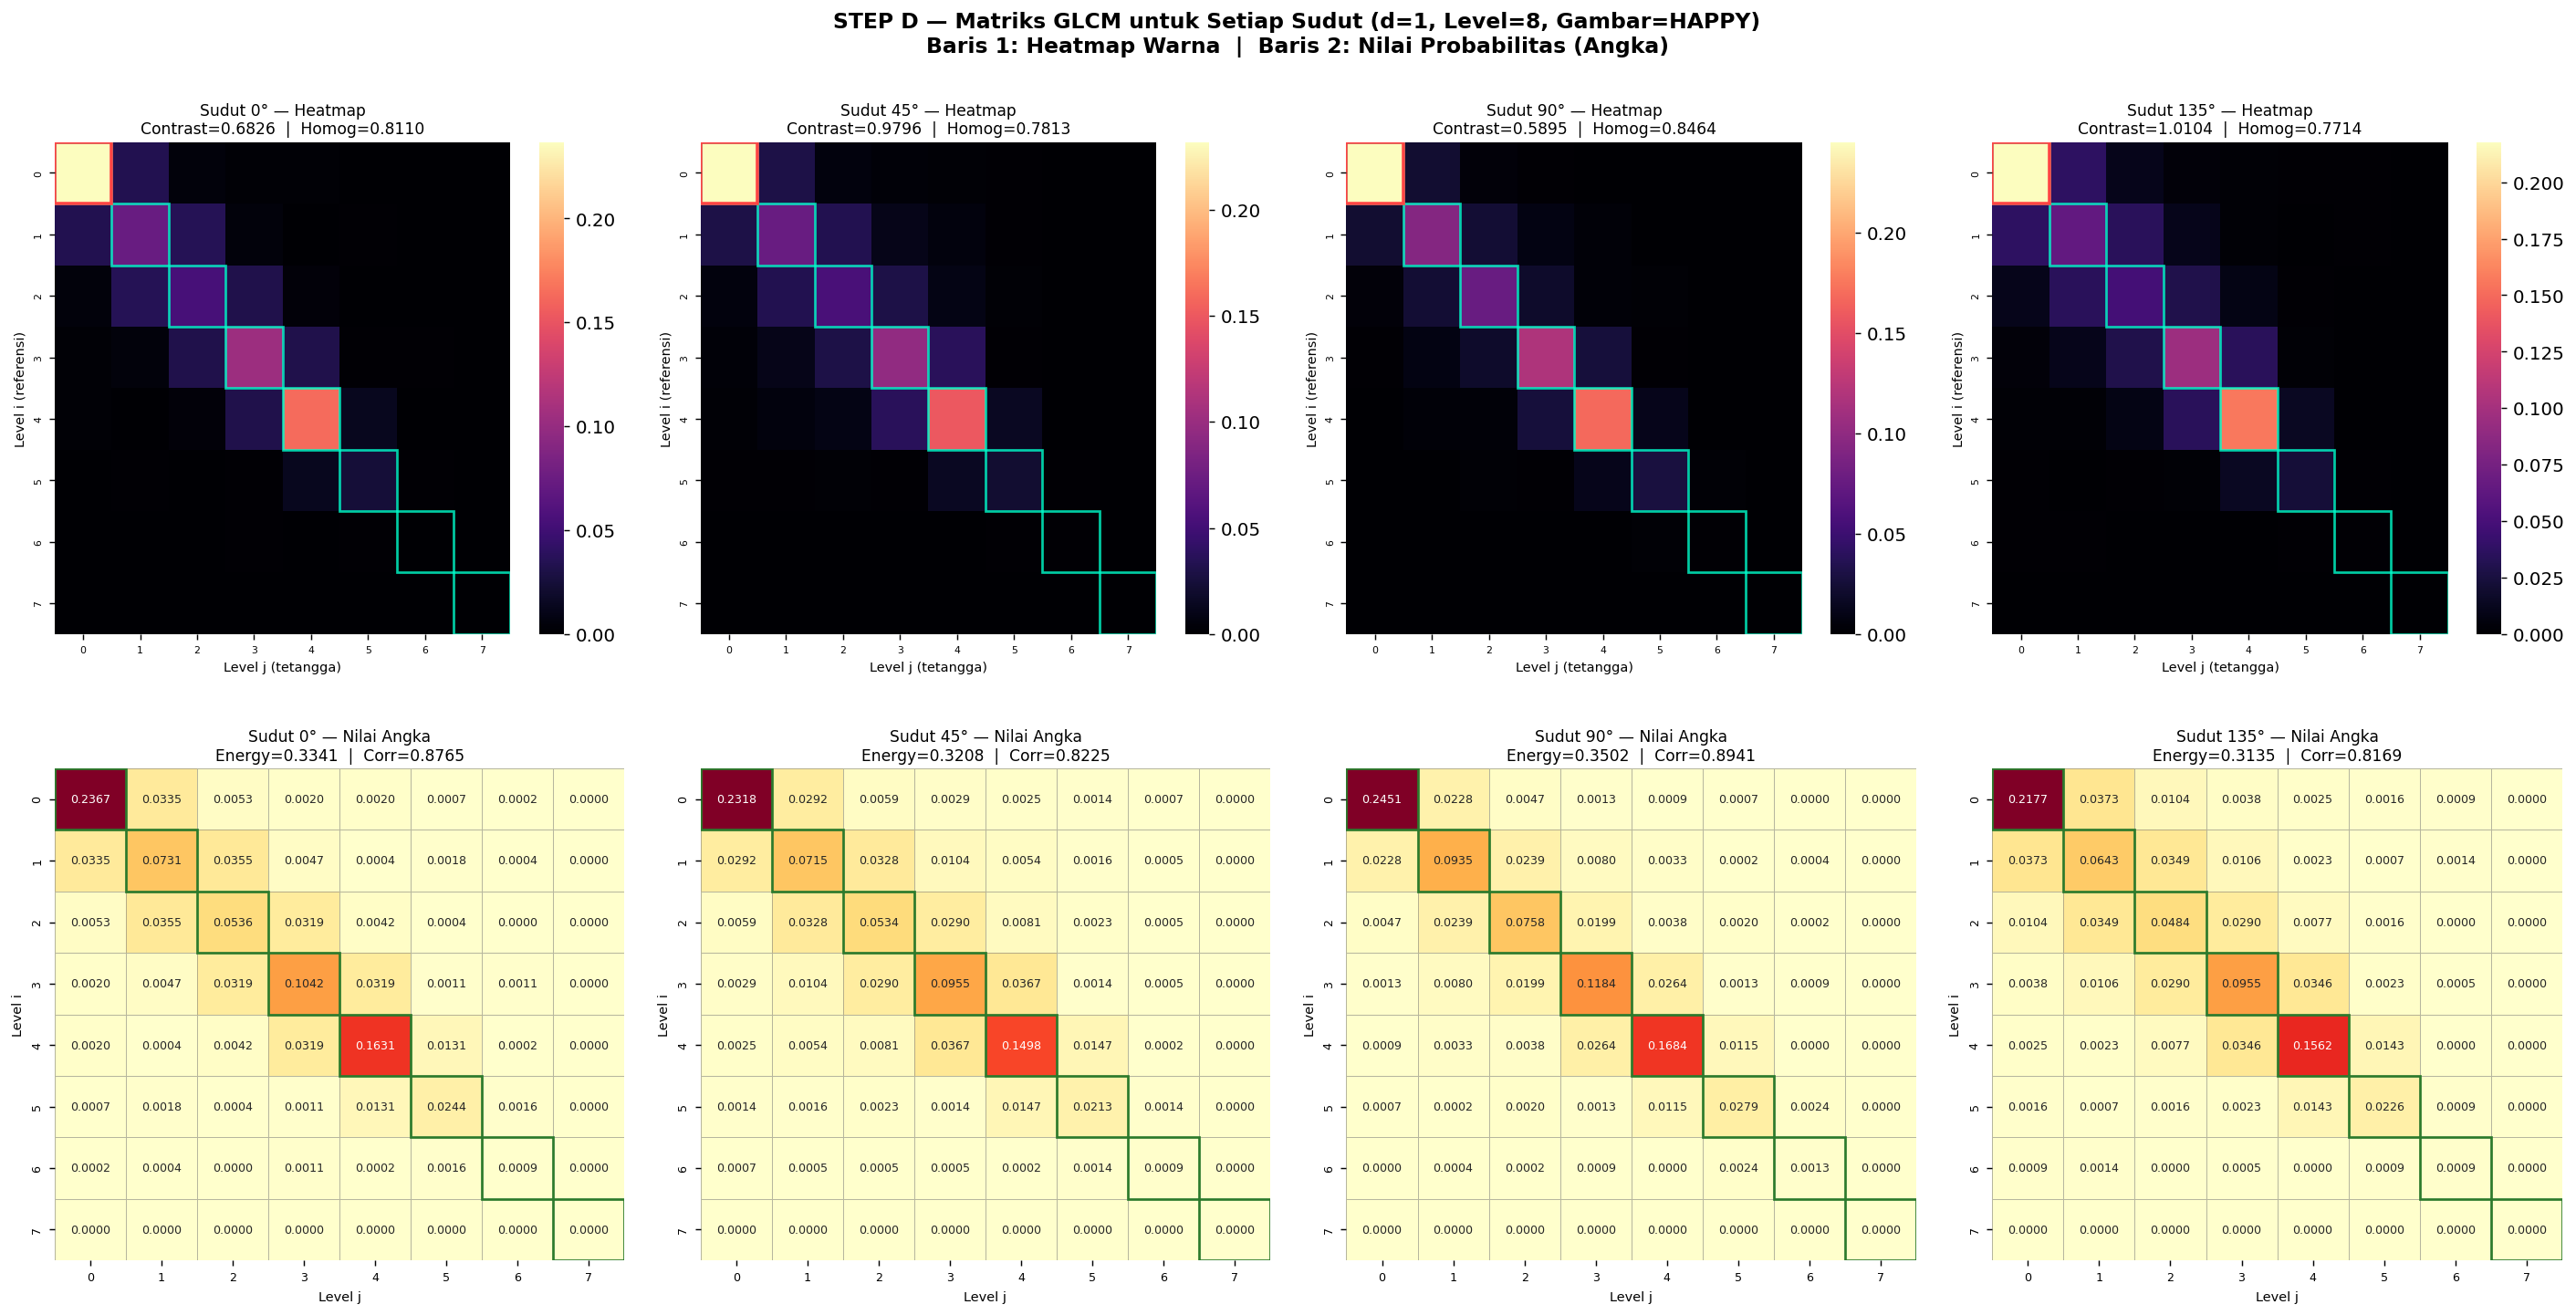

Disimpan: outputs\figures\05_step_d_glcm_per_sudut.png


In [43]:
#  CELL 2.4 — STEP D: Semua GLCM per Sudut (Heatmap + Angka)

fig, axes = plt.subplots(2, 4, figsize=(22, 11))
fig.suptitle(
    f'STEP D — Matriks GLCM untuk Setiap Sudut (d=1, Level={LEVELS_VIS}, Gambar=HAPPY)\n'
    'Baris 1: Heatmap Warna  |  Baris 2: Nilai Probabilitas (Angka)',
    fontsize=13, fontweight='bold', y=1.005
)

for col, (a_idx, a_lbl) in enumerate(zip(range(4), ANGLE_LABELS)):
    g2d = glcm_ex[:, :, 0, a_idx]   # Slice 2D per sudut, shape (L, L)

    c_val  = props_per_angle['contrast'][a_idx]
    h_val  = props_per_angle['homogeneity'][a_idx]
    e_val  = props_per_angle['energy'][a_idx]
    cr_val = props_per_angle['correlation'][a_idx]

    # Baris 0: Heatmap Warna 
    ax = axes[0, col]
    im = sns.heatmap(
        g2d, ax=ax, cmap='magma',
        xticklabels=tick_labels_v, yticklabels=tick_labels_v,
        linewidths=0, cbar=True, annot=False
    )
    # Highlight diagonal (nilai ko-okurens piksel sama)
    for i in range(LEVELS_VIS):
        ax.add_patch(mpatches.Rectangle((i, i), 1, 1, fill=False,
                                         edgecolor='#00ffcc', lw=1.5, alpha=0.8))
    ax.set_title(
        f'Sudut {a_lbl} — Heatmap\n'
        f'Contrast={c_val:.4f}  |  Homog={h_val:.4f}',
        fontsize=9.5, pad=5
    )
    ax.set_xlabel('Level j (tetangga)', fontsize=8)
    ax.set_ylabel('Level i (referensi)', fontsize=8)
    ax.tick_params(labelsize=6)

    # Anotasi maks sel
    max_ij = np.unravel_index(g2d.argmax(), g2d.shape)
    ax.add_patch(mpatches.Rectangle((max_ij[1], max_ij[0]), 1, 1, fill=False,
                                     edgecolor='#ff4444', lw=2))

    # Baris 1: Angka
    ax = axes[1, col]
    sns.heatmap(
        g2d, ax=ax, annot=True, fmt='.4f', cmap='YlOrRd',
        xticklabels=tick_labels_v, yticklabels=tick_labels_v,
        linewidths=0.5, linecolor='#77777788', cbar=False,
        annot_kws={'size': 7}
    )
    for i in range(LEVELS_VIS):
        ax.add_patch(mpatches.Rectangle((i, i), 1, 1, fill=False,
                                         edgecolor='#2c7a2c', lw=1.5))
    ax.set_title(
        f'Sudut {a_lbl} — Nilai Angka\n'
        f'Energy={e_val:.4f}  |  Corr={cr_val:.4f}',
        fontsize=9.5, pad=5
    )
    ax.set_xlabel('Level j', fontsize=8)
    ax.set_ylabel('Level i', fontsize=8)
    ax.tick_params(labelsize=7)

plt.tight_layout(h_pad=3, w_pad=1.5)
plt.savefig(str(OUT_FIGS / '05_step_d_glcm_per_sudut.png'), bbox_inches='tight', dpi=150)
plt.show()
print("Disimpan:", OUT_FIGS / '05_step_d_glcm_per_sudut.png')


## STEP E — Matriks Koheren Final + Tabel Fitur Lengkap

Setelah mendapatkan 4 GLCM per sudut, kita agregasi menjadi **Matriks Koheren Final**  
dan ekstrak **vektor fitur** yang akan menjadi input Logistic Regression.

**Dua strategi agregasi:**
- **Mean** → rata-rata 4 sudut → **4 fitur** (rotational invariant)
- **Concat** → gabungkan 4 sudut → **16 fitur** (lebih informatif, lebih sensitif orientasi)


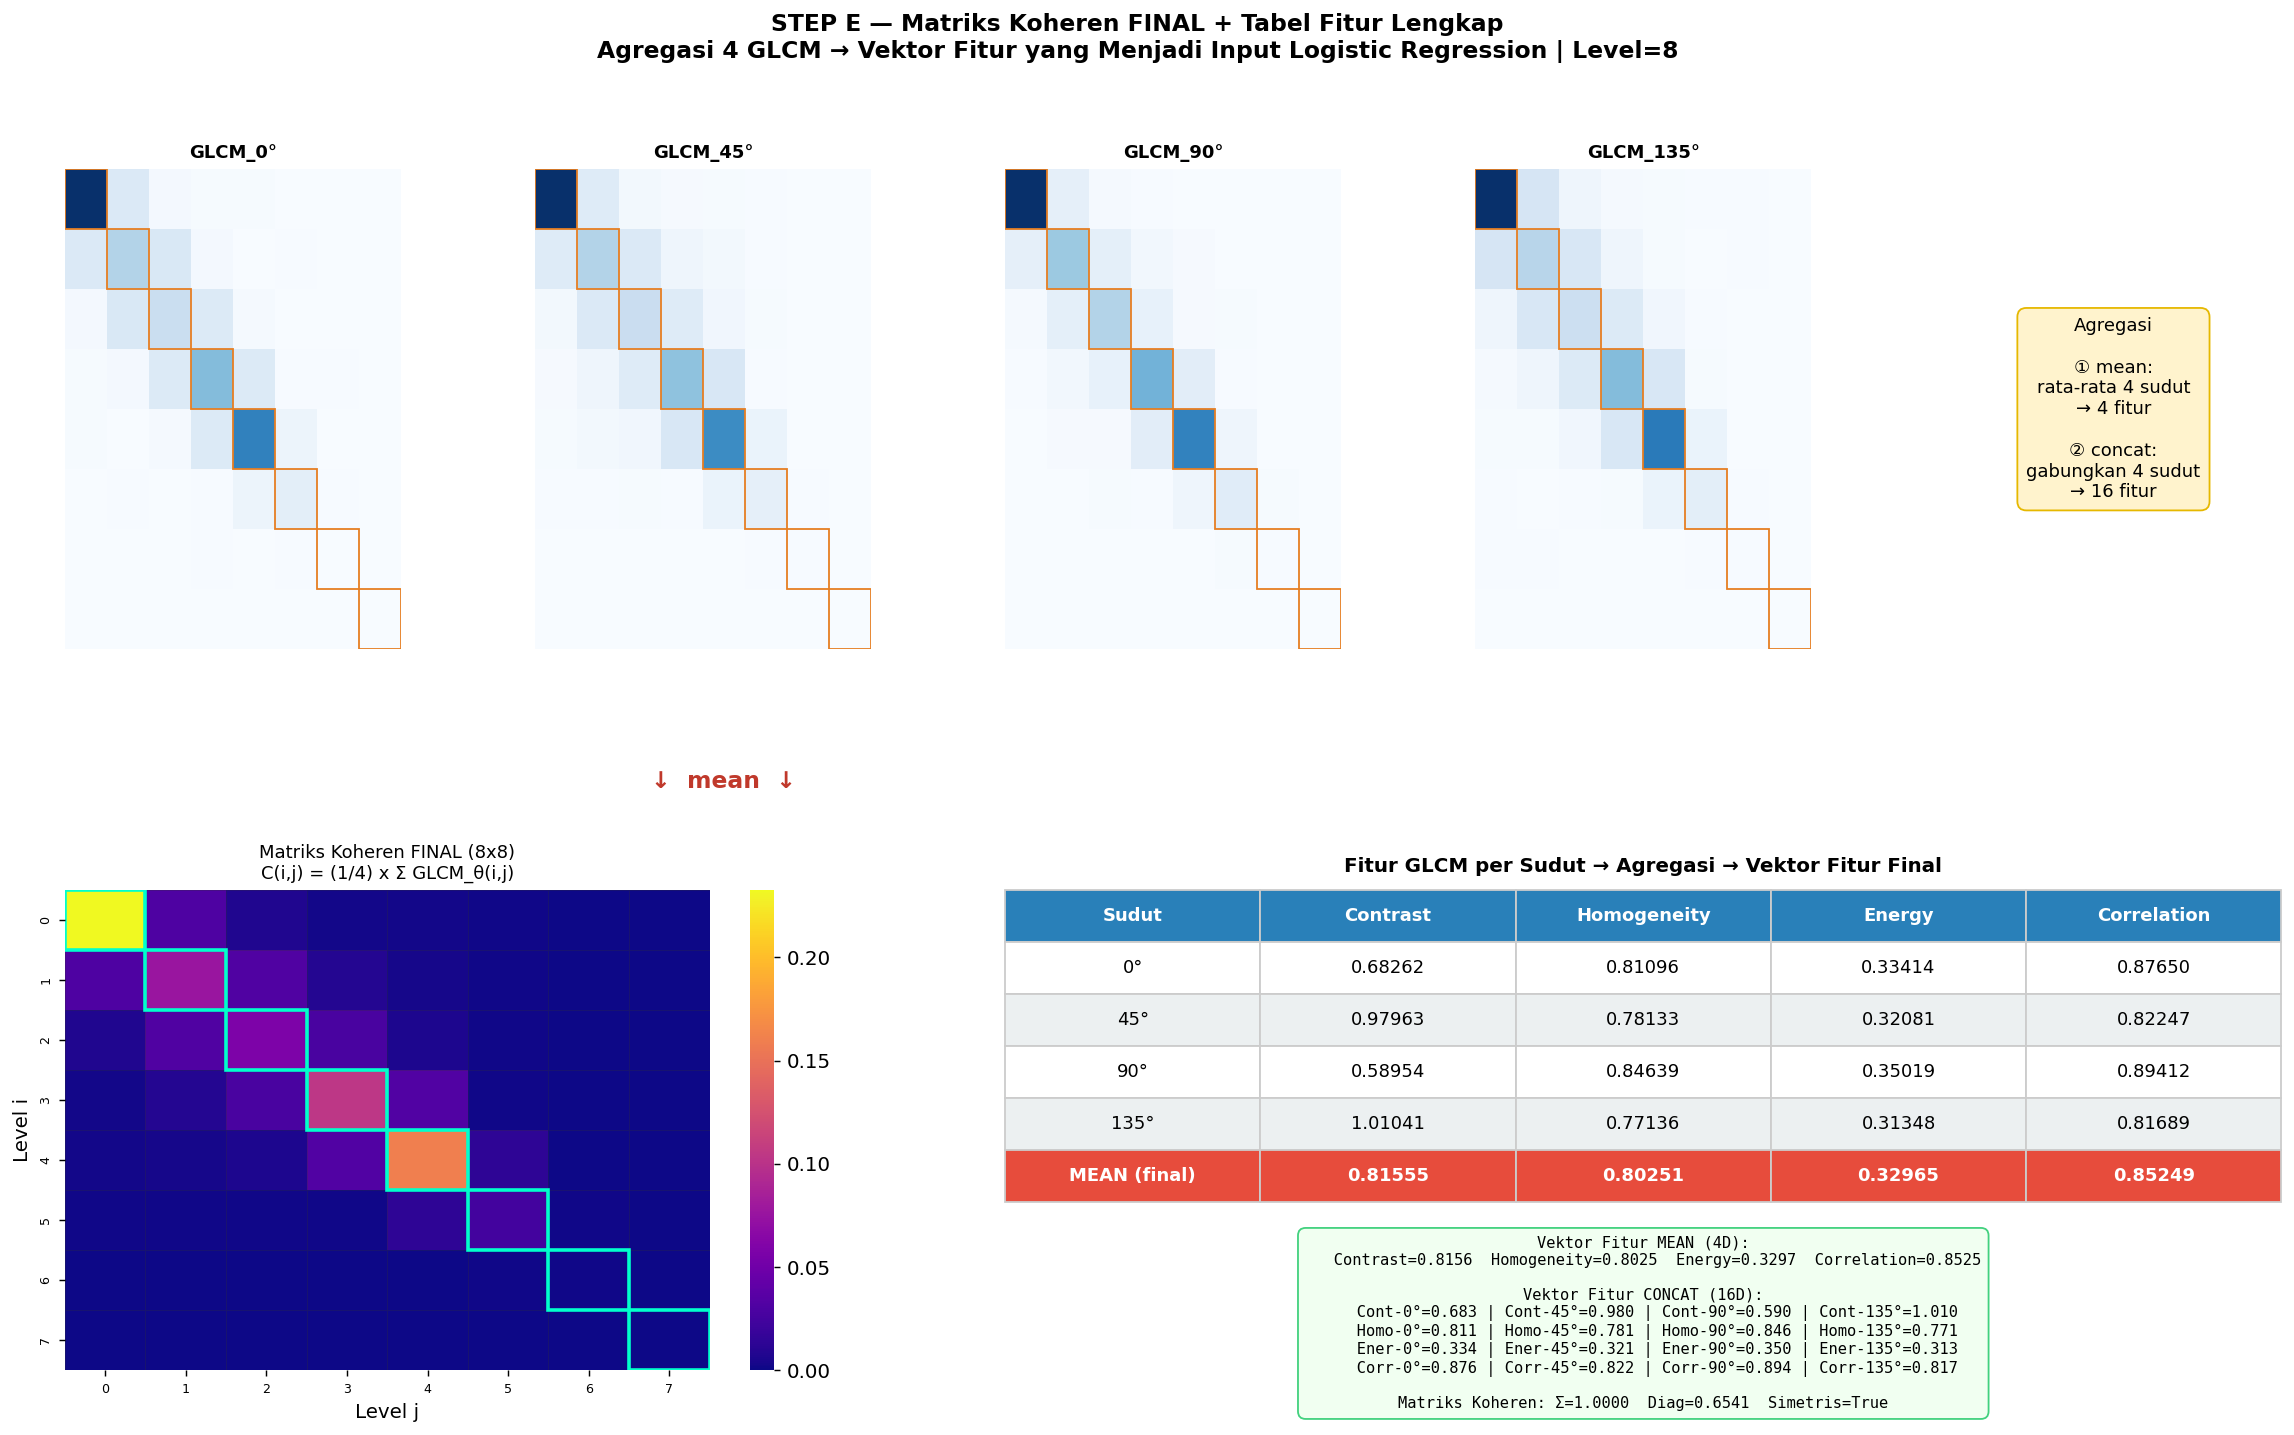

Disimpan: outputs\figures\06_step_e_coherence_final.png

Vektor Fitur Mean (4D) :
   contrast        = 0.815551
   homogeneity     = 0.802509
   energy          = 0.329653
   correlation     = 0.852494

Vektor Fitur Concat (16D): [0.6826 0.9796 0.5895 1.0104 0.811  0.7813 0.8464 0.7714 0.3341 0.3208
 0.3502 0.3135 0.8765 0.8225 0.8941 0.8169]


In [44]:
#  CELL 2.5 — STEP E: Matriks Koheren Final + Tabel Fitur

feat_mean, _  = extract_glcm_features(img_norm_ex, LEVELS_VIS, aggregation='mean')
feat_concat, _= extract_glcm_features(img_norm_ex, LEVELS_VIS, aggregation='concat')
feat_dict_m   = dict(zip(GLCM_PROPS, feat_mean))

fig = plt.figure(figsize=(22, 12))
fig.suptitle(
    f'STEP E — Matriks Koheren FINAL + Tabel Fitur Lengkap\n'
    f'Agregasi 4 GLCM → Vektor Fitur yang Menjadi Input Logistic Regression | Level={LEVELS_VIS}',
    fontsize=13, fontweight='bold'
)
gs = gridspec.GridSpec(2, 5, figure=fig, hspace=0.5, wspace=0.4)

# Baris 0: 4 miniatur GLCM
for col in range(4):
    ax_mini = fig.add_subplot(gs[0, col])
    g2d     = glcm_ex[:, :, 0, col]
    sns.heatmap(g2d, ax=ax_mini, cmap='Blues', cbar=False,
                xticklabels=False, yticklabels=False, linewidths=0)
    for i in range(LEVELS_VIS):
        ax_mini.add_patch(mpatches.Rectangle((i, i), 1, 1, fill=False,
                                              edgecolor='#e67e22', lw=1))
    ax_mini.set_title(f'GLCM_{ANGLE_LABELS[col]}', fontsize=10, fontweight='bold')
    # Anotasi panah
    if col == 1:
        ax_mini.text(LEVELS_VIS/2+0.5, LEVELS_VIS+2.2, '↓  mean  ↓',
                     ha='center', va='center', color='#c0392b', fontsize=13, fontweight='bold',
                     transform=ax_mini.transData)

# Kotak tanda panah ke bawah
ax_arrow = fig.add_subplot(gs[0, 4])
ax_arrow.axis('off')
ax_arrow.text(0.5, 0.5,
              'Agregasi\n\n'
              '① mean:\nrata-rata 4 sudut\n→ 4 fitur\n\n'
              '② concat:\ngabungkan 4 sudut\n→ 16 fitur',
              ha='center', va='center', fontsize=10,
              bbox=dict(boxstyle='round,pad=0.5', facecolor='#fff3cd', edgecolor='#e6b800'),
              transform=ax_arrow.transAxes)

# Baris 1 kiri: Coherence Matrix heatmap
ax_coh = fig.add_subplot(gs[1, 0:2])
sns.heatmap(
    coherence_mat, ax=ax_coh, cmap='plasma',
    xticklabels=tick_labels_v, yticklabels=tick_labels_v,
    linewidths=0.3, linecolor='#33333344', cbar=True
)
for i in range(LEVELS_VIS):
    ax_coh.add_patch(mpatches.Rectangle((i, i), 1, 1, fill=False,
                                         edgecolor='#00ffcc', lw=2))
ax_coh.set_title(
    f'Matriks Koheren FINAL ({LEVELS_VIS}x{LEVELS_VIS})\n'
    f'C(i,j) = (1/4) x Σ GLCM_θ(i,j)',
    fontsize=10
)
ax_coh.set_xlabel('Level j'); ax_coh.set_ylabel('Level i')
ax_coh.tick_params(labelsize=7)

# Baris 1 tengah-kanan: Tabel fitur
ax_tbl = fig.add_subplot(gs[1, 2:5])
ax_tbl.axis('off')

# Baris tabel: per sudut
tbl_data = []
for a_idx, a_lbl in enumerate(ANGLE_LABELS):
    row = [a_lbl] + [f'{props_per_angle[p][a_idx]:.5f}' for p in GLCM_PROPS]
    tbl_data.append(row)

# Baris mean (vektor fitur final)
tbl_data.append(['MEAN (final)'] + [f'{v:.5f}' for v in feat_mean])

col_hdrs = ['Sudut'] + [p.capitalize() for p in GLCM_PROPS]
tbl = ax_tbl.table(
    cellText=tbl_data, colLabels=col_hdrs,
    loc='center', cellLoc='center',
    bbox=[0.0, 0.35, 1.0, 0.65]
)
tbl.auto_set_font_size(False); tbl.set_fontsize(10)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#cccccc')
    if r == 0:
        cell.set_facecolor('#2980b9'); cell.set_text_props(color='white', fontweight='bold')
    elif r == len(tbl_data):   # Baris MEAN
        cell.set_facecolor('#e74c3c'); cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor('#ecf0f1' if r % 2 == 0 else 'white')

ax_tbl.set_title('Fitur GLCM per Sudut → Agregasi → Vektor Fitur Final',
                 fontsize=11, fontweight='bold', pad=10)

# Keterangan fitur final + concat
keterangan = (
    f"Vektor Fitur MEAN (4D):\n"
    f"   Contrast={feat_dict_m['contrast']:.4f}  Homogeneity={feat_dict_m['homogeneity']:.4f}  "
    f"Energy={feat_dict_m['energy']:.4f}  Correlation={feat_dict_m['correlation']:.4f}\n\n"
    f"Vektor Fitur CONCAT (16D):\n   " +
    "  ".join([f"{p[:4].cap() if hasattr(p,'cap') else p[:4].capitalize()}-{a}={v:.3f}"
               for p in GLCM_PROPS for a, v in zip(ANGLE_LABELS, graycoprops(glcm_ex, p)[0])])
)

# Ganti keterangan concat dengan versi sederhana
concat_str = "   "
for p in GLCM_PROPS:
    vals = graycoprops(glcm_ex, p)[0]
    concat_str += " | ".join([f"{p[:4].capitalize()}-{a}={v:.3f}"
                               for a, v in zip(ANGLE_LABELS, vals)]) + "\n   "

keterangan2 = (
    f"Vektor Fitur MEAN (4D):\n"
    f"   Contrast={feat_dict_m['contrast']:.4f}  Homogeneity={feat_dict_m['homogeneity']:.4f}  "
    f"Energy={feat_dict_m['energy']:.4f}  Correlation={feat_dict_m['correlation']:.4f}\n\n"
    f"Vektor Fitur CONCAT (16D):\n{concat_str}"
    f"\nMatriks Koheren: Σ={coherence_mat.sum():.4f}  Diag={np.trace(coherence_mat):.4f}  "
    f"Simetris={np.allclose(coherence_mat, coherence_mat.T)}"
)

ax_tbl.text(0.5, 0.28, keterangan2, transform=ax_tbl.transAxes,
            ha='center', va='top', fontsize=8.5, fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#f0fff0', edgecolor='#2ecc71', alpha=0.9))

plt.savefig(str(OUT_FIGS / '06_step_e_coherence_final.png'), bbox_inches='tight', dpi=150)
plt.show()
print("Disimpan:", OUT_FIGS / '06_step_e_coherence_final.png')
print(f"\nVektor Fitur Mean (4D) :")
for k, v in feat_dict_m.items():
    print(f"   {k:15s} = {v:.6f}")
print(f"\nVektor Fitur Concat (16D): {np.round(feat_concat, 4)}")


## STEP F - Visualisasi Interpretatif: Mengapa Nilai Fitur Segitu?

Bagian paling penting untuk memahami GLCM secara konseptual.  
Kita tunjukkan **secara visual dari gambar itu sendiri** mengapa nilai fitur tertentu dihasilkan.

| Fitur | Visualisasi Proxy | Hubungan |
|---|---|---|
| **Contrast** | Sobel Edge Map | Banyak tepi tajam → Contrast **tinggi** |
| **Homogeneity** | Peta Variansi Lokal | Area seragam (var rendah) → Homogeneity **tinggi** |
| **Energy** | Std-Dev Lokal | Distribusi merata → Energy **rendah** |
| **Correlation** | Gradient Magnitude (Smooth) | Transisi halus & konsisten → Correlation **tinggi** |


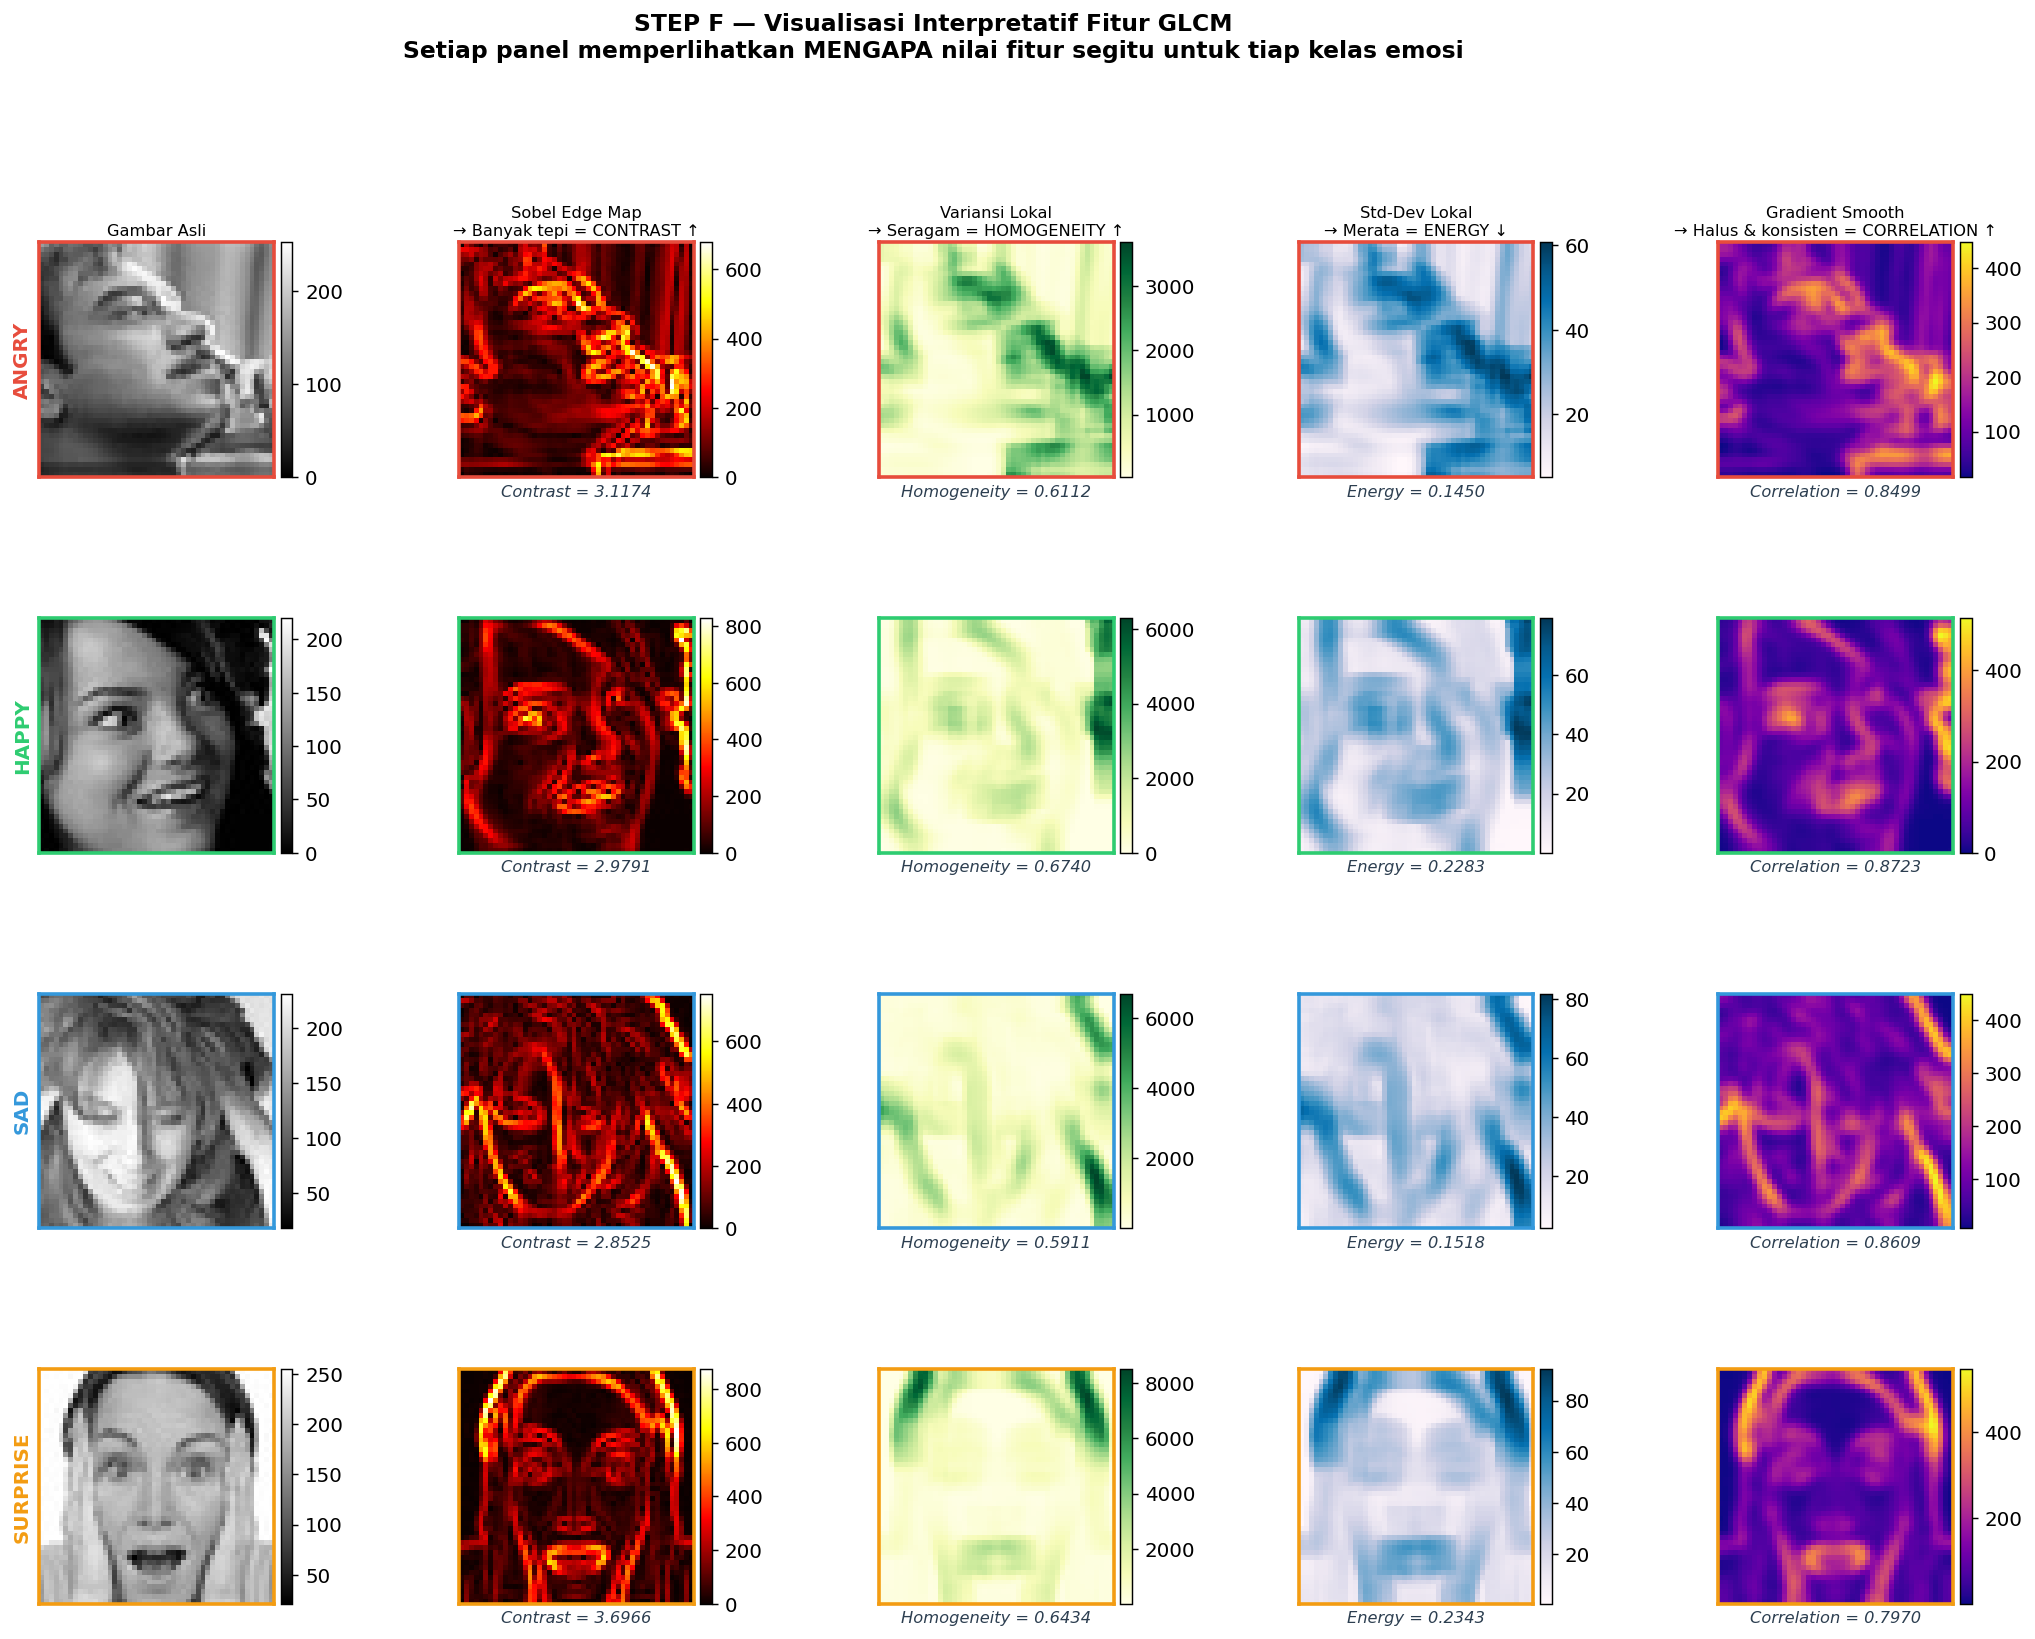

Disimpan: outputs\figures\07_step_f_interpretasi_glcm.png


In [45]:
#  CELL 2.6 — STEP F: Visualisasi Interpretatif Fitur GLCM

def compute_local_variance(img, kernel_size=7):
    img_f   = img.astype(np.float32)
    mean_sq = cv2.blur(img_f**2, (kernel_size, kernel_size))
    sq_mean = cv2.blur(img_f,    (kernel_size, kernel_size))**2
    return np.clip(mean_sq - sq_mean, 0, None)

samples_interp = get_sample_per_class(train_raw, train_norm, train_labels)

panel_titles = [
    'Gambar Asli',
    'Sobel Edge Map\n→ Banyak tepi = CONTRAST ↑',
    'Variansi Lokal\n→ Seragam = HOMOGENEITY ↑',
    'Std-Dev Lokal\n→ Merata = ENERGY ↓',
    'Gradient Smooth\n→ Halus & konsisten = CORRELATION ↑',
]

fig, axes = plt.subplots(
    len(CLASSES), 5,
    figsize=(5*4, len(CLASSES)*3.4),
    gridspec_kw={'hspace': 0.6, 'wspace': 0.25}
)
fig.suptitle(
    'STEP F — Visualisasi Interpretatif Fitur GLCM\n'
    'Setiap panel memperlihatkan MENGAPA nilai fitur segitu untuk tiap kelas emosi',
    fontsize=13, fontweight='bold', y=1.01
)

for row, (cls, color) in enumerate(zip(CLASSES, COLORS)):
    img_r = samples_interp[cls]['raw']
    img_n = samples_interp[cls]['norm']

    sx = cv2.Sobel(img_r, cv2.CV_64F, 1, 0, ksize=3)
    sy = cv2.Sobel(img_r, cv2.CV_64F, 0, 1, ksize=3)
    edge_map    = np.sqrt(sx**2 + sy**2)
    local_var   = compute_local_variance(img_r, 7)
    local_std   = np.sqrt(local_var + 1e-6)
    grad_smooth = cv2.GaussianBlur(edge_map, (5,5), 0)

    feat, _ = extract_glcm_features(img_n, levels=16, aggregation='mean')
    fd = dict(zip(GLCM_PROPS, feat))

    panels = [
        (img_r,       'gray',   None),
        (edge_map,    'hot',    f"Contrast = {fd['contrast']:.4f}"),
        (local_var,   'YlGn',   f"Homogeneity = {fd['homogeneity']:.4f}"),
        (local_std,   'PuBu',   f"Energy = {fd['energy']:.4f}"),
        (grad_smooth, 'plasma', f"Correlation = {fd['correlation']:.4f}"),
    ]

    for col, (panel_img, cmap, feat_val) in enumerate(panels):
        ax = axes[row, col]
        im = ax.imshow(panel_img, cmap=cmap)
        plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)

        if col == 0:
            ax.set_ylabel(f'{cls.upper()}', fontsize=11, color=color, fontweight='bold')
        if row == 0:
            ax.set_title(panel_titles[col], fontsize=9, pad=4)
        if feat_val:
            ax.set_xlabel(feat_val, fontsize=9, color='#2c3e50', style='italic')

        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_visible(True); sp.set_edgecolor(color); sp.set_linewidth(2)

plt.savefig(str(OUT_FIGS / '07_step_f_interpretasi_glcm.png'), bbox_inches='tight', dpi=150)
plt.show()
print("Disimpan:", OUT_FIGS / '07_step_f_interpretasi_glcm.png')


Menghitung rata-rata fitur GLCM per kelas...
   [angry] 2028 gambar
   [happy] 2028 gambar
   [sad] 2028 gambar
   [surprise] 2028 gambar


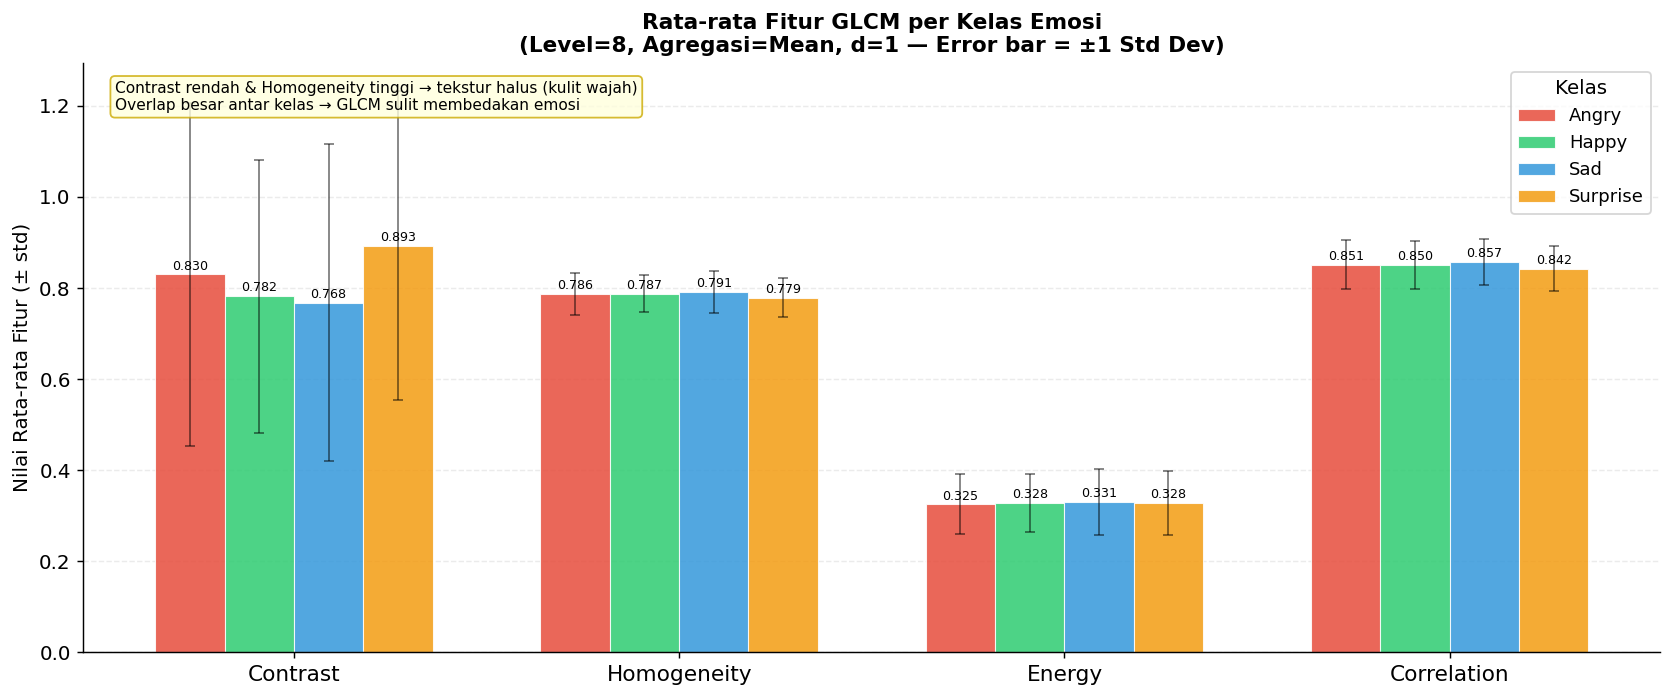

Disimpan: outputs\figures\08_glcm_feature_bar.png
Menghitung rata-rata fitur GLCM per kelas (L=8, concat)...
   [angry] 2028 gambar → fitur shape: (2028, 16)
   [happy] 2028 gambar → fitur shape: (2028, 16)
   [sad] 2028 gambar → fitur shape: (2028, 16)
   [surprise] 2028 gambar → fitur shape: (2028, 16)


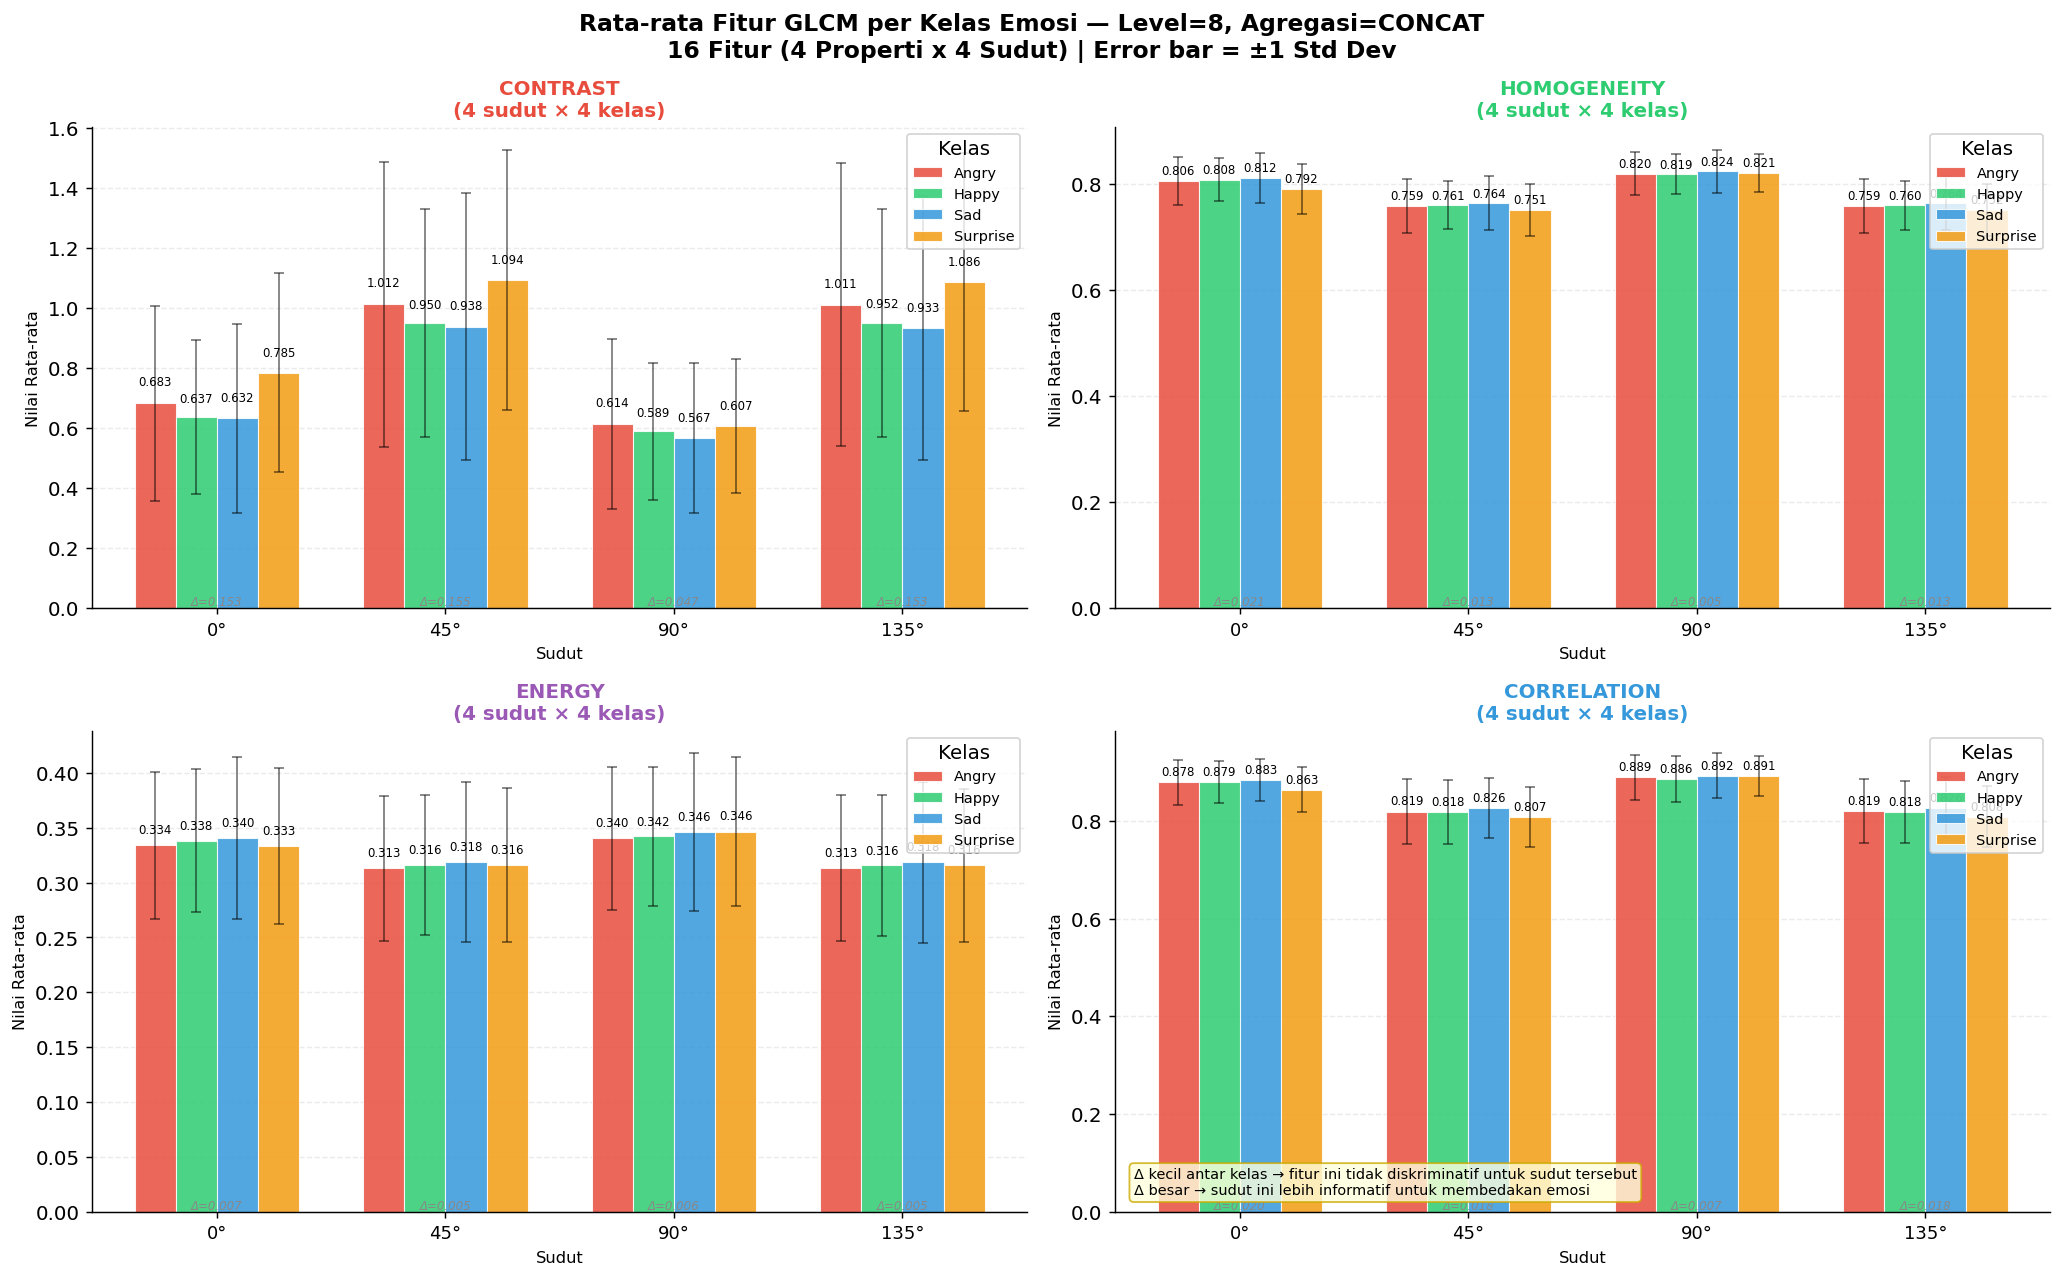

Disimpan: outputs\figures\08_glcm_feature_bar_concat.png


In [46]:
# #  CELL 2.7 — Perbandingan Rata-rata Fitur GLCM Antar Kelas

class_feat_means = {}
class_feat_stds  = {}

print("Menghitung rata-rata fitur GLCM per kelas...")
for cls in CLASSES:
    feats = [
        extract_glcm_features(img, levels=8, aggregation='mean')[0]
        for img, lbl in zip(train_norm, train_labels) if lbl == cls
    ]
    arr = np.array(feats)
    class_feat_means[cls] = arr.mean(axis=0)
    class_feat_stds[cls]  = arr.std(axis=0)
    print(f"   [{cls}] {len(feats)} gambar")

x = np.arange(len(GLCM_PROPS))
w = 0.18
fig, ax = plt.subplots(figsize=(13, 5.5))

for i, (cls, color) in enumerate(zip(CLASSES, COLORS)):
    offset = (i - (len(CLASSES)-1)/2) * w
    bars = ax.bar(x + offset, class_feat_means[cls], w,
                  label=cls.capitalize(), color=color, alpha=0.85,
                  edgecolor='white', linewidth=0.6)
    ax.errorbar(x + offset, class_feat_means[cls], yerr=class_feat_stds[cls],
                fmt='none', ecolor='black', elinewidth=1, capsize=3, alpha=0.5)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.004,
                f'{h:.3f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels([p.capitalize() for p in GLCM_PROPS], fontsize=12)
ax.set_ylabel('Nilai Rata-rata Fitur (± std)', fontsize=11)
ax.set_title(
    'Rata-rata Fitur GLCM per Kelas Emosi\n'
    '(Level=8, Agregasi=Mean, d=1 — Error bar = ±1 Std Dev)',
    fontsize=12, fontweight='bold'
)
ax.legend(title='Kelas', fontsize=10)
ax.grid(axis='y', alpha=0.25, ls='--'); ax.set_axisbelow(True)

# Anotasi interpretasi
note = ("Contrast rendah & Homogeneity tinggi → tekstur halus (kulit wajah)\n"
        "Overlap besar antar kelas → GLCM sulit membedakan emosi")
ax.text(0.02, 0.97, note, transform=ax.transAxes, va='top', fontsize=8.5,
        bbox=dict(boxstyle='round', facecolor='#ffffdd', edgecolor='#ccaa00', alpha=0.8))

plt.tight_layout()
plt.savefig(str(OUT_FIGS / '08_glcm_feature_bar.png'), bbox_inches='tight', dpi=150)
plt.show()
print("Disimpan:", OUT_FIGS / '08_glcm_feature_bar.png')


#  CELL 2.7 — Perbandingan Rata-rata Fitur GLCM Antar Kelas
#  Level=8, Agregasi=CONCAT (16 fitur: 4 properti × 4 sudut)

LEVELS_BAR = 8
AGG_BAR    = 'concat'
ANGLE_LABELS = ['0°', '45°', '90°', '135°']

class_feat_means = {}
class_feat_stds  = {}

print(f"Menghitung rata-rata fitur GLCM per kelas (L={LEVELS_BAR}, {AGG_BAR})...")
for cls in CLASSES:
    feats = [
        extract_glcm_features(img, levels=LEVELS_BAR, aggregation=AGG_BAR)[0]
        for img, lbl in zip(train_norm, train_labels) if lbl == cls
    ]
    arr = np.array(feats)                   # shape (n_gambar, 16)
    class_feat_means[cls] = arr.mean(axis=0)
    class_feat_stds[cls]  = arr.std(axis=0)
    print(f"   [{cls}] {len(feats)} gambar → fitur shape: {arr.shape}")

# Label 16 fitur: Contrast-0°, Contrast-45°, ..., Correlation-135°
feat_labels_16 = [
    f'{p[:4].capitalize()}\n{a}'
    for p in GLCM_PROPS
    for a in ANGLE_LABELS
]

# Plot: 1 baris per properti (4 sub-plot)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    f'Rata-rata Fitur GLCM per Kelas Emosi — Level={LEVELS_BAR}, Agregasi=CONCAT\n'
    f'16 Fitur (4 Properti x 4 Sudut) | Error bar = ±1 Std Dev',
    fontsize=13, fontweight='bold'
)

prop_colors_plot = ['#e74c3c', '#2ecc71', '#9b59b6', '#3498db']  # warna per properti

for prop_idx, (prop, prop_color, ax) in enumerate(
        zip(GLCM_PROPS, prop_colors_plot, axes.flatten())):

    # Ambil 4 nilai (per sudut) untuk properti ini
    feat_start = prop_idx * 4
    feat_end   = feat_start + 4
    x = np.arange(4)   # 4 sudut
    w = 0.18

    for i, (cls, color) in enumerate(zip(CLASSES, COLORS)):
        offset   = (i - (len(CLASSES)-1)/2) * w
        vals     = class_feat_means[cls][feat_start:feat_end]
        stds     = class_feat_stds[cls][feat_start:feat_end]
        bars = ax.bar(x + offset, vals, w,
                      label=cls.capitalize(), color=color, alpha=0.85,
                      edgecolor='white', linewidth=0.6)
        ax.errorbar(x + offset, vals, yerr=stds,
                    fmt='none', ecolor='black', elinewidth=1,
                    capsize=3, alpha=0.5)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2,
                    v + max(stds)*0.1 + 0.001,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=6.5)

    ax.set_xticks(x)
    ax.set_xticklabels(ANGLE_LABELS, fontsize=10)
    ax.set_xlabel('Sudut', fontsize=9)
    ax.set_ylabel('Nilai Rata-rata', fontsize=9)
    ax.set_title(f'{prop.upper()}\n(4 sudut × {len(CLASSES)} kelas)',
                 fontsize=11, fontweight='bold', color=prop_color)
    ax.legend(title='Kelas', fontsize=8, loc='upper right')
    ax.grid(axis='y', alpha=0.25, ls='--'); ax.set_axisbelow(True)

    # Anotasi: seberapa besar perbedaan antar kelas per sudut
    for a_idx in range(4):
        vals_kelas = [class_feat_means[cls][feat_start + a_idx] for cls in CLASSES]
        spread = max(vals_kelas) - min(vals_kelas)
        ax.text(a_idx, ax.get_ylim()[0],
                f'Δ={spread:.3f}', ha='center', va='bottom',
                fontsize=6.5, color='#888', style='italic')

note = ("Δ kecil antar kelas → fitur ini tidak diskriminatif untuk sudut tersebut\n"
        "Δ besar → sudut ini lebih informatif untuk membedakan emosi")
ax.text(0.02, 0.03, note, transform=ax.transAxes, va='bottom', fontsize=8,
        bbox=dict(boxstyle='round', facecolor='#ffffdd', edgecolor='#ccaa00', alpha=0.8))

plt.tight_layout()
plt.savefig(str(OUT_FIGS / '08_glcm_feature_bar_concat.png'), bbox_inches='tight', dpi=150)
plt.show()
print(f"Disimpan:", OUT_FIGS / '08_glcm_feature_bar_concat.png')


---
# BAGIAN 3 - Cara Kerja Logistic Regression (Visualisasi Lengkap)

---

## Mengapa BUKAN Linear Regression?

Sebelum memahami Logistic Regression, perlu tahu mengapa **Linear Regression tidak bisa** dipakai untuk klasifikasi:

```
Linear Regression:   ŷ = w·x + b   → output bisa bernilai APA SAJA (-∞ sampai +∞)
                                       Tidak bisa dijadikan probabilitas!

Contoh buruk:
  x=0.1 → ŷ= -0.5  ← negatif, tidak masuk akal untuk probabilitas
  x=0.9 → ŷ=  1.8  ← lebih dari 1, tidak masuk akal untuk probabilitas
```

---

## Fungsi Sigmoid: Jantung Logistic Regression (Biner)

Logistic Regression menambahkan fungsi **Sigmoid** untuk "menekan" output ke range [0,1]:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

**Sifat Sigmoid:**
```
z → -∞  :  σ(z) → 0.0   (pasti Kelas 0)
z =  0  :  σ(z) = 0.5   (tepat di batas)
z → +∞  :  σ(z) → 1.0   (pasti Kelas 1)
```

**Interpretasi kurva S (sigmoid):**
- Kiri (z negatif besar) → kurva mendekati 0 → prediksi: **TIDAK / Kelas 0**
- Tengah (z ≈ 0) → kurva di 0.5 → **tidak yakin**, bisa ke mana saja
- Kanan (z positif besar) → kurva mendekati 1 → prediksi: **YA / Kelas 1**

```
Contoh (klasifikasi "apakah emosi ini happy?"):
  x = [Contrast=0.8, Homog=0.5, Energy=0.1, Corr=0.9]
  z  = w₁×0.8 + w₂×0.5 + w₃×0.1 + w₄×0.9 + b
  z  = +2.3   (misalnya)
  σ(2.3) = 1/(1+e^{-2.3}) = 0.909  → 90.9% kemungkinan HAPPY ✓
```

**Threshold prediksi:**
```
σ(z) ≥ 0.5  →  z ≥ 0  →  Prediksi: Kelas 1 (positif)
σ(z) < 0.5  →  z < 0  →  Prediksi: Kelas 0 (negatif)
```

---

## Dari Biner ke Multi-Class: Fungsi Softmax

Untuk klasifikasi **4 kelas** (angry/happy/sad/surprise),  
sigmoid digantikan oleh **Softmax**:

$$P(\text{kelas}=k \mid x) = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}$$

```
Setiap kelas k punya vektor bobot sendiri wₖ:

z₁ = w₁·x + b₁   (skor untuk ANGRY)
z₂ = w₂·x + b₂   (skor untuk HAPPY)
z₃ = w₃·x + b₃   (skor untuk SAD)
z₄ = w₄·x + b₄   (skor untuk SURPRISE)

Misalnya z = [+1.20, +2.80, -0.50, +0.30]
→ exp(z) = [3.32, 16.44, 0.61, 1.35]   (selalu positif!)
→ Σ exp(z) = 21.72
→ Softmax:
    P(angry)   = 3.32 / 21.72  = 0.153  = 15.3%
    P(happy)   = 16.44 / 21.72 = 0.757  = 75.7%  ← TERBESAR → PREDIKSI
    P(sad)     = 0.61 / 21.72  = 0.028  =  2.8%
    P(surprise)= 1.35 / 21.72  = 0.062  =  6.2%
    ─────────────────────────────────────────────
    Σ                                    = 100%  ✓
```

> Softmax menjamin semua probabilitas positif dan berjumlah 1.0

---

## Cara Logistic Regression Belajar

### Loss Function — Cross-Entropy

$$L = -\sum_{k} y_k^{\text{true}} \cdot \log P(y=k \mid x)$$

```
Jika label asli = HAPPY (y_happy=1, sisanya=0):
  L = -(1 × log(0.757) + 0 + 0 + 0)
    = -log(0.757) = 0.278

Loss kecil → prediksi baik
Loss besar → prediksi buruk → bobot perlu diperbaiki
```

### Proses Pembelajaran (Gradient Descent)

```
ITERASI 1:
  Inisialisasi bobot w secara acak (mendekati 0)
  Hitung z = w·x + b untuk semua data
  Hitung P = softmax(z)
  Hitung Loss L = cross-entropy(P, y_true)
  Hitung gradien ∂L/∂w = (P - y_true) · x
  Update: w_baru = w_lama - α × ∂L/∂w

ITERASI 2, 3, ..., 1000:
  Ulangi sampai Loss konvergen (tidak turun lagi)
  α (learning rate) = kecepatan update

sklearn: max_iter=1000 menentukan batas iterasi maksimum
```

### Mengapa Logistic Regression disebut "Model Linear"?

```
Decision Boundary = garis/bidang yang memisahkan kelas:

  w₁·x₁ + w₂·x₂ + w₃·x₃ + w₄·x₄ + b = 0
  ↑ ini adalah PERSAMAAN LINEAR (hyperplane)

Artinya:
  → Di satu sisi hyperplane = satu kelas
  → Di sisi lain = kelas berbeda

Keterbatasan:
  → Jika kelas tidak bisa dipisahkan dengan garis lurus
    → Logistic Regression GAGAL memisahkan dengan baik
  → Inilah mengapa GLCM + LR tidak optimal untuk emosi wajah
    (kelas overlap, tidak linear separable)
```

---

## Ringkasan Parameter Model

| Parameter sklearn | Nilai | Penjelasan |
|:-----------------|:-----:|:-----------|
| `max_iter` | 1000 | Maks iterasi gradient descent |
| `multi_class` | `'auto'` | Otomatis pilih softmax jika > 2 kelas |
| `solver` | `'lbfgs'` | Algoritma optimasi (Limited-memory BFGS) |
| `C` | 1.0 | Regularisasi (1/λ) — semakin kecil = lebih regularized |
| `random_state` | 42 | Seed untuk reprodusibilitas |

---


## Visualisasi Sigmoid & Logistic Regression

Dua visualisasi berikut menjelaskan:
1. **Kurva Sigmoid** — fungsi S yang mengubah bilangan real ke probabilitas [0,1]  
2. **Logistic Regression Biner** — bagaimana decision boundary bekerja pada data 1D  
3. **Perbandingan Linear vs Logistic** — mengapa tidak pakai Linear Regression  
4. **Dari Sigmoid ke Softmax** — ekstensi ke multi-class (4 emosi)


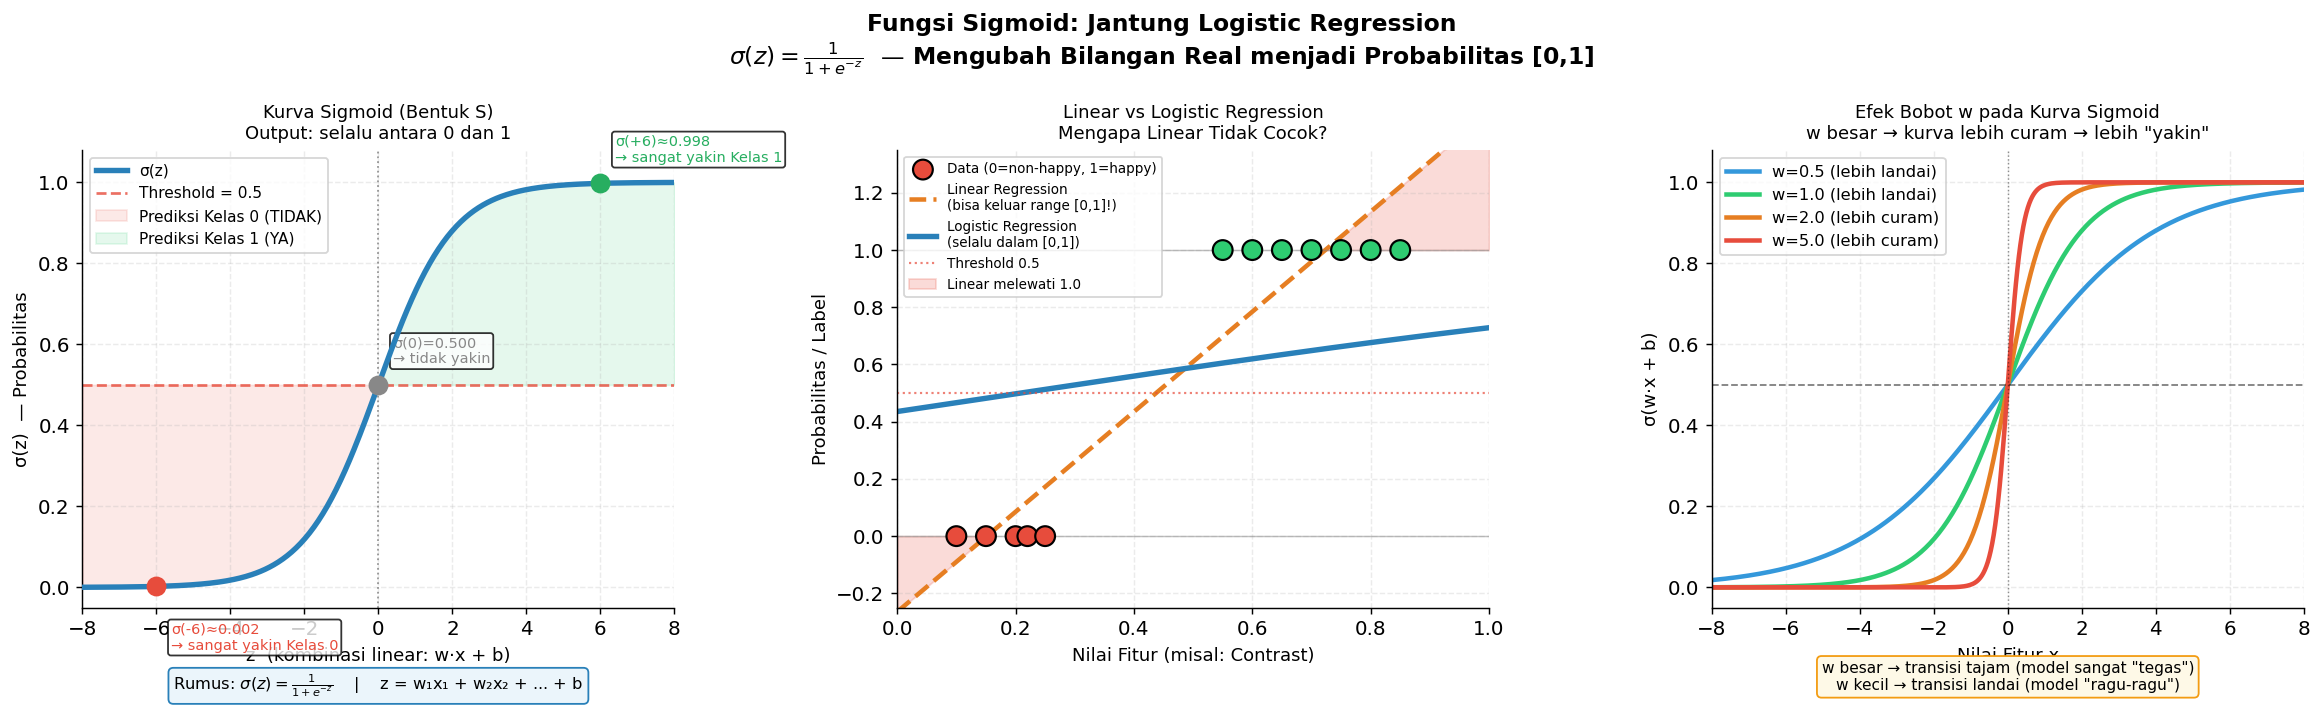

Disimpan: outputs\figures\LR_01_sigmoid_basics.png


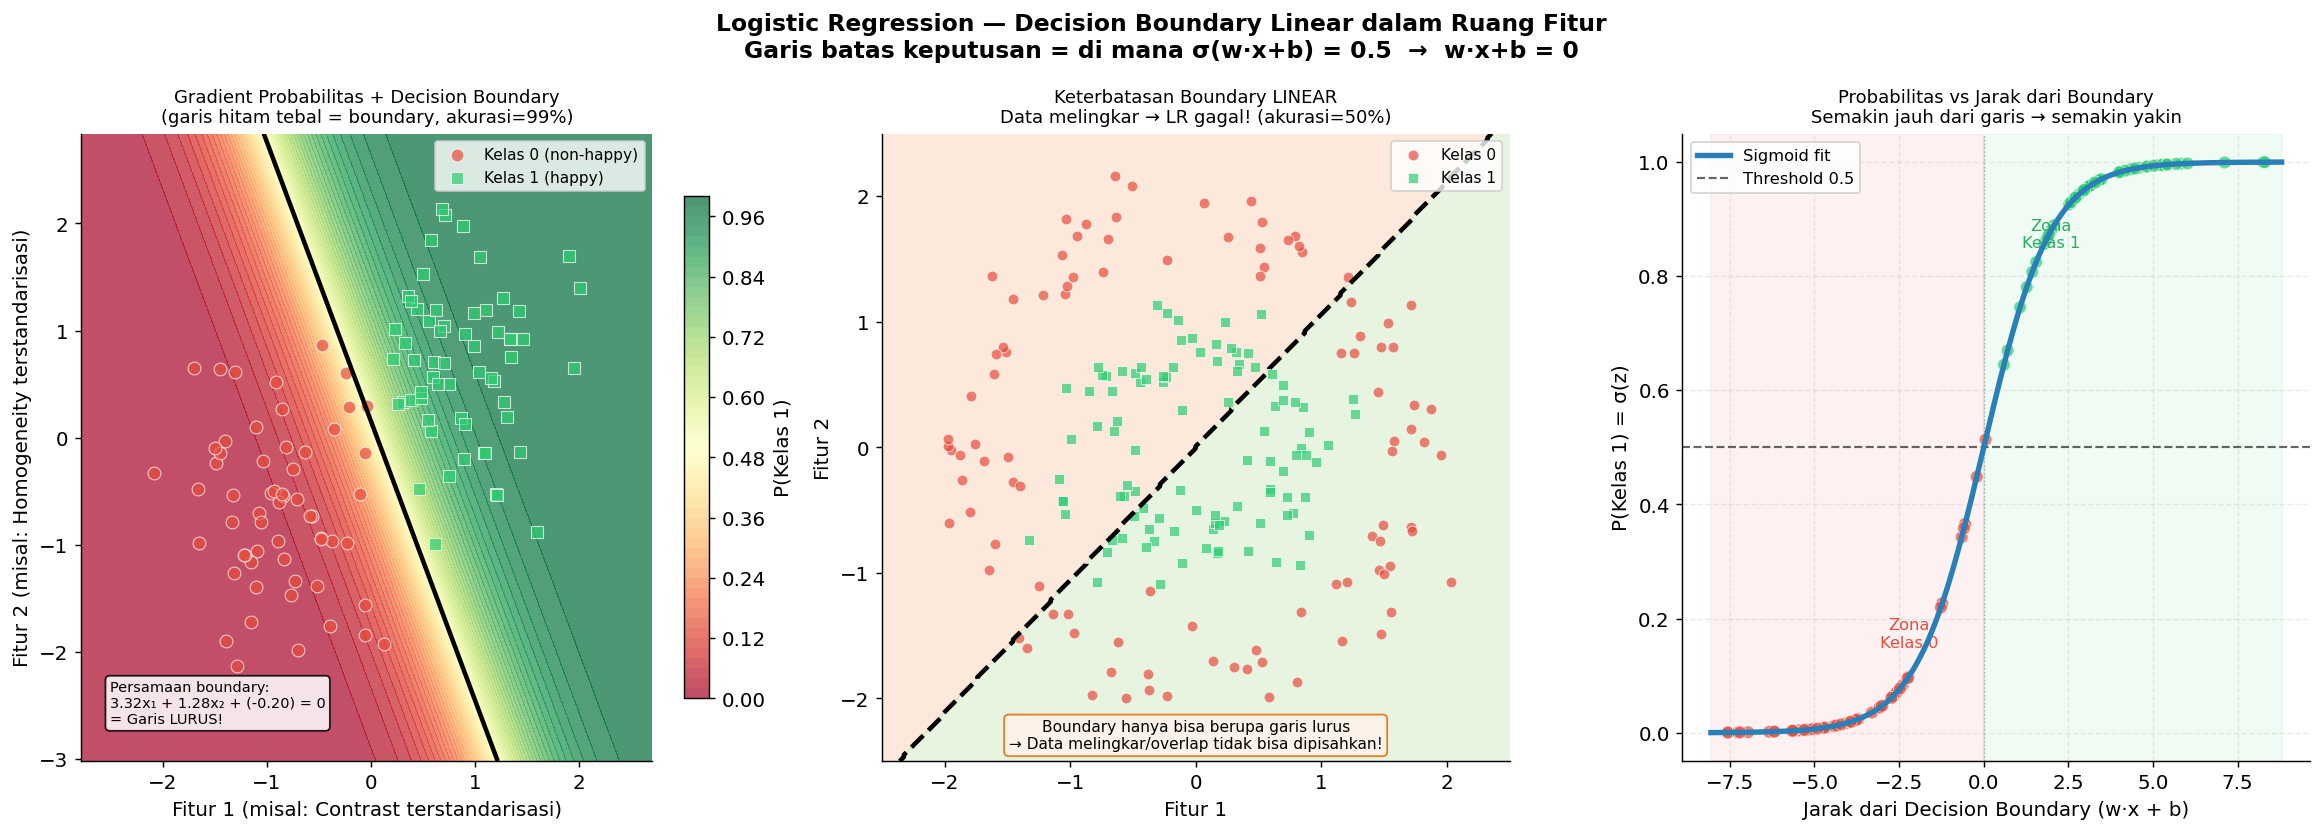

Disimpan: outputs\figures\LR_02_decision_boundary_binary.png


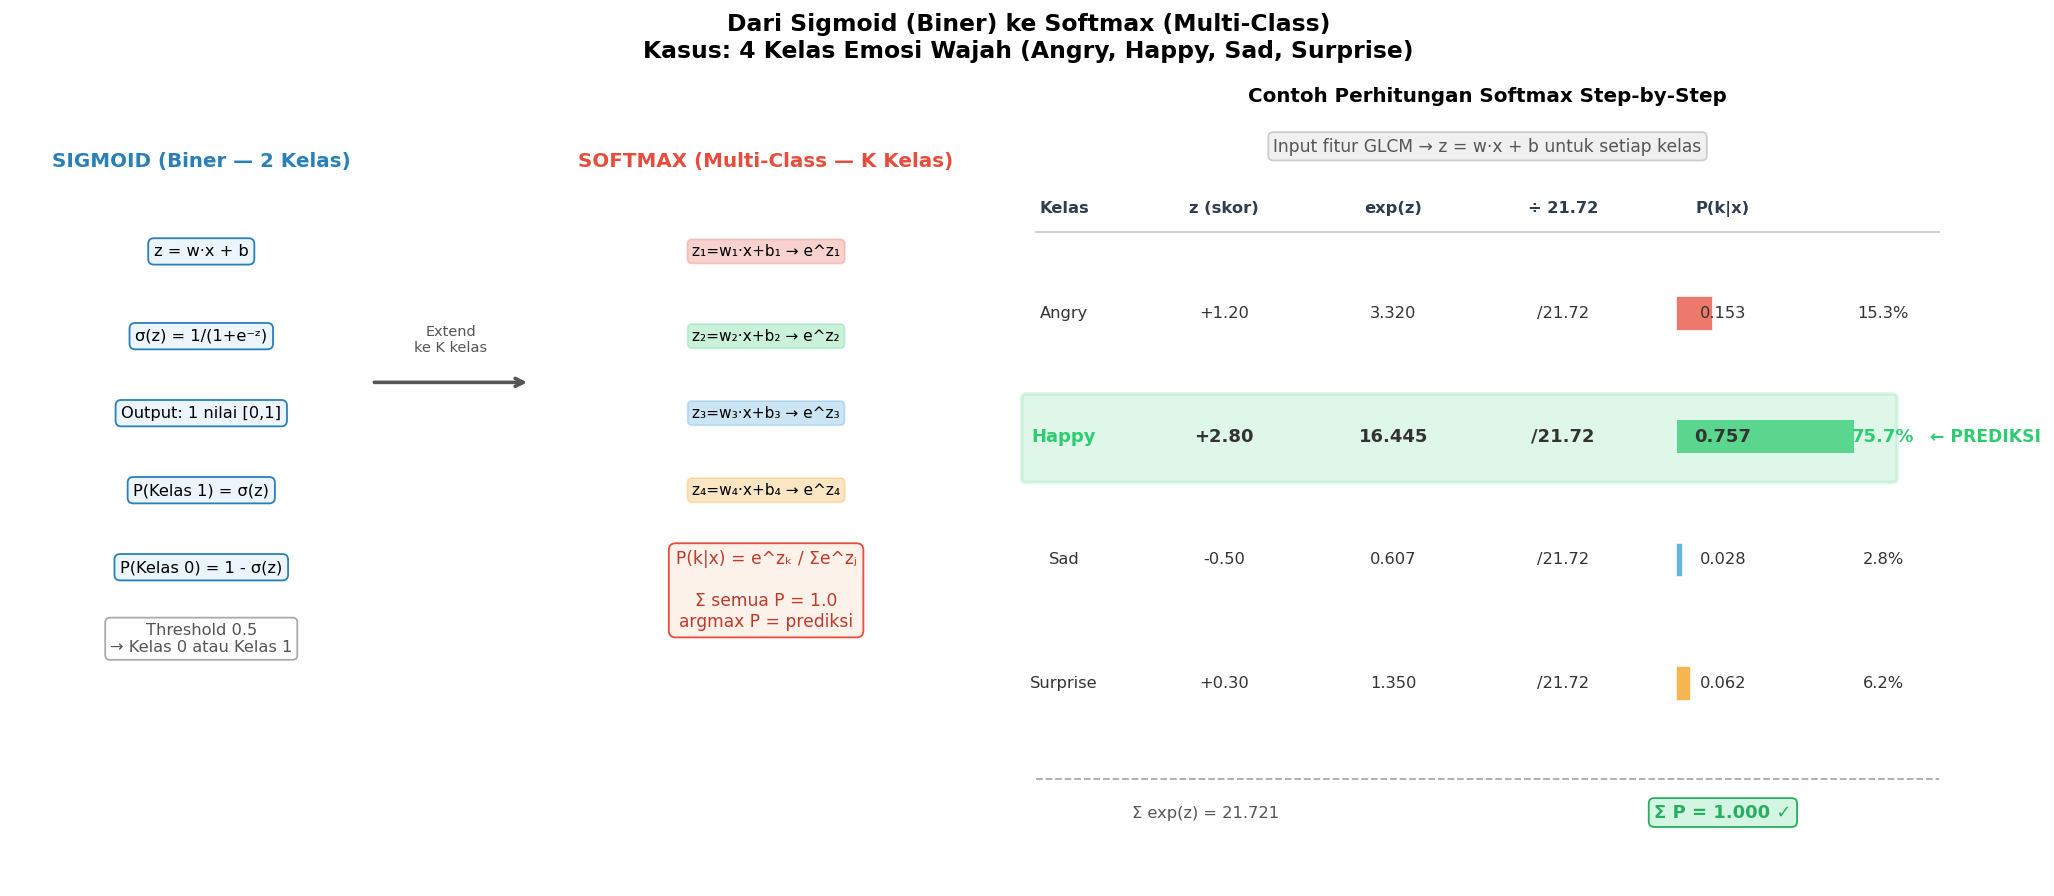

Disimpan: outputs\figures\LR_03_sigmoid_to_softmax.png

Semua visualisasi Logistic Regression selesai!
   LR_01_sigmoid_basics.png         — Kurva sigmoid + Linear vs Logistic
   LR_02_decision_boundary_binary.png— Decision boundary + keterbatasan linear
   LR_03_sigmoid_to_softmax.png      — Sigmoid → Softmax + contoh numerik


In [47]:
#  CELL 3.0b — Visualisasi Sigmoid, Logistic Regression Biner
#              & Perbandingan Linear vs Logistic

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap

np.random.seed(42)

# Figure 1: Kurva Sigmoid + Interpretasi

z_range = np.linspace(-8, 8, 400)
sigmoid  = 1 / (1 + np.exp(-z_range))

fig1, axes1 = plt.subplots(1, 3, figsize=(18, 6))
fig1.suptitle(
    'Fungsi Sigmoid: Jantung Logistic Regression\n'
    r'$\sigma(z) = \frac{1}{1+e^{-z}}$  — Mengubah Bilangan Real menjadi Probabilitas [0,1]',
    fontsize=13, fontweight='bold'
)

# Panel 1: Kurva sigmoid murni 
ax = axes1[0]
ax.plot(z_range, sigmoid, color='#2980b9', lw=3, zorder=5, label='σ(z)')
ax.axhline(0.5, color='#e74c3c', lw=1.5, ls='--', alpha=0.8, label='Threshold = 0.5')
ax.axvline(0.0, color='#555',    lw=1,   ls=':', alpha=0.6)

# Shade: kiri = kelas 0, kanan = kelas 1
ax.fill_between(z_range, sigmoid, 0.5,
                where=(z_range < 0), alpha=0.12, color='#e74c3c',
                label='Prediksi Kelas 0 (TIDAK)')
ax.fill_between(z_range, sigmoid, 0.5,
                where=(z_range > 0), alpha=0.12, color='#2ecc71',
                label='Prediksi Kelas 1 (YA)')

# Anotasi titik penting
for z_ex, label, color, va in [
    (-6,   'σ(-6)≈0.002\n→ sangat yakin Kelas 0', '#e74c3c', 'bottom'),
    (0,    'σ(0)=0.500\n→ tidak yakin', '#888', 'top'),
    (+6,   'σ(+6)≈0.998\n→ sangat yakin Kelas 1', '#27ae60', 'top'),
]:
    s_val = 1/(1+np.exp(-z_ex))
    ax.scatter(z_ex, s_val, s=100, color=color, zorder=10)
    ax.annotate(label, (z_ex, s_val), textcoords='offset points',
                xytext=(8, 12 if va=='top' else -35),
                fontsize=8, color=color,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

ax.set_xlabel('z  (kombinasi linear: w·x + b)', fontsize=10)
ax.set_ylabel('σ(z)  — Probabilitas', fontsize=10)
ax.set_title('Kurva Sigmoid (Bentuk S)\nOutput: selalu antara 0 dan 1', fontsize=10)
ax.set_ylim(-0.05, 1.08); ax.set_xlim(-8, 8)
ax.legend(fontsize=8.5, loc='upper left')
ax.grid(alpha=0.25, ls='--')

# Rumus di bawah
ax.text(0.5, -0.18,
        r'Rumus: $\sigma(z) = \frac{1}{1+e^{-z}}$'
        '    |    z = w₁x₁ + w₂x₂ + ... + b',
        transform=ax.transAxes, ha='center', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='#ebf5fb', edgecolor='#2980b9'))

# Panel 2: Perbandingan Linear vs Logistic
ax = axes1[1]

# Data sintetis 1D: nilai fitur vs label (0=non-happy, 1=happy)
x_data = np.array([0.1, 0.15, 0.2, 0.22, 0.25, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85])
y_data = np.array([0,   0,    0,   0,    0,    1,   1,   1,    1,   1,   1,    1  ])
x_plot = np.linspace(0, 1, 300)

# Linear regression fit (pakai np.polyfit)
coeffs   = np.polyfit(x_data, y_data, 1)
y_linear = np.polyval(coeffs, x_plot)

# Logistic fit (manual sederhana)
# Pakai sklearn untuk mendapatkan fit yang benar
from sklearn.linear_model import LogisticRegression as LR_demo
lr_demo = LR_demo(random_state=42, max_iter=1000)
lr_demo.fit(x_data.reshape(-1,1), y_data)
y_logistic = lr_demo.predict_proba(x_plot.reshape(-1,1))[:, 1]

ax.scatter(x_data, y_data, s=120, zorder=10,
           c=['#e74c3c' if y==0 else '#2ecc71' for y in y_data],
           edgecolors='black', linewidth=1.2,
           label='Data (0=non-happy, 1=happy)')

ax.plot(x_plot, y_linear,   color='#e67e22', lw=2.5, ls='--',
        label=f'Linear Regression\n(bisa keluar range [0,1]!)')
ax.plot(x_plot, y_logistic, color='#2980b9', lw=3,
        label='Logistic Regression\n(selalu dalam [0,1])')

ax.axhline(0.0, color='gray', lw=0.8, alpha=0.5)
ax.axhline(1.0, color='gray', lw=0.8, alpha=0.5)
ax.axhline(0.5, color='#e74c3c', lw=1.2, ls=':', alpha=0.7, label='Threshold 0.5')

# Highlight area masalah linear regression
ax.fill_between(x_plot, y_linear, 1.0,
                where=(y_linear > 1.0), alpha=0.2, color='#e74c3c',
                label='Linear melewati 1.0')
ax.fill_between(x_plot, y_linear, 0.0,
                where=(y_linear < 0.0), alpha=0.2, color='#e74c3c')

ax.set_xlabel('Nilai Fitur (misal: Contrast)', fontsize=10)
ax.set_ylabel('Probabilitas / Label', fontsize=10)
ax.set_title('Linear vs Logistic Regression\nMengapa Linear Tidak Cocok?', fontsize=10)
ax.set_ylim(-0.25, 1.35); ax.set_xlim(0, 1)
ax.legend(fontsize=7.5, loc='upper left')
ax.grid(alpha=0.25, ls='--')

# Anotasi masalah
ax.annotate('Linear bisa > 1\n(tidak valid!)',
            xy=(0.93, float(np.polyval(coeffs, 0.93))),
            xytext=(0.68, 1.22),
            fontsize=8, color='#c0392b', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#c0392b'))

# Panel 3: Sigmoid dengan berbagai w (kemiringan)
ax = axes1[2]
w_values  = [0.5, 1.0, 2.0, 5.0]
w_colors  = ['#3498db', '#2ecc71', '#e67e22', '#e74c3c']
b_fixed   = 0.0   # bias = 0, threshold di x=0

for w, wc in zip(w_values, w_colors):
    z_w  = w * z_range + b_fixed
    sig_w = 1 / (1 + np.exp(-z_w))
    ax.plot(z_range, sig_w, color=wc, lw=2.5,
            label=f'w={w} (lebih {"curam" if w>1 else "landai"})')

ax.axhline(0.5, color='black', lw=1, ls='--', alpha=0.5)
ax.axvline(0.0, color='black', lw=0.8, ls=':', alpha=0.4)
ax.set_xlabel('Nilai Fitur x', fontsize=10)
ax.set_ylabel('σ(w·x + b)', fontsize=10)
ax.set_title('Efek Bobot w pada Kurva Sigmoid\n'
             'w besar → kurva lebih curam → lebih "yakin"', fontsize=10)
ax.set_ylim(-0.05, 1.08); ax.set_xlim(-8, 8)
ax.legend(fontsize=9)
ax.grid(alpha=0.25, ls='--')

ax.text(0.5, -0.18,
        'w besar → transisi tajam (model sangat "tegas")\n'
        'w kecil → transisi landai (model "ragu-ragu")',
        transform=ax.transAxes, ha='center', fontsize=8.5,
        bbox=dict(boxstyle='round', facecolor='#fef9e7', edgecolor='#f39c12'))

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(str(OUT_FIGS / 'LR_01_sigmoid_basics.png'), bbox_inches='tight', dpi=150)
plt.show()
print("Disimpan:", OUT_FIGS / 'LR_01_sigmoid_basics.png')


# Figure 2: Decision Boundary Biner dalam Ruang 2D 

fig2, axes2 = plt.subplots(1, 3, figsize=(18, 6.5))
fig2.suptitle(
    'Logistic Regression — Decision Boundary Linear dalam Ruang Fitur\n'
    'Garis batas keputusan = di mana σ(w·x+b) = 0.5  →  w·x+b = 0',
    fontsize=13, fontweight='bold'
)

# Data sintetis 2D (2 kelas, agak separable)
np.random.seed(0)
n = 120
X_0 = np.random.randn(n//2, 2) + np.array([-2, -1])
X_1 = np.random.randn(n//2, 2) + np.array([+2, +1])
X_2d = np.vstack([X_0, X_1])
y_2d = np.array([0]*(n//2) + [1]*(n//2))

from sklearn.linear_model import LogisticRegression as LR2
from sklearn.preprocessing import StandardScaler

scaler_2d = StandardScaler()
X_2d_sc   = scaler_2d.fit_transform(X_2d)
lr_2d_bin = LR2(random_state=42, max_iter=1000)
lr_2d_bin.fit(X_2d_sc, y_2d)
acc_2d_bin = lr_2d_bin.score(X_2d_sc, y_2d)

x1_min, x1_max = X_2d_sc[:,0].min()-0.7, X_2d_sc[:,0].max()+0.7
x2_min, x2_max = X_2d_sc[:,1].min()-0.7, X_2d_sc[:,1].max()+0.7
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 300),
                        np.linspace(x2_min, x2_max, 300))
Z2d   = lr_2d_bin.predict_proba(np.c_[xx1.ravel(), xx2.ravel()])[:,1].reshape(xx1.shape)
Z2d_c = lr_2d_bin.predict(np.c_[xx1.ravel(), xx2.ravel()]).reshape(xx1.shape)

# Panel 1: Probabilitas (gradient) + boundary 
ax = axes2[0]
cont = ax.contourf(xx1, xx2, Z2d, levels=50, cmap='RdYlGn', alpha=0.7, vmin=0, vmax=1)
plt.colorbar(cont, ax=ax, label='P(Kelas 1)', fraction=0.04)
ax.contour(xx1, xx2, Z2d, levels=[0.5], colors='black', linewidths=2.5,
           linestyles='-')
ax.scatter(X_2d_sc[y_2d==0,0], X_2d_sc[y_2d==0,1],
           c='#e74c3c', marker='o', s=50, alpha=0.7, edgecolors='w',
           linewidth=0.6, label='Kelas 0 (non-happy)')
ax.scatter(X_2d_sc[y_2d==1,0], X_2d_sc[y_2d==1,1],
           c='#2ecc71', marker='s', s=50, alpha=0.7, edgecolors='w',
           linewidth=0.6, label='Kelas 1 (happy)')
ax.set_xlabel('Fitur 1 (misal: Contrast terstandarisasi)')
ax.set_ylabel('Fitur 2 (misal: Homogeneity terstandarisasi)')
ax.set_title(f'Gradient Probabilitas + Decision Boundary\n'
             f'(garis hitam tebal = boundary, akurasi={acc_2d_bin:.0%})',
             fontsize=10)
ax.legend(fontsize=8.5)

# Anotasi boundary
w1, w2 = lr_2d_bin.coef_[0]
b_      = lr_2d_bin.intercept_[0]
ax.text(0.05, 0.06,
        f'Persamaan boundary:\n{w1:.2f}x₁ + {w2:.2f}x₂ + ({b_:.2f}) = 0\n= Garis LURUS!',
        transform=ax.transAxes, fontsize=8,
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='black', alpha=0.85))

# Panel 2: Mengapa boundary LINEAR = keterbatasan
# Buat data yang TIDAK linear separable (dua lingkaran)
np.random.seed(7)
from sklearn.datasets import make_circles
X_circ, y_circ = make_circles(n_samples=200, noise=0.12, factor=0.45, random_state=7)
scaler_c = StandardScaler()
X_circ_sc = scaler_c.fit_transform(X_circ)
lr_circ = LR2(random_state=42, max_iter=1000)
lr_circ.fit(X_circ_sc, y_circ)
acc_circ = lr_circ.score(X_circ_sc, y_circ)

xx_c, yy_c = np.meshgrid(np.linspace(-2.5, 2.5, 300),
                           np.linspace(-2.5, 2.5, 300))
Z_circ = lr_circ.predict(np.c_[xx_c.ravel(), yy_c.ravel()]).reshape(xx_c.shape)

ax = axes2[1]
ax.contourf(xx_c, yy_c, Z_circ, alpha=0.2, cmap='RdYlGn', levels=[-0.5, 0.5, 1.5])
ax.contour(xx_c, yy_c, Z_circ, levels=[0.5], colors='black', linewidths=2.5,
           linestyles='--')
ax.scatter(X_circ_sc[y_circ==0,0], X_circ_sc[y_circ==0,1],
           c='#e74c3c', s=35, alpha=0.7, edgecolors='w', linewidth=0.5, label='Kelas 0')
ax.scatter(X_circ_sc[y_circ==1,0], X_circ_sc[y_circ==1,1],
           c='#2ecc71', s=35, alpha=0.7, edgecolors='w', linewidth=0.5,
           marker='s', label='Kelas 1')
ax.set_xlabel('Fitur 1'); ax.set_ylabel('Fitur 2')
ax.set_title(f'Keterbatasan Boundary LINEAR\n'
             f'Data melingkar → LR gagal! (akurasi={acc_circ:.0%})',
             fontsize=10)
ax.legend(fontsize=8.5)
ax.text(0.5, 0.02,
        'Boundary hanya bisa berupa garis lurus\n'
        '→ Data melingkar/overlap tidak bisa dipisahkan!',
        transform=ax.transAxes, ha='center', fontsize=8.5,
        bbox=dict(boxstyle='round', facecolor='#fdf2e9', edgecolor='#e67e22'))

# Panel 3: Ilustrasi probabilitas vs jarak dari boundary 
ax = axes2[2]
# Hitung jarak dari boundary untuk data di panel 1
dist = (X_2d_sc @ lr_2d_bin.coef_[0] + lr_2d_bin.intercept_[0])
prob = lr_2d_bin.predict_proba(X_2d_sc)[:,1]

scatter_c = ['#e74c3c' if y==0 else '#2ecc71' for y in y_2d]
ax.scatter(dist, prob, c=scatter_c, s=50, alpha=0.7, edgecolors='w', linewidth=0.5)

z_dense = np.linspace(dist.min()-0.5, dist.max()+0.5, 200)
ax.plot(z_dense, 1/(1+np.exp(-z_dense)), color='#2980b9', lw=3,
        label='Sigmoid fit', zorder=5)
ax.axhline(0.5, color='black', lw=1.2, ls='--', alpha=0.6, label='Threshold 0.5')
ax.axvline(0.0, color='gray',  lw=0.8, ls=':', alpha=0.5)
ax.set_xlabel('Jarak dari Decision Boundary (w·x + b)')
ax.set_ylabel('P(Kelas 1) = σ(z)')
ax.set_title('Probabilitas vs Jarak dari Boundary\n'
             'Semakin jauh dari garis → semakin yakin', fontsize=10)
ax.legend(fontsize=9)
ax.grid(alpha=0.25, ls='--')

# Anotasi zona
ax.axvspan(dist.min()-0.5, 0, alpha=0.07, color='#e74c3c')
ax.axvspan(0, dist.max()+0.5, alpha=0.07, color='#2ecc71')
ax.text(-2.2, 0.15, 'Zona\nKelas 0', color='#e74c3c', fontsize=9, ha='center')
ax.text(+2.0, 0.85, 'Zona\nKelas 1', color='#27ae60', fontsize=9, ha='center')

plt.tight_layout()
plt.savefig(str(OUT_FIGS / 'LR_02_decision_boundary_binary.png'), bbox_inches='tight', dpi=150)
plt.show()
print("Disimpan:", OUT_FIGS / 'LR_02_decision_boundary_binary.png')


# Figure 3: Sigmoid → Softmax (dari biner ke 4 kelas)

fig3, axes3 = plt.subplots(1, 2, figsize=(16, 7))
fig3.suptitle(
    'Dari Sigmoid (Biner) ke Softmax (Multi-Class)\n'
    'Kasus: 4 Kelas Emosi Wajah (Angry, Happy, Sad, Surprise)',
    fontsize=13, fontweight='bold'
)

# Panel 1: Sigmoid vs Softmax konsep
ax = axes3[0]
ax.axis('off')
ax.set_xlim(0, 10); ax.set_ylim(0, 10)

# Sigmoid (biner)
ax.text(2, 9.3, 'SIGMOID (Biner — 2 Kelas)', ha='center',
        fontsize=11, fontweight='bold', color='#2980b9')
sigmoid_box_data = [
    ('z = w·x + b', 2, 8.2, '#ebf5fb', '#2980b9'),
    ('σ(z) = 1/(1+e⁻ᶻ)', 2, 7.1, '#ebf5fb', '#2980b9'),
    ('Output: 1 nilai [0,1]', 2, 6.1, '#ebf5fb', '#2980b9'),
    ('P(Kelas 1) = σ(z)', 2, 5.1, '#ebf5fb', '#2980b9'),
    ('P(Kelas 0) = 1 - σ(z)', 2, 4.1, '#ebf5fb', '#2980b9'),
]
for txt, xpos, ypos, fc, ec in sigmoid_box_data:
    ax.text(xpos, ypos, txt, ha='center', va='center', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.35', facecolor=fc, edgecolor=ec))

ax.text(2, 3.0, 'Threshold 0.5\n→ Kelas 0 atau Kelas 1',
        ha='center', fontsize=9, color='#555',
        bbox=dict(boxstyle='round', facecolor='#fefefe', edgecolor='#aaa'))

# Panah tengah
ax.annotate('', xy=(5.5, 6.5), xytext=(3.8, 6.5),
            arrowprops=dict(arrowstyle='->', color='#555', lw=2))
ax.text(4.65, 6.9, 'Extend\nke K kelas', ha='center', fontsize=8, color='#555')

# Softmax (multi-class)
ax.text(8, 9.3, 'SOFTMAX (Multi-Class — K Kelas)', ha='center',
        fontsize=11, fontweight='bold', color='#e74c3c')
softmax_items = [
    ('z₁=w₁·x+b₁ → e^z₁', 'ANGRY',   '#e74c3c', 8, 8.2),
    ('z₂=w₂·x+b₂ → e^z₂', 'HAPPY',   '#2ecc71', 8, 7.1),
    ('z₃=w₃·x+b₃ → e^z₃', 'SAD',     '#3498db', 8, 6.1),
    ('z₄=w₄·x+b₄ → e^z₄', 'SURPRISE','#f39c12', 8, 5.1),
]
for formula, label, color, xp, yp in softmax_items:
    ax.text(xp, yp, formula, ha='center', va='center', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.25,
                      edgecolor=color))

ax.text(8, 3.8,
        'P(k|x) = e^zₖ / Σe^zⱼ\n\nΣ semua P = 1.0\nargmax P = prediksi',
        ha='center', va='center', fontsize=9.5, color='#c0392b',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#fdf2e9', edgecolor='#e74c3c'))

# Panel 2: Contoh numerik softmax step-by-step
ax = axes3[1]

# Contoh dari gambar (sama dengan diagram di cell 3.0)
classes  = ['Angry', 'Happy', 'Sad', 'Surprise']
colors_c = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']
z_vals   = [1.20, 2.80, -0.50, 0.30]
exp_vals = [np.exp(z) for z in z_vals]
sum_exp  = sum(exp_vals)
probs    = [e/sum_exp for e in exp_vals]

ax.axis('off')
ax.set_xlim(0, 10); ax.set_ylim(0, 10)
ax.set_title('Contoh Perhitungan Softmax Step-by-Step', fontsize=11, fontweight='bold')

# Header
ax.text(5, 9.5, f'Input fitur GLCM → z = w·x + b untuk setiap kelas',
        ha='center', fontsize=9.5, color='#555',
        bbox=dict(boxstyle='round', facecolor='#f0f0f0', edgecolor='#ccc'))

col_headers = ['Kelas', 'z (skor)', 'exp(z)', f'÷ {sum_exp:.2f}', 'P(k|x)', '']
col_xs = [0.5, 2.2, 4.0, 5.8, 7.5, 9.2]
for hdr, cx in zip(col_headers, col_xs):
    ax.text(cx, 8.7, hdr, ha='center', fontsize=9, fontweight='bold', color='#2c3e50')
ax.axhline(8.45, xmin=0.02, xmax=0.98, color='#ccc', lw=1)

for k, (cls, col, z, ev, p) in enumerate(zip(classes, colors_c, z_vals, exp_vals, probs)):
    ypos = 7.4 - k * 1.6
    is_pred = (k == np.argmax(probs))

    # Background row untuk prediksi
    if is_pred:
        ax.add_patch(mpatches.FancyBboxPatch((0.1, ypos-0.55), 9.2, 1.05,
                                              boxstyle='round,pad=0.05',
                                              facecolor=col, alpha=0.15,
                                              edgecolor=col, linewidth=2))

    vals_row = [cls, f'{z:+.2f}', f'{ev:.3f}', f'/{sum_exp:.2f}', f'{p:.3f}', f'{p:.1%}']
    fweights  = ['bold' if is_pred else 'normal'] * len(vals_row)
    for val, cx, fw in zip(vals_row, col_xs, fweights):
        ax.text(cx, ypos, val, ha='center', va='center',
                fontsize=10 if is_pred else 9,
                fontweight=fw,
                color=col if (is_pred and cx in [col_xs[0], col_xs[-1]]) else '#333')

    # Bar probabilitas visual
    bar_w = p * 2.5
    ax.add_patch(mpatches.Rectangle((7.0, ypos - 0.22), bar_w, 0.44,
                                     facecolor=col, alpha=0.75,
                                     edgecolor='white', linewidth=0.5))

    if is_pred:
        ax.text(9.7, ypos, '← PREDIKSI', va='center', fontsize=9.5,
                color=col, fontweight='bold')

# Total
ax.axhline(1.35, xmin=0.02, xmax=0.98, color='#aaa', lw=1, ls='--')
ax.text(7.5, 0.85, f'Σ P = {sum(probs):.3f} ✓', ha='center', fontsize=10,
        fontweight='bold', color='#27ae60',
        bbox=dict(boxstyle='round', facecolor='#d5f5e3', edgecolor='#27ae60'))
ax.text(2.0, 0.85, f'Σ exp(z) = {sum_exp:.3f}', ha='center', fontsize=9, color='#555')

plt.tight_layout()
plt.savefig(str(OUT_FIGS / 'LR_03_sigmoid_to_softmax.png'), bbox_inches='tight', dpi=150)
plt.show()
print("Disimpan:", OUT_FIGS / 'LR_03_sigmoid_to_softmax.png')

print("\nSemua visualisasi Logistic Regression selesai!")
print("   LR_01_sigmoid_basics.png         — Kurva sigmoid + Linear vs Logistic")
print("   LR_02_decision_boundary_binary.png— Decision boundary + keterbatasan linear")
print("   LR_03_sigmoid_to_softmax.png      — Sigmoid → Softmax + contoh numerik")


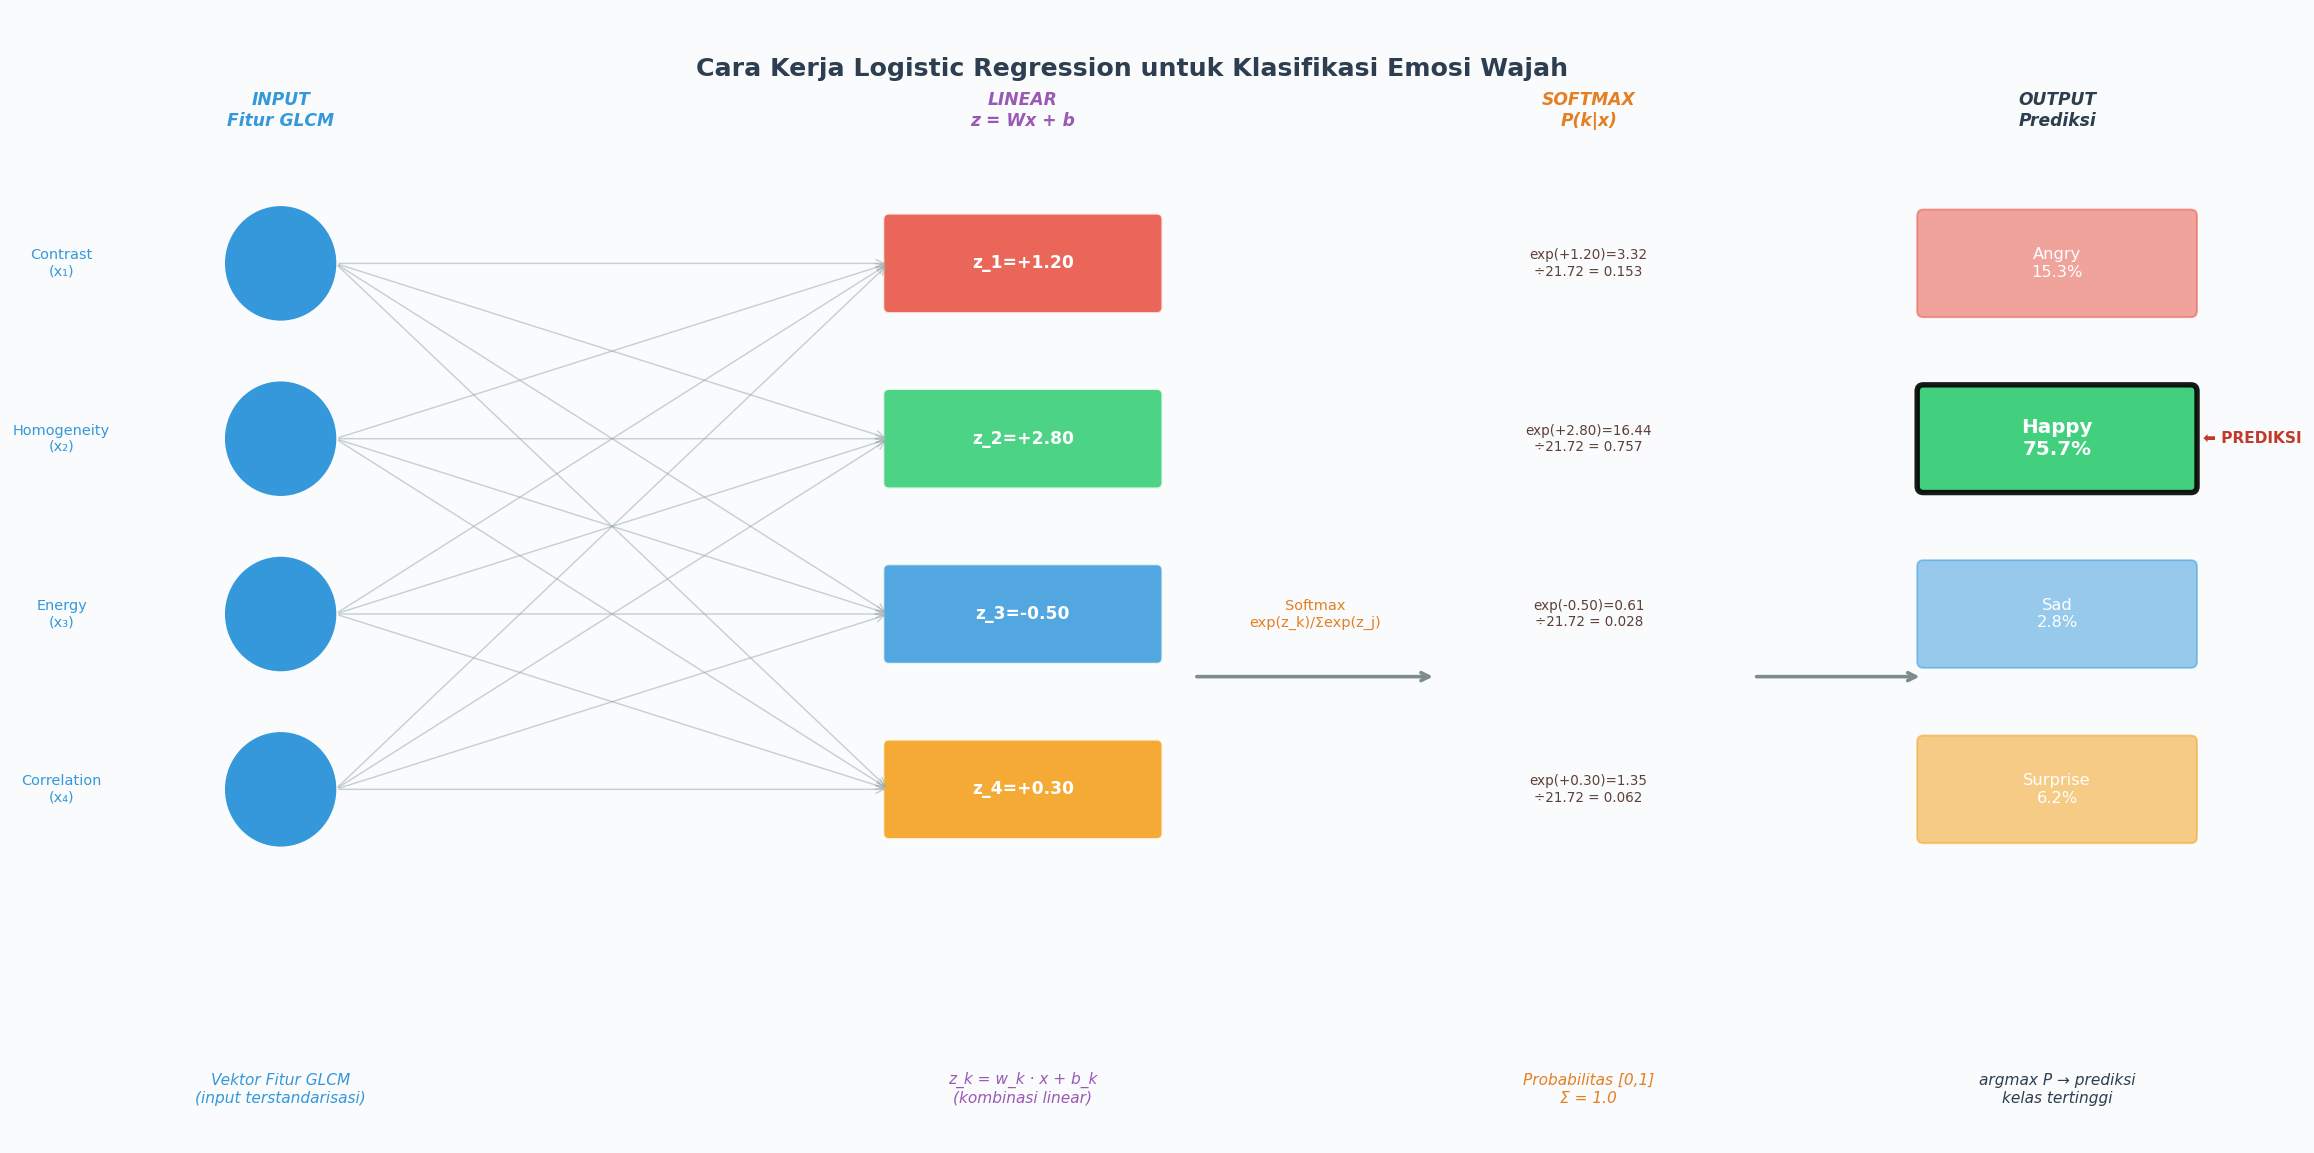

Disimpan: outputs\figures\09_logistic_regression_diagram.png


In [48]:
#  CELL 3.0 — Visualisasi Konsep Logistic Regression

fig = plt.figure(figsize=(18, 9))
fig.patch.set_facecolor('#fafbfc')
ax = fig.add_subplot(111)
ax.set_xlim(0, 18); ax.set_ylim(0, 9)
ax.axis('off')
ax.set_facecolor('#fafbfc')

# Judul
ax.text(9, 8.5, 'Cara Kerja Logistic Regression untuk Klasifikasi Emosi Wajah',
        ha='center', fontsize=14, fontweight='bold', color='#2c3e50')

# Warna layer 
C_INPUT   = '#3498db'   # Biru: input
C_LINEAR  = '#9b59b6'   # Ungu: layer linear
C_SOFTMAX = '#e67e22'   # Oranye: softmax
C_OUTPUT  = COLORS      # Warna kelas

feat_names = ['Contrast\n(x₁)', 'Homogeneity\n(x₂)', 'Energy\n(x₃)', 'Correlation\n(x₄)']
class_names_short = ['Angry', 'Happy', 'Sad', 'Surprise']

# Layer Input 
for i, (fn, fv) in enumerate(zip(feat_names, [0.42, 0.71, 0.08, 0.89])):
    y_pos = 7 - i * 1.4
    circ = plt.Circle((2, y_pos), 0.45, color=C_INPUT, zorder=5)
    ax.add_patch(circ)
    ax.text(2, y_pos, f'{fv:.2f}', ha='center', va='center',
            fontsize=9, color='white', fontweight='bold')
    ax.text(0.2, y_pos, fn, ha='center', va='center', fontsize=8, color=C_INPUT)

ax.text(2, 0.3, 'Vektor Fitur GLCM\n(input terstandarisasi)', ha='center',
        fontsize=8.5, color=C_INPUT, style='italic')

# Layer Linear z = Wx + b
z_examples = [1.2, 2.8, -0.5, 0.3]
for k, (cls, col, zv) in enumerate(zip(class_names_short, C_OUTPUT, z_examples)):
    y_pos = 7 - k * 1.4
    # Koneksi dari semua input ke z_k
    for i in range(4):
        y_in = 7 - i * 1.4
        ax.annotate('', xy=(7, y_pos), xytext=(2.45, y_in),
                    arrowprops=dict(arrowstyle='->', color='#95a5a6',
                                    lw=0.8, alpha=0.5))
    rect = mpatches.FancyBboxPatch((7, y_pos-0.35), 2.2, 0.7,
                                    boxstyle='round,pad=0.05',
                                    facecolor=col, edgecolor='white',
                                    linewidth=1.5, alpha=0.85)
    ax.add_patch(rect)
    ax.text(8.1, y_pos, f'z_{k+1}={zv:+.2f}', ha='center', va='center',
            fontsize=9.5, color='white', fontweight='bold')

ax.text(8.1, 0.3, 'z_k = w_k · x + b_k\n(kombinasi linear)', ha='center',
        fontsize=8.5, color=C_LINEAR, style='italic')

# Panah ke Softmax
ax.annotate('', xy=(11.5, 3.7), xytext=(9.5, 3.7),
            arrowprops=dict(arrowstyle='->', color='#7f8c8d', lw=2))
ax.text(10.5, 4.1, 'Softmax\nexp(z_k)/Σexp(z_j)', ha='center', fontsize=8, color=C_SOFTMAX)

# Softmax box
# softmax_rect = mpatches.FancyBboxPatch((11.5, 1.2), 2.5, 5.2,
#                                         boxstyle='round,pad=0.1',
#                                         facecolor='#fff3e0', edgecolor=C_SOFTMAX,
#                                         linewidth=2)
# ax.add_patch(softmax_rect)

# Kalkulasi softmax
z_arr = np.array(z_examples)
exp_z = np.exp(z_arr)
probs = exp_z / exp_z.sum()
for k, (cls, col, zv, pv) in enumerate(zip(class_names_short, C_OUTPUT, z_examples, probs)):
    y_pos = 7 - k * 1.4
    ax.text(12.75, y_pos,
            f'exp({zv:+.2f})={np.exp(zv):.2f}\n÷{exp_z.sum():.2f} = {pv:.3f}',
            ha='center', va='center', fontsize=7.5, color='#5d4037')

ax.text(12.75, 0.3, 'Probabilitas [0,1]\nΣ = 1.0', ha='center',
        fontsize=8.5, color=C_SOFTMAX, style='italic')

# Output prediksi
ax.annotate('', xy=(15.5, 3.7), xytext=(14.1, 3.7),
            arrowprops=dict(arrowstyle='->', color='#7f8c8d', lw=2))

for k, (cls, col, pv) in enumerate(zip(class_names_short, C_OUTPUT, probs)):
    y_pos = 7 - k * 1.4
    is_pred = (k == np.argmax(probs))
    lw   = 3 if is_pred else 1
    fcsz = 11 if is_pred else 9
    rect2 = mpatches.FancyBboxPatch((15.5, y_pos-0.38), 2.2, 0.76,
                                     boxstyle='round,pad=0.05',
                                     facecolor=col, edgecolor='black' if is_pred else col,
                                     linewidth=lw, alpha=0.9 if is_pred else 0.5)
    ax.add_patch(rect2)
    ax.text(16.6, y_pos, f'{cls}\n{pv:.1%}', ha='center', va='center',
            fontsize=fcsz, color='white', fontweight='bold' if is_pred else 'normal')
    if is_pred:
        ax.text(17.8, y_pos, '⬅ PREDIKSI', va='center', fontsize=8.5,
                color='#c0392b', fontweight='bold')

ax.text(16.6, 0.3, 'argmax P → prediksi\nkelas tertinggi', ha='center',
        fontsize=8.5, color='#2c3e50', style='italic')

# Label layer
for x_pos, lbl, col in [
    (2, 'INPUT\nFitur GLCM', C_INPUT),
    (8.1, 'LINEAR\nz = Wx + b', C_LINEAR),
    (12.75, 'SOFTMAX\nP(k|x)', C_SOFTMAX),
    (16.6, 'OUTPUT\nPrediksi', '#2c3e50'),
]:
    ax.text(x_pos, 8.1, lbl, ha='center', fontsize=9.5, fontweight='bold',
            color=col, style='italic')

plt.tight_layout()
plt.savefig(str(OUT_FIGS / '09_logistic_regression_diagram.png'), bbox_inches='tight', dpi=150)
plt.show()
print("Disimpan:", OUT_FIGS / '09_logistic_regression_diagram.png')


In [49]:
#  CELL 3.1 — Ekstraksi Fitur Massal + StandardScaler + Cache

le = LabelEncoder()
y_train = le.fit_transform(train_labels)
y_test  = le.transform(test_labels)

print("Pemetaan Label:")
for cls, lbl in zip(le.classes_, le.transform(le.classes_)):
    print(f"   {cls:10s} → {lbl}")

scenarios = {}

for level in LEVELS_TO_TEST:
    for agg in ['mean', 'concat']:
        key       = f"{level}-{agg}"
        feat_path = OUT_FEAT / f'features_{key}.pkl'

        if feat_path.exists():
            with open(feat_path, 'rb') as f:
                scenarios[key] = pickle.load(f)
            print(f"  Cache: {key} → shape {scenarios[key]['X_train'].shape}")
            continue

        print(f"  Ekstraksi {key}...", end=' ')
        X_tr_raw = np.array([
            extract_glcm_features(img, level, aggregation=agg)[0]
            for img in train_norm
        ], dtype=np.float32)
        X_te_raw = np.array([
            extract_glcm_features(img, level, aggregation=agg)[0]
            for img in test_norm
        ], dtype=np.float32)

        scaler  = StandardScaler()
        X_train_s = scaler.fit_transform(X_tr_raw)
        X_test_s  = scaler.transform(X_te_raw)

        data = {'X_train': X_train_s, 'X_test': X_test_s,
                'scaler': scaler, 'n_feat': X_train_s.shape[1]}
        scenarios[key] = data
        with open(feat_path, 'wb') as f:
            pickle.dump(data, f)
        print(f"{X_train_s.shape}")

print("\nSemua fitur siap!")


Pemetaan Label:
   angry      → 0
   happy      → 1
   sad        → 2
   surprise   → 3
  Ekstraksi 8-mean... (8112, 4)
  Ekstraksi 8-concat... (8112, 16)
  Ekstraksi 16-mean... (8112, 4)
  Ekstraksi 16-concat... (8112, 16)
  Ekstraksi 32-mean... (8112, 4)
  Ekstraksi 32-concat... (8112, 16)

Semua fitur siap!


In [50]:
#  CELL 3.2 — Training Logistic Regression (6 Skenario)

results = {}
print(f"{'Skenario':<20} {'Dim':>5} {'Acc Train':>11} {'Acc Test':>10}")
print("-" * 50)

for key, data in scenarios.items():
    model_path = OUT_MODELS / f'model_{key}.pkl'

    if model_path.exists():
        with open(model_path, 'rb') as f:
            model = pickle.load(f)
    else:
        model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
        model.fit(data['X_train'], y_train)
        with open(model_path, 'wb') as f:
            pickle.dump(model, f)

    y_pred_tr = model.predict(data['X_train'])
    y_pred_te = model.predict(data['X_test'])
    acc_tr    = accuracy_score(y_train, y_pred_tr)
    acc_te    = accuracy_score(y_test,  y_pred_te)

    results[key] = {
        'model': model, 'y_pred_test': y_pred_te,
        'acc_train': acc_tr, 'acc_test': acc_te
    }
    print(f"{key:<20} {data['n_feat']:>5} {acc_tr:>11.4f} {acc_te:>10.4f}")

best_key = max(results, key=lambda k: results[k]['acc_test'])
best_acc = results[best_key]['acc_test']
best_model  = results[best_key]['model']
X_tr_best   = scenarios[best_key]['X_train']
X_te_best   = scenarios[best_key]['X_test']

print("-" * 50)
print(f"\nTerbaik: '{best_key}' — Akurasi Test = {best_acc:.4f} ({best_acc:.2%})")


Skenario               Dim   Acc Train   Acc Test
--------------------------------------------------
8-mean                   4      0.3164     0.3077
8-concat                16      0.3725     0.3861
16-mean                  4      0.3104     0.3195
16-concat               16      0.3660     0.3767
32-mean                  4      0.3150     0.3294
32-concat               16      0.3622     0.3767
--------------------------------------------------

Terbaik: '8-concat' — Akurasi Test = 0.3861 (38.61%)


## Analisis Overfitting

**Overfitting** terjadi ketika model belajar terlalu spesifik pada data training  
sehingga performanya jauh lebih buruk pada data baru (test).

```
Indikator Overfitting:
  Gap besar antara Acc Train dan Acc Test → model hafal training, gagal generalisasi

Indikator Underfitting:
  Acc Train DAN Acc Test sama-sama rendah → model tidak cukup kompleks

Kondisi Ideal:
  Acc Train ≈ Acc Test (keduanya tinggi)
```

**Untuk Logistic Regression + GLCM:**
- LR adalah model sederhana (linear) → cenderung **underfitting** bukan overfitting
- Tetapi jika **fitur CONCAT (16D)** dan data kecil → bisa terjadi overfitting ringan
- Regularisasi parameter `C` mengontrol overfitting:
  - `C` besar → regularisasi lemah → bisa overfit
  - `C` kecil → regularisasi kuat → lebih general


  ANALISIS OVERFITTING — Train vs Test Gap

  Skenario              Acc Train   Acc Test      Gap         Status
  --------------------------------------------------------------
  8-mean                   0.3164     0.3077   0.0088       Underfit
  8-concat                 0.3725     0.3861  -0.0136             OK
  16-mean                  0.3104     0.3195  -0.0091       Underfit
  16-concat                0.3660     0.3767  -0.0107             OK
  32-mean                  0.3150     0.3294  -0.0144       Underfit
  32-concat                0.3622     0.3767  -0.0145             OK

  Gap terkecil : 32-concat (-0.0145)
  Gap terbesar : 8-mean (0.0088)


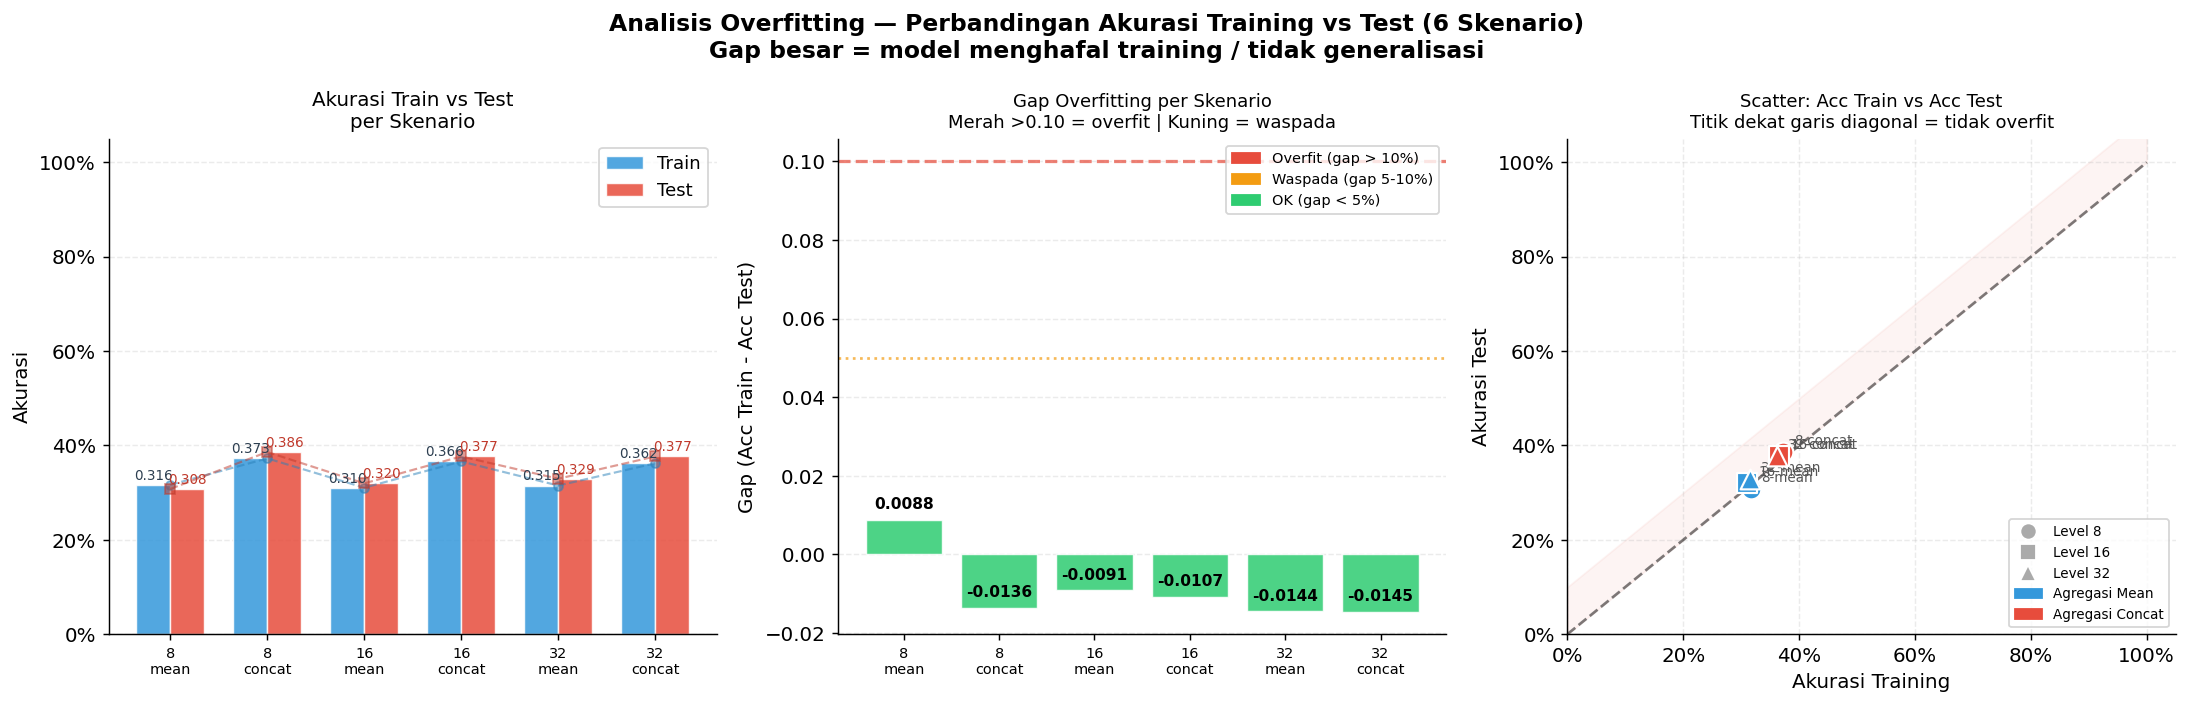

 Disimpan: outputs\figures\20_overfitting_analysis.png

 Menghitung Learning Curve (butuh beberapa menit)...


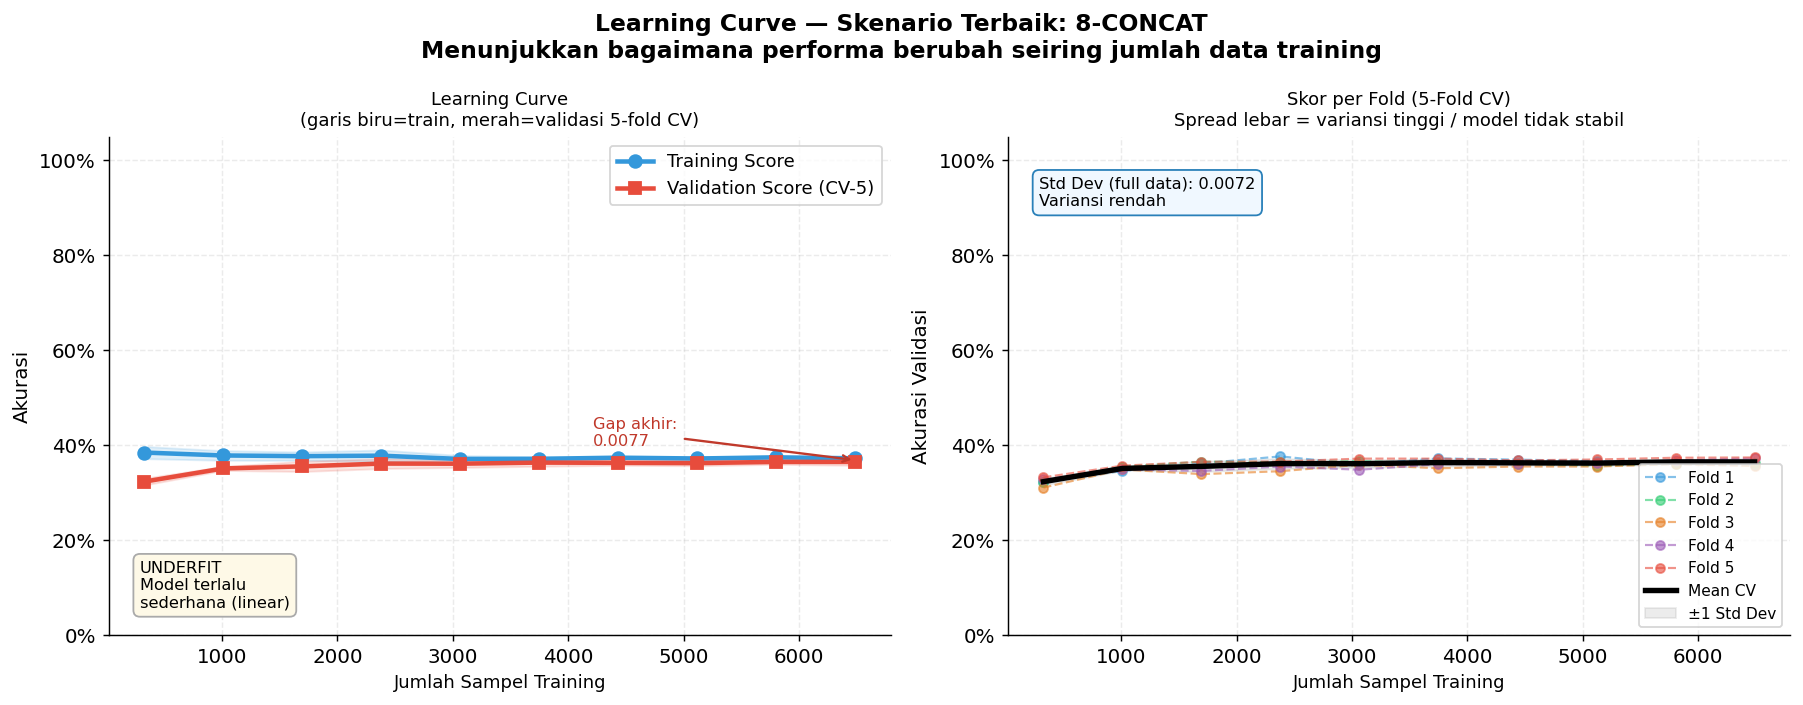

Disimpan: outputs\figures\21_learning_curve.png

Menguji berbagai nilai C (regularisasi)...


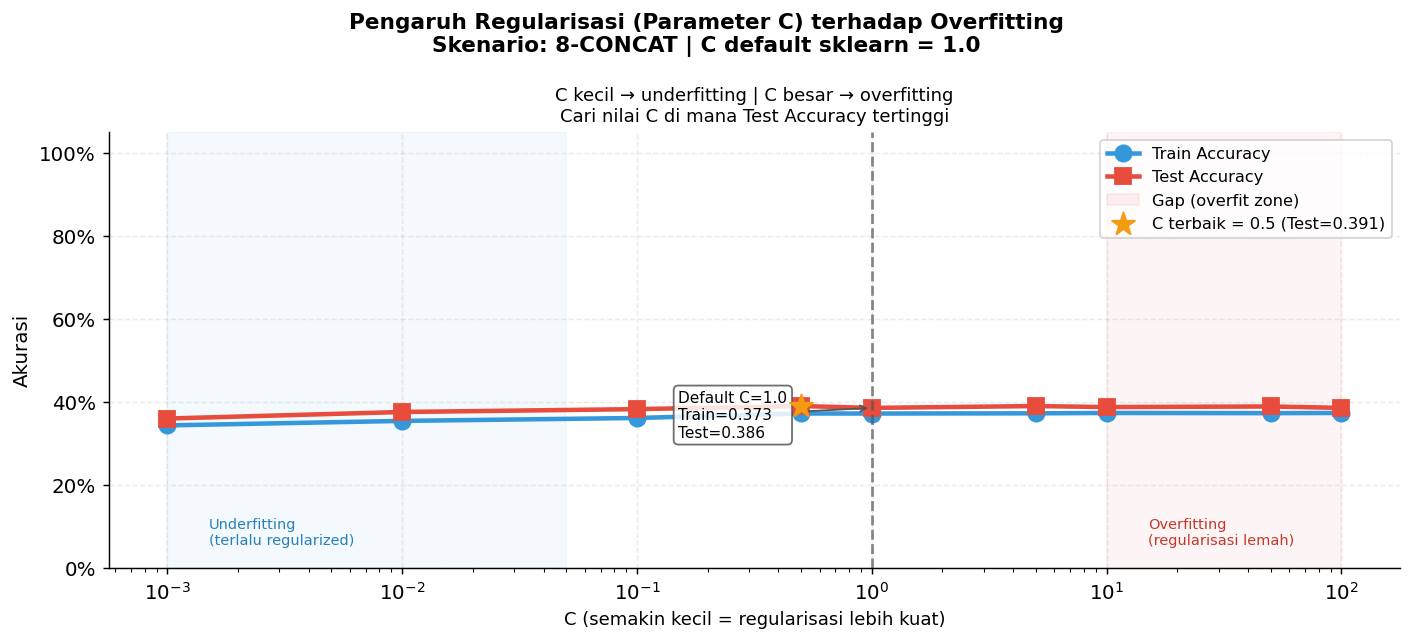

Disimpan: outputs\figures\22_regularization_C.png

  RINGKASAN ANALISIS OVERFITTING

  6 Skenario:
    Gap terbesar : 8-mean → 0.0088
    Gap terkecil : 32-concat → -0.0145

  Learning Curve (skenario terbaik: 8-concat):
    Train final  : 0.3724
    Val final    : 0.3648
    Gap final    : 0.0077
    Std Dev CV   : 0.0072

  Regularisasi C terbaik: 0.5
    (Test Accuracy = 0.3905)

  Kesimpulan:
    → Model LR + GLCM cenderung UNDERFIT (bukan overfit)
      karena model linear tidak cukup kompleks untuk
      menangkap pola non-linear ekspresi wajah.
    → Gap train-test yang ada lebih disebabkan oleh
      ketidakmampuan fitur GLCM membedakan kelas,
      bukan karena model menghafal data training.
    → Solusi: Gunakan CNN atau SVM-RBF yang bisa
      menangkap fitur non-linear dari gambar wajah.



In [51]:
#  CELL 3.2b — Analisis Overfitting: Train vs Test Gap

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import learning_curve

keys      = list(results.keys())
acc_train = [results[k]['acc_train'] for k in keys]
acc_test  = [results[k]['acc_test']  for k in keys]
gap       = [tr - te for tr, te in zip(acc_train, acc_test)]

print("=" * 62)
print("  ANALISIS OVERFITTING — Train vs Test Gap")
print("=" * 62)
print(f"\n  {'Skenario':<20} {'Acc Train':>10} {'Acc Test':>10} {'Gap':>8} {'Status':>14}")
print("  " + "-" * 62)
for k, tr, te, g in zip(keys, acc_train, acc_test, gap):
    if g > 0.10:
        status = "Overfit"
    elif te < 0.35:
        status = "Underfit"
    else:
        status = "OK"
    print(f"  {k:<20} {tr:>10.4f} {te:>10.4f} {g:>8.4f} {status:>14}")

best_gap = min(gap)
worst_gap = max(gap)
print(f"\n  Gap terkecil : {keys[gap.index(best_gap)]} ({best_gap:.4f})")
print(f"  Gap terbesar : {keys[gap.index(worst_gap)]} ({worst_gap:.4f})")


# Figure 1: Bar chart Train vs Test + Gap
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
fig.suptitle(
    "Analisis Overfitting — Perbandingan Akurasi Training vs Test (6 Skenario)\n"
    "Gap besar = model menghafal training / tidak generalisasi",
    fontsize=13, fontweight="bold"
)

x = np.arange(len(keys)); w = 0.35

# Panel 1: Bar Train vs Test
ax = axes[0]
b1 = ax.bar(x - w/2, acc_train, w, label="Train", color="#3498db", alpha=0.85,
            edgecolor="white", linewidth=0.8)
b2 = ax.bar(x + w/2, acc_test,  w, label="Test",  color="#e74c3c", alpha=0.85,
            edgecolor="white", linewidth=0.8)

for bar, val in zip(b1, acc_train):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
            f"{val:.3f}", ha="center", va="bottom", fontsize=7.5, color="#2c3e50")
for bar, val in zip(b2, acc_test):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
            f"{val:.3f}", ha="center", va="bottom", fontsize=7.5, color="#c0392b")

# Garis "ideal" — jika train=test tidak ada gap
ax.plot(x, acc_train, "o--", color="#2980b9", lw=1.2, ms=5, alpha=0.5)
ax.plot(x, acc_test,  "s--", color="#c0392b", lw=1.2, ms=5, alpha=0.5)

ax.set_xticks(x)
# PERBAIKAN 1: Menggunakan \n pada replace
ax.set_xticklabels([k.replace("-", "\n") for k in keys], fontsize=8)
ax.set_ylabel("Akurasi"); ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))

# PERBAIKAN 2: Menggunakan \n untuk baris baru pada string
ax.set_title("Akurasi Train vs Test\nper Skenario", fontsize=11)

ax.legend(fontsize=10); ax.grid(axis="y", alpha=0.25, ls="--"); ax.set_axisbelow(True)

# Panel 2: Gap (overfit indicator)
ax = axes[1]
gap_colors = ["#e74c3c" if g > 0.10 else "#f39c12" if g > 0.05 else "#2ecc71"
              for g in gap]
bars = ax.bar(x, gap, color=gap_colors, alpha=0.85, edgecolor="white", linewidth=0.8)
for bar, g_val in zip(bars, gap):
    ax.text(bar.get_x() + bar.get_width()/2,
            g_val + 0.002,
            f"{g_val:.4f}", ha="center", va="bottom", fontsize=8.5, fontweight="bold")

ax.axhline(0.10, color="#e74c3c", lw=1.8, ls="--", alpha=0.7, label="Threshold overfit (0.10)")
ax.axhline(0.05, color="#f39c12", lw=1.5, ls=":",  alpha=0.7, label="Threshold waspada (0.05)")
ax.set_xticks(x)

# PERBAIKAN 3: Menggunakan \n pada replace
ax.set_xticklabels([k.replace("-", "\n") for k in keys], fontsize=8)

ax.set_ylabel("Gap (Acc Train - Acc Test)")
ax.set_title("Gap Overfitting per Skenario\n"
             "Merah >0.10 = overfit | Kuning = waspada", fontsize=10)
ax.legend(fontsize=8.5); ax.grid(axis="y", alpha=0.25, ls="--"); ax.set_axisbelow(True)

# Legend warna
from matplotlib.patches import Patch
handles_leg = [
    Patch(color="#e74c3c", label="Overfit (gap > 10%)"),
    Patch(color="#f39c12", label="Waspada (gap 5-10%)"),
    Patch(color="#2ecc71", label="OK (gap < 5%)"),
]
ax.legend(handles=handles_leg, fontsize=8, loc="upper right")

# Panel 3: Scatter Train vs Test (ideal line)
ax = axes[2]
ax.plot([0, 1], [0, 1], "k--", lw=1.5, alpha=0.5, label="Ideal (train = test)")
ax.fill_between([0, 1], [0, 1], [0.1, 1.1], alpha=0.06, color="#e74c3c",
                label="Zona overfit (train >> test)")

level_markers = {"8": "o", "16": "s", "32": "^"}
agg_colors    = {"mean": "#3498db", "concat": "#e74c3c"}

for k, tr, te in zip(keys, acc_train, acc_test):
    lv, ag = k.split("-")
    ax.scatter(tr, te,
               marker=level_markers[lv],
               color=agg_colors[ag],
               s=120, zorder=5,
               edgecolors="white", linewidth=1.2)
    ax.annotate(k, (tr, te), textcoords="offset points",
                xytext=(6, 4), fontsize=7.5, color="#555")

ax.set_xlabel("Akurasi Training"); ax.set_ylabel("Akurasi Test")
ax.set_title("Scatter: Acc Train vs Acc Test\n"
             "Titik dekat garis diagonal = tidak overfit", fontsize=10)
ax.set_xlim(0, 1.05); ax.set_ylim(0, 1.05)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.grid(alpha=0.25, ls="--")

# Legend manual
from matplotlib.lines import Line2D
leg_items = [
    Line2D([0],[0], marker="o", color="w", markerfacecolor="#aaa", ms=9, label="Level 8"),
    Line2D([0],[0], marker="s", color="w", markerfacecolor="#aaa", ms=9, label="Level 16"),
    Line2D([0],[0], marker="^", color="w", markerfacecolor="#aaa", ms=9, label="Level 32"),
    Patch(color="#3498db", label="Agregasi Mean"),
    Patch(color="#e74c3c", label="Agregasi Concat"),
]
ax.legend(handles=leg_items, fontsize=7.5, loc="lower right")

plt.tight_layout()
plt.savefig(str(OUT_FIGS / "20_overfitting_analysis.png"), bbox_inches="tight", dpi=150)
plt.show()
print(" Disimpan:", OUT_FIGS / "20_overfitting_analysis.png")


# Figure 2: Learning Curve — model terbaik 
print("\n Menghitung Learning Curve (butuh beberapa menit)...")

X_lc = X_tr_best
y_lc = y_train

train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    X_lc, y_lc,
    train_sizes=np.linspace(0.05, 1.0, 10),
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    shuffle=True,
    random_state=RANDOM_STATE
)

tr_mean  = train_scores.mean(axis=1)
tr_std   = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std  = val_scores.std(axis=1)

fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5.5))
fig2.suptitle(
    f"Learning Curve — Skenario Terbaik: {best_key.upper()}\n"
    "Menunjukkan bagaimana performa berubah seiring jumlah data training",
    fontsize=13, fontweight="bold"
)

# Panel 1: Learning Curve 
ax = axes2[0]
ax.plot(train_sizes, tr_mean,  "o-", color="#3498db", lw=2.5, ms=7,
        label="Training Score")
ax.fill_between(train_sizes,
                tr_mean - tr_std, tr_mean + tr_std,
                alpha=0.15, color="#3498db")

ax.plot(train_sizes, val_mean, "s-", color="#e74c3c", lw=2.5, ms=7,
        label="Validation Score (CV-5)")
ax.fill_between(train_sizes,
                val_mean - val_std, val_mean + val_std,
                alpha=0.15, color="#e74c3c")

# Anotasi gap akhir
final_gap = tr_mean[-1] - val_mean[-1]

# PERBAIKAN 4: Menggunakan \n pada f-string multi baris
ax.annotate(
    f"Gap akhir:\n{final_gap:.4f}",
    xy=(train_sizes[-1], (tr_mean[-1] + val_mean[-1]) / 2),
    xytext=(train_sizes[-1] * 0.65, (tr_mean[-1] + val_mean[-1]) / 2 + 0.03),
    fontsize=9, color="#c0392b",
    arrowprops=dict(arrowstyle="->", color="#c0392b", lw=1.3)
)

ax.set_xlabel("Jumlah Sampel Training", fontsize=10)
ax.set_ylabel("Akurasi")
ax.set_title("Learning Curve\n(garis biru=train, merah=validasi 5-fold CV)", fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.legend(fontsize=10); ax.grid(alpha=0.25, ls="--"); ax.set_axisbelow(True)
ax.set_ylim(0, 1.05)

# Interpretasi zona
# PERBAIKAN 5: Menyisipkan \n pada string zone_text agar tidak terputus
if final_gap > 0.10:
    zone_text = "OVERFIT\nTambah data atau\nkurangi kompleksitas"
    zone_color = "#fadbd8"
elif val_mean[-1] < 0.40:
    zone_text = "UNDERFIT\nModel terlalu\nsederhana (linear)"
    zone_color = "#fef9e7"
else:
    zone_text = "GENERALISASI\nCukup baik"
    zone_color = "#d5f5e3"

ax.text(0.04, 0.05, zone_text, transform=ax.transAxes,
        fontsize=9, va="bottom",
        bbox=dict(boxstyle="round,pad=0.4", facecolor=zone_color, edgecolor="#aaa"))

# Panel 2: Breakdown CV per fold
ax = axes2[1]
n_folds = val_scores.shape[1]
fold_colors = ["#3498db","#2ecc71","#e67e22","#9b59b6","#e74c3c"]

for fold_idx in range(n_folds):
    ax.plot(train_sizes, val_scores[:, fold_idx],
            "o--", lw=1.2, ms=5, alpha=0.6,
            color=fold_colors[fold_idx % len(fold_colors)],
            label=f"Fold {fold_idx+1}")

ax.plot(train_sizes, val_mean, "k-", lw=3, label="Mean CV", zorder=5)
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.15, color="gray", label="±1 Std Dev")

ax.set_xlabel("Jumlah Sampel Training", fontsize=10)
ax.set_ylabel("Akurasi Validasi")
ax.set_title("Skor per Fold (5-Fold CV)\n"
             "Spread lebar = variansi tinggi / model tidak stabil", fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.legend(fontsize=8.5, loc="lower right")
ax.grid(alpha=0.25, ls="--"); ax.set_axisbelow(True)
ax.set_ylim(0, 1.05)

# Std dev akhir
final_std = val_std[-1]
ax.text(0.04, 0.92,
        f"Std Dev (full data): {final_std:.4f}\n"
        f"{'Variansi TINGGI' if final_std > 0.05 else 'Variansi rendah'}",
        transform=ax.transAxes, fontsize=9, va="top",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#f0f8ff", edgecolor="#2980b9"))

plt.tight_layout()
plt.savefig(str(OUT_FIGS / "21_learning_curve.png"), bbox_inches="tight", dpi=150)
plt.show()
print("Disimpan:", OUT_FIGS / "21_learning_curve.png")


# Figure 3: Regularisasi C vs Train/Test Accuracy 
print("\nMenguji berbagai nilai C (regularisasi)...")

C_values = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]
c_acc_train, c_acc_test = [], []

for C_val in C_values:
    model_c = LogisticRegression(C=C_val, max_iter=1000, random_state=RANDOM_STATE)
    model_c.fit(X_tr_best, y_train)
    c_acc_train.append(accuracy_score(y_train, model_c.predict(X_tr_best)))
    c_acc_test.append(accuracy_score(y_test,  model_c.predict(X_te_best)))

fig3, ax3 = plt.subplots(figsize=(11, 5))
fig3.suptitle(
    f"Pengaruh Regularisasi (Parameter C) terhadap Overfitting\n"
    f"Skenario: {best_key.upper()} | C default sklearn = 1.0",
    fontsize=12, fontweight="bold"
)

ax3.semilogx(C_values, c_acc_train, "o-", color="#3498db", lw=2.5, ms=9,
             label="Train Accuracy")
ax3.semilogx(C_values, c_acc_test,  "s-", color="#e74c3c", lw=2.5, ms=9,
             label="Test Accuracy")
ax3.fill_between(C_values,
                 [tr - te for tr, te in zip(c_acc_train, c_acc_test)],
                 0,
                 alpha=0.08, color="#e74c3c", label="Gap (overfit zone)")

# Tandai C=1.0 (default)
default_idx = C_values.index(1.0)
ax3.axvline(1.0, color="#555", lw=1.5, ls="--", alpha=0.7)
ax3.annotate(
    f"Default C=1.0\nTrain={c_acc_train[default_idx]:.3f}\nTest={c_acc_test[default_idx]:.3f}",
    xy=(1.0, c_acc_test[default_idx]),
    xytext=(0.15, c_acc_test[default_idx] - 0.07),
    fontsize=8.5,
    arrowprops=dict(arrowstyle="->", color="#555"),
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="#555", alpha=0.85)
)

# Tandai C terbaik berdasarkan test
best_c_idx = c_acc_test.index(max(c_acc_test))
ax3.scatter(C_values[best_c_idx], c_acc_test[best_c_idx],
            s=180, marker="*", color="#f39c12", zorder=10,
            label=f"C terbaik = {C_values[best_c_idx]} (Test={max(c_acc_test):.3f})")

ax3.set_xlabel("C (semakin kecil = regularisasi lebih kuat)", fontsize=10)
ax3.set_ylabel("Akurasi")
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax3.set_title(
    "C kecil → underfitting | C besar → overfitting\n"
    "Cari nilai C di mana Test Accuracy tertinggi",
    fontsize=10
)
ax3.legend(fontsize=9); ax3.grid(alpha=0.25, ls="--"); ax3.set_axisbelow(True)
ax3.set_ylim(0, 1.05)

# Zona anotasi
ax3.axvspan(0.001, 0.05, alpha=0.05, color="#3498db")
ax3.axvspan(10,    100,  alpha=0.05, color="#e74c3c")
ax3.text(0.0015, 0.05, "Underfitting\n(terlalu regularized)",
         fontsize=8, color="#2980b9", va="bottom")
ax3.text(15, 0.05, "Overfitting\n(regularisasi lemah)",
         fontsize=8, color="#c0392b", va="bottom")

plt.tight_layout()
plt.savefig(str(OUT_FIGS / "22_regularization_C.png"), bbox_inches="tight", dpi=150)
plt.show()
print("Disimpan:", OUT_FIGS / "22_regularization_C.png")

# Ringkasan teks
print("\n" + "=" * 62)
print("  RINGKASAN ANALISIS OVERFITTING")
print("=" * 62)
print(f"""
  6 Skenario:
    Gap terbesar : {keys[gap.index(max(gap))]} → {max(gap):.4f}
    Gap terkecil : {keys[gap.index(min(gap))]} → {min(gap):.4f}

  Learning Curve (skenario terbaik: {best_key}):
    Train final  : {tr_mean[-1]:.4f}
    Val final    : {val_mean[-1]:.4f}
    Gap final    : {tr_mean[-1]-val_mean[-1]:.4f}
    Std Dev CV   : {val_std[-1]:.4f}

  Regularisasi C terbaik: {C_values[best_c_idx]}
    (Test Accuracy = {max(c_acc_test):.4f})

  Kesimpulan:
    → Model LR + GLCM cenderung UNDERFIT (bukan overfit)
      karena model linear tidak cukup kompleks untuk
      menangkap pola non-linear ekspresi wajah.
    → Gap train-test yang ada lebih disebabkan oleh
      ketidakmampuan fitur GLCM membedakan kelas,
      bukan karena model menghafal data training.
    → Solusi: Gunakan CNN atau SVM-RBF yang bisa
      menangkap fitur non-linear dari gambar wajah.
""")

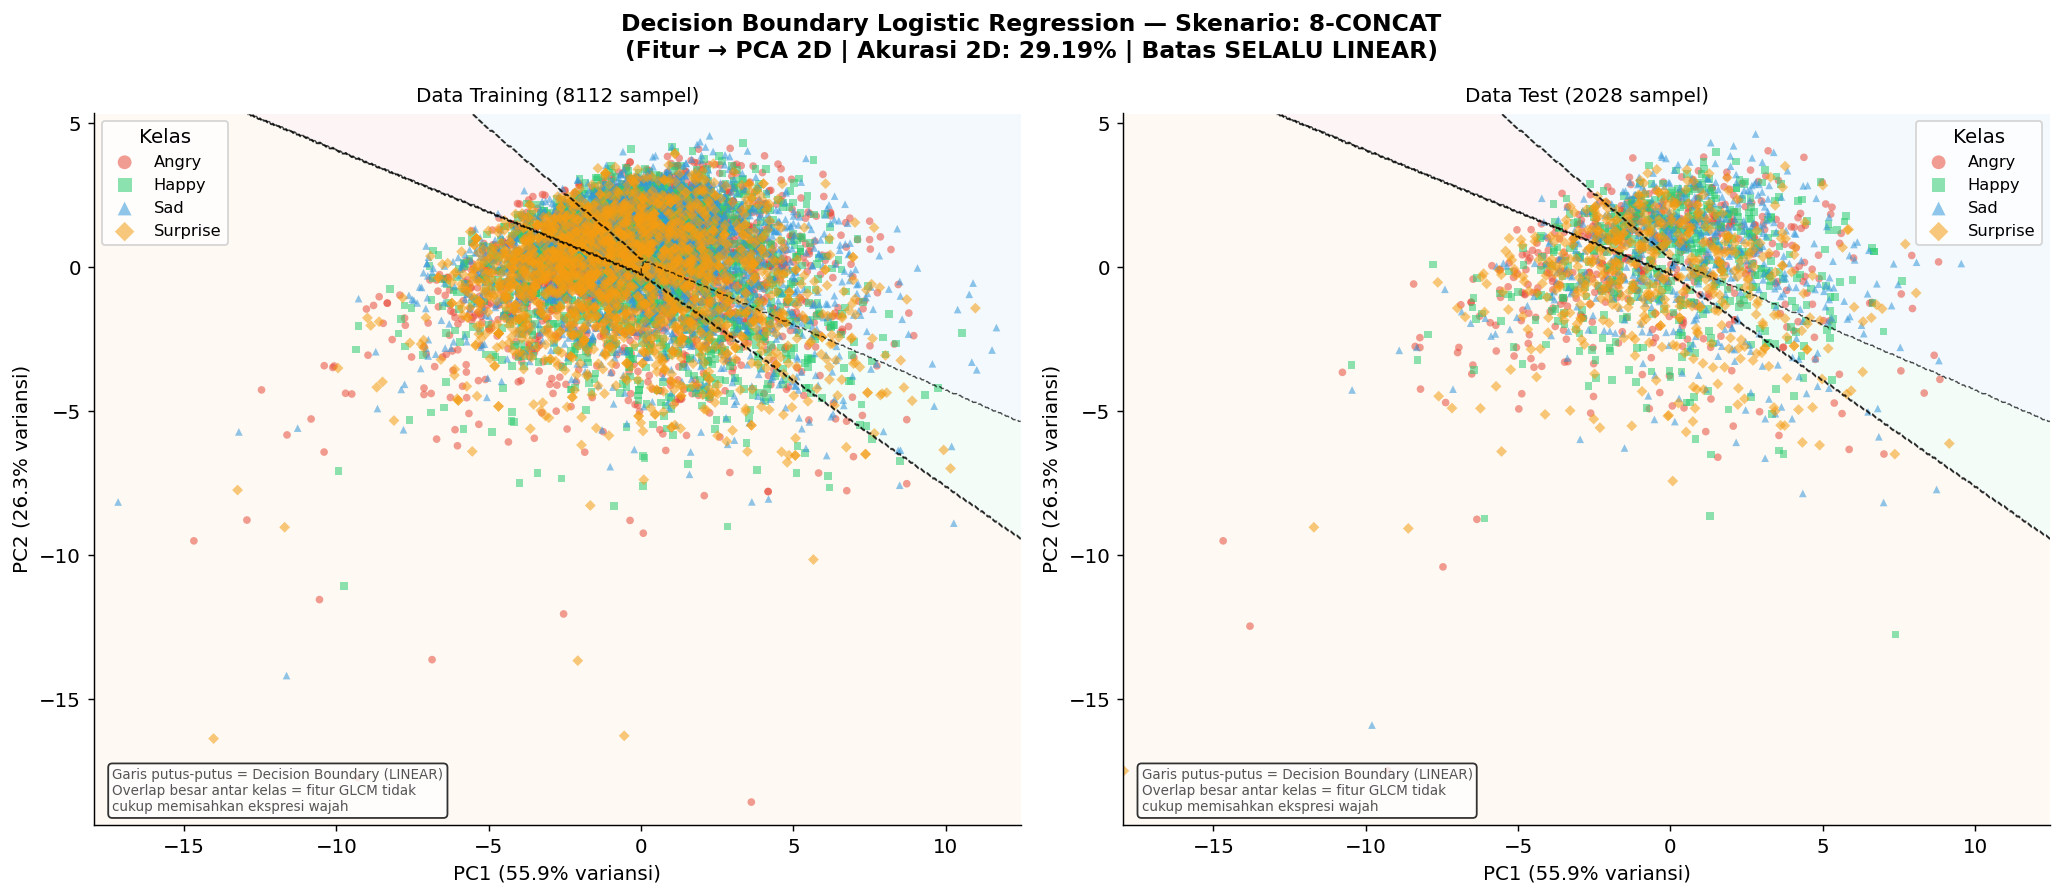

Disimpan: outputs\figures\10_decision_boundary.png


In [52]:
#  CELL 3.3 — Decision Boundary (PCA 2D) + Gradien Softmax

pca_2d  = PCA(n_components=2, random_state=RANDOM_STATE)
X_tr_2d = pca_2d.fit_transform(X_tr_best)
X_te_2d = pca_2d.transform(X_te_best)

lr_2d   = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_2d.fit(X_tr_2d, y_train)
acc_2d  = accuracy_score(y_test, lr_2d.predict(X_te_2d))

margin = 0.8
x_min, x_max = X_tr_2d[:,0].min()-margin, X_tr_2d[:,0].max()+margin
y_min, y_max = X_tr_2d[:,1].min()-margin, X_tr_2d[:,1].max()+margin
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.06),
                     np.arange(y_min, y_max, 0.06))
Z = lr_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

region_colors = ['#fadbd8', '#d5f5e3', '#d6eaf8', '#fdebd0']
cmap_region   = LinearSegmentedColormap.from_list('reg', region_colors, N=4)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(
    f'Decision Boundary Logistic Regression — Skenario: {best_key.upper()}\n'
    f'(Fitur → PCA 2D | Akurasi 2D: {acc_2d:.2%} | Batas SELALU LINEAR)',
    fontsize=13, fontweight='bold'
)

markers = ['o', 's', '^', 'D']
for ax, (X_2d, y_true, title) in zip(axes, [
    (X_tr_2d, y_train, f'Data Training ({len(y_train)} sampel)'),
    (X_te_2d, y_test,  f'Data Test ({len(y_test)} sampel)')
]):
    ax.contourf(xx, yy, Z, alpha=0.25, cmap=cmap_region,
                levels=[-0.5, 0.5, 1.5, 2.5, 3.5])
    ax.contour(xx, yy, Z, colors='black', linewidths=0.8,
               linestyles='--', levels=[-0.5, 0.5, 1.5, 2.5, 3.5], alpha=0.7)

    for cls_idx, (cls, color, marker) in enumerate(zip(le.classes_, COLORS, markers)):
        mask = y_true == cls_idx
        ax.scatter(X_2d[mask,0], X_2d[mask,1], c=color, marker=marker,
                   s=18, alpha=0.55, label=cls.capitalize(), edgecolors='none')

    ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)
    ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variansi)')
    ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variansi)')
    ax.set_title(title, fontsize=11)
    ax.legend(title='Kelas', fontsize=9, markerscale=1.8)
    ax.text(0.02, 0.02,
            'Garis putus-putus = Decision Boundary (LINEAR)\n'
            'Overlap besar antar kelas = fitur GLCM tidak\n'
            'cukup memisahkan ekspresi wajah',
            transform=ax.transAxes, fontsize=7.5, color='#555',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(str(OUT_FIGS / '10_decision_boundary.png'), bbox_inches='tight', dpi=150)
plt.show()
print("Disimpan:", OUT_FIGS / '10_decision_boundary.png')


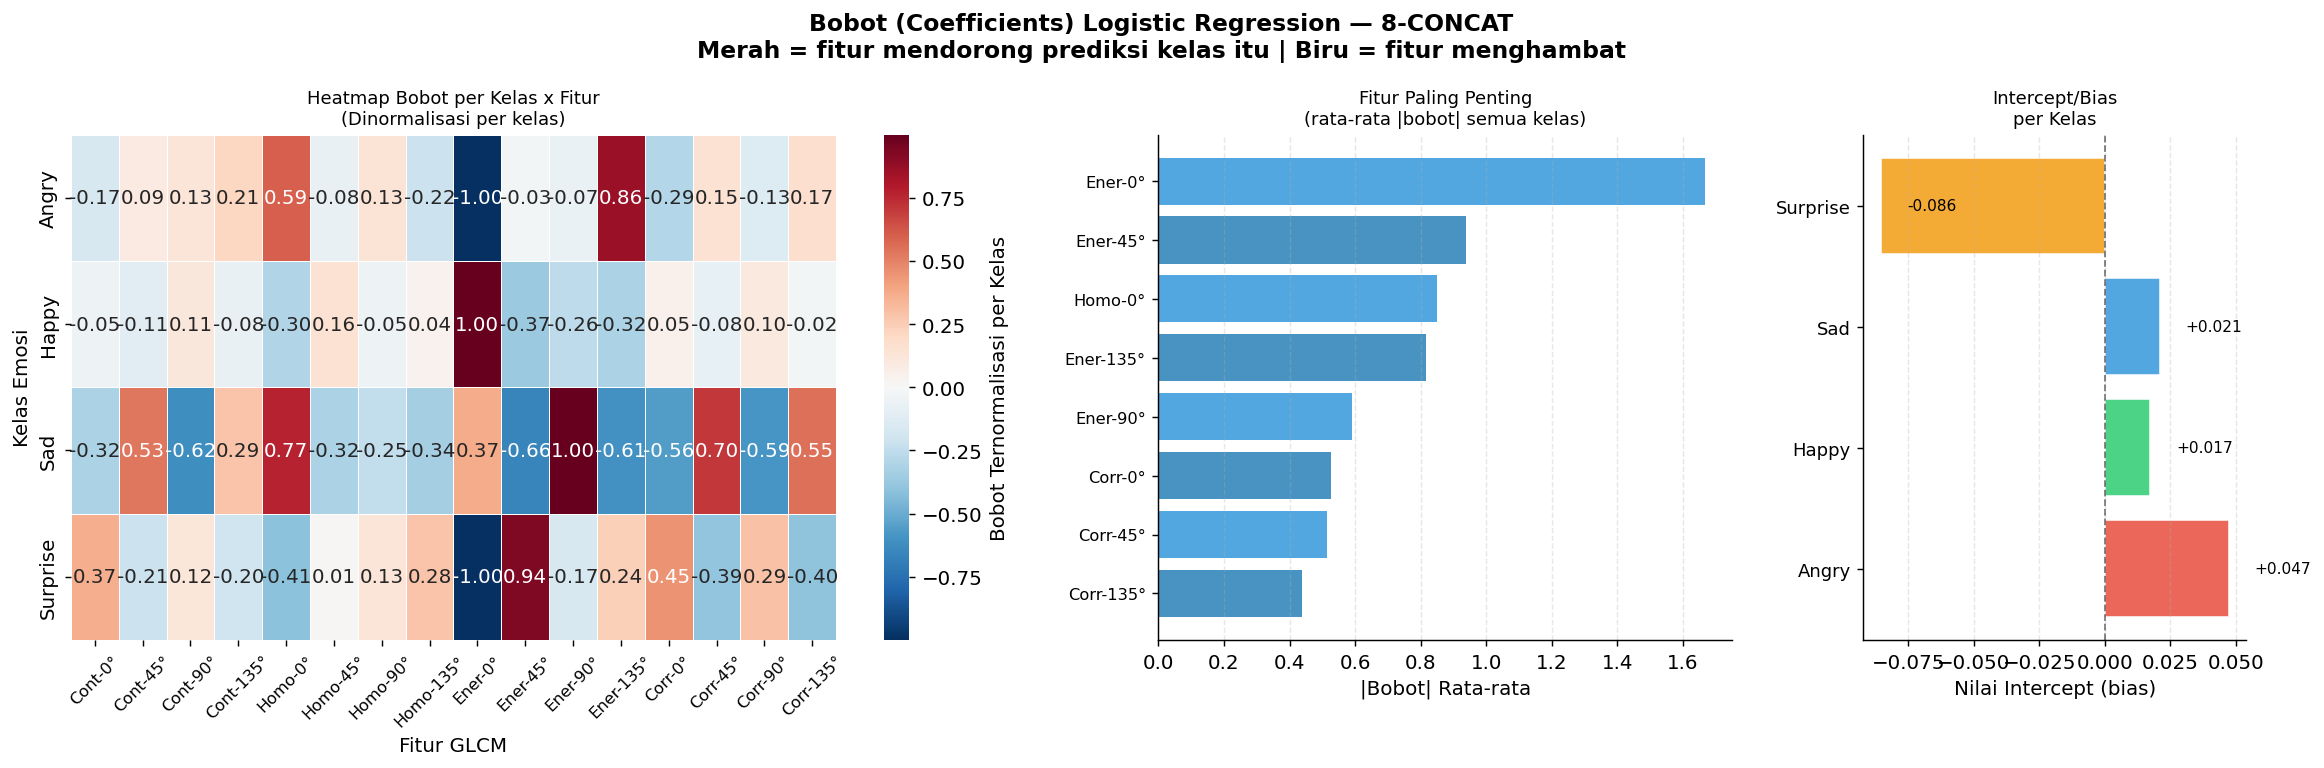

Disimpan: outputs\figures\11_model_coefficients.png


In [53]:
#  CELL 3.4 — Heatmap Bobot Model (Coefficient Matrix)

coef_matrix = best_model.coef_    # (4, n_feat)
level_k, agg_k = best_key.split('-')

if agg_k == 'mean':
    feat_names = [p.capitalize() for p in GLCM_PROPS]
else:
    feat_names = [f'{p[:4].capitalize()}-{a}' for p in GLCM_PROPS for a in ANGLE_LABELS]

class_names_cap = [c.capitalize() for c in le.classes_]

fig, axes = plt.subplots(1, 3, figsize=(18, 6),
                          gridspec_kw={'width_ratios': [2.5, 1.5, 1]})
fig.suptitle(
    f'Bobot (Coefficients) Logistic Regression — {best_key.upper()}\n'
    'Merah = fitur mendorong prediksi kelas itu | Biru = fitur menghambat',
    fontsize=13, fontweight='bold'
)

# Panel 1: Heatmap bobot per kelas
ax = axes[0]
coef_norm = coef_matrix / (np.abs(coef_matrix).max(axis=1, keepdims=True) + 1e-8)
sns.heatmap(
    coef_norm, ax=ax, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0,
    xticklabels=feat_names, yticklabels=class_names_cap,
    linewidths=0.4, cbar_kws={'label': 'Bobot Ternormalisasi per Kelas'}
)
ax.set_title('Heatmap Bobot per Kelas x Fitur\n(Dinormalisasi per kelas)', fontsize=10)
ax.set_xlabel('Fitur GLCM'); ax.set_ylabel('Kelas Emosi')
ax.tick_params(axis='x', rotation=45, labelsize=9)

# Panel 2: Bar bobot absolut (fitur penting) 
ax = axes[1]
abs_mean_coef = np.abs(coef_matrix).mean(axis=0)
sorted_idx    = np.argsort(abs_mean_coef)[::-1]
top_n = min(8, len(abs_mean_coef))
colors_bar = ['#3498db' if i%2==0 else '#2980b9' for i in range(top_n)]
ax.barh(range(top_n), abs_mean_coef[sorted_idx[:top_n]],
        color=colors_bar, alpha=0.85)
ax.set_yticks(range(top_n))
ax.set_yticklabels([feat_names[i] for i in sorted_idx[:top_n]], fontsize=9)
ax.set_xlabel('|Bobot| Rata-rata')
ax.set_title('Fitur Paling Penting\n(rata-rata |bobot| semua kelas)', fontsize=10)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3, ls='--')

# Panel 3: Intercept (bias) per kelas
ax = axes[2]
intercepts = best_model.intercept_
bars = ax.barh(range(len(le.classes_)), intercepts,
               color=COLORS, alpha=0.85, edgecolor='white')
ax.set_yticks(range(len(le.classes_)))
ax.set_yticklabels(class_names_cap, fontsize=10)
ax.set_xlabel('Nilai Intercept (bias)')
ax.set_title('Intercept/Bias\nper Kelas', fontsize=10)
ax.axvline(0, color='black', lw=1, ls='--', alpha=0.5)
ax.grid(axis='x', alpha=0.3, ls='--')
for bar, val in zip(bars, intercepts):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center', fontsize=8.5)

plt.tight_layout()
plt.savefig(str(OUT_FIGS / '11_model_coefficients.png'), bbox_inches='tight', dpi=150)
plt.show()
print("Disimpan:", OUT_FIGS / '11_model_coefficients.png')


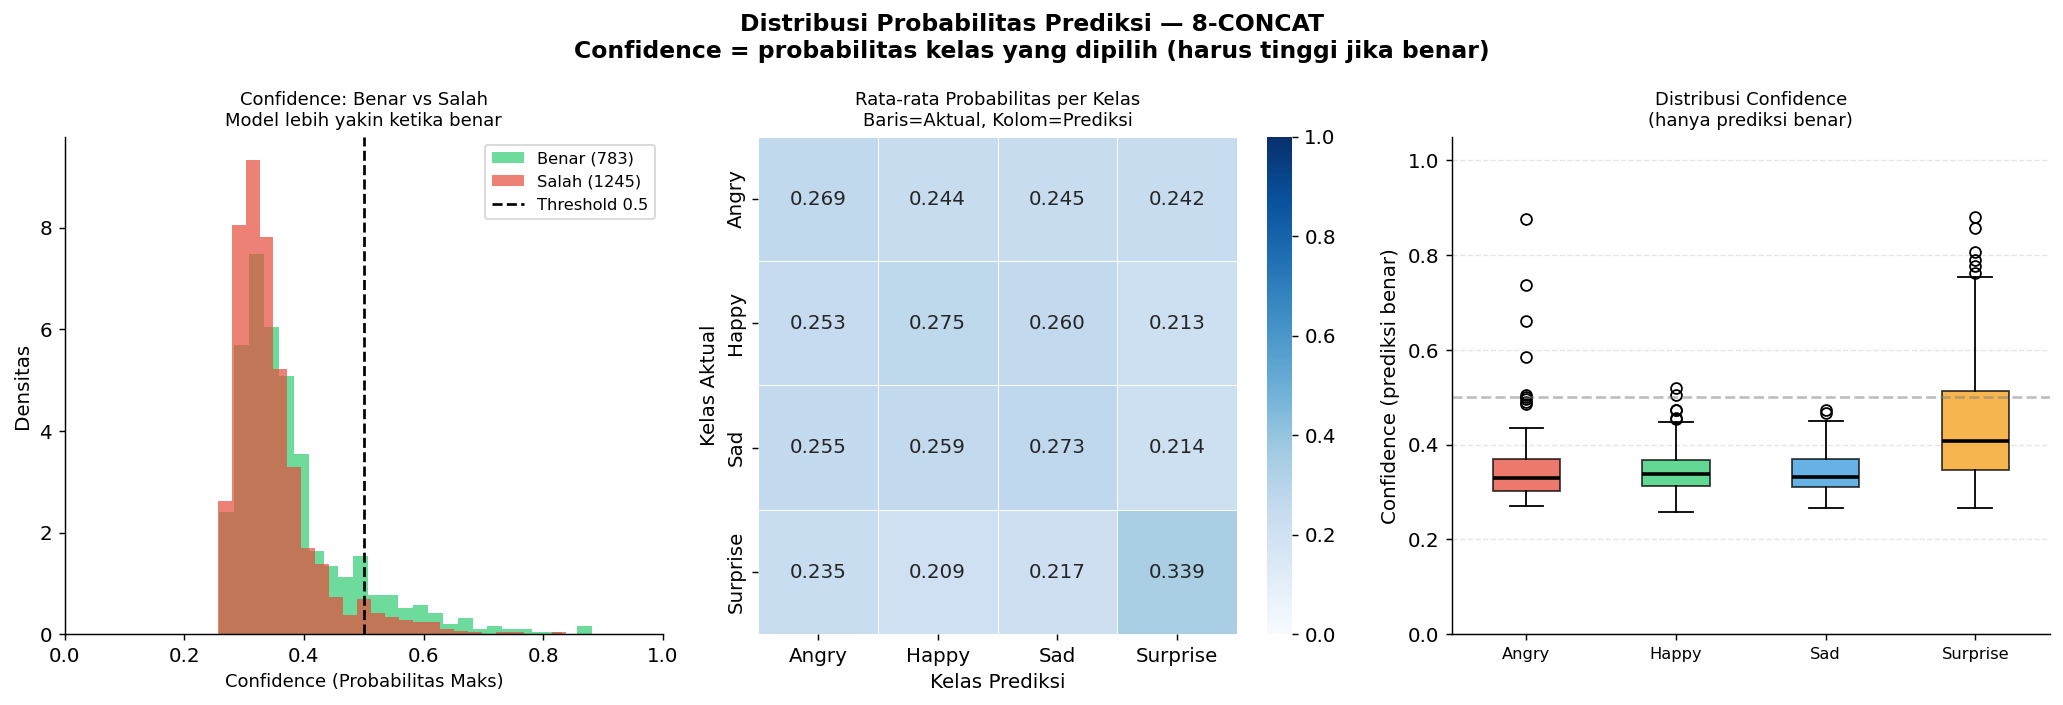

Disimpan: outputs\figures\12_prediction_probability.png


In [54]:
#  CELL 3.5 — Distribusi Probabilitas Prediksi

proba_all  = best_model.predict_proba(X_te_best)
is_correct = (results[best_key]['y_pred_test'] == y_test)
max_proba  = proba_all.max(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
fig.suptitle(
    f'Distribusi Probabilitas Prediksi — {best_key.upper()}\n'
    'Confidence = probabilitas kelas yang dipilih (harus tinggi jika benar)',
    fontsize=13, fontweight='bold'
)

# Panel 1: Distribusi confidence benar vs salah
ax = axes[0]
ax.hist(max_proba[is_correct],  bins=25, color='#2ecc71', alpha=0.7,
        label=f'Benar ({is_correct.sum()})', density=True)
ax.hist(max_proba[~is_correct], bins=25, color='#e74c3c', alpha=0.7,
        label=f'Salah ({(~is_correct).sum()})', density=True)
ax.axvline(0.5, color='black', lw=1.5, ls='--', label='Threshold 0.5')
ax.set_xlabel('Confidence (Probabilitas Maks)', fontsize=10)
ax.set_ylabel('Densitas'); ax.set_xlim(0, 1)
ax.set_title('Confidence: Benar vs Salah\nModel lebih yakin ketika benar', fontsize=10)
ax.legend(fontsize=9)

# Panel 2: Heatmap rata-rata prob per kelas asli
ax = axes[1]
avg_prob = np.zeros((len(le.classes_), len(le.classes_)))
for true_idx in range(len(le.classes_)):
    mask = y_test == true_idx
    if mask.sum() > 0:
        avg_prob[true_idx] = proba_all[mask].mean(axis=0)
sns.heatmap(avg_prob, ax=ax, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=class_names_cap, yticklabels=class_names_cap,
            vmin=0, vmax=1, linewidths=0.5)
ax.set_title('Rata-rata Probabilitas per Kelas\nBaris=Aktual, Kolom=Prediksi', fontsize=10)
ax.set_xlabel('Kelas Prediksi'); ax.set_ylabel('Kelas Aktual')

# Panel 3: Boxplot confidence per kelas (hanya prediksi benar)
ax = axes[2]
conf_per_cls = [max_proba[(y_test == k) & is_correct]
                for k in range(len(le.classes_))]
bp = ax.boxplot(conf_per_cls, patch_artist=True,
                medianprops={'color': 'black', 'lw': 2})
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax.set_xticklabels(class_names_cap, fontsize=9)
ax.set_ylabel('Confidence (prediksi benar)')
ax.set_ylim(0, 1.05); ax.axhline(0.5, color='gray', ls='--', alpha=0.5)
ax.set_title('Distribusi Confidence\n(hanya prediksi benar)', fontsize=10)
ax.grid(axis='y', alpha=0.3, ls='--')

plt.tight_layout()
plt.savefig(str(OUT_FIGS / '12_prediction_probability.png'), bbox_inches='tight', dpi=150)
plt.show()
print("Disimpan:", OUT_FIGS / '12_prediction_probability.png')


---
# BAGIAN 4 — Evaluasi Lengkap

In [55]:
#  CELL 4.1 — Classification Report
y_pred_best = results[best_key]['y_pred_test']

print(f"{'='*62}")
print(f"CLASSIFICATION REPORT — Skenario: {best_key.upper()}")
print(f"{'='*62}")
print(classification_report(y_test, y_pred_best, target_names=class_names_cap))


CLASSIFICATION REPORT — Skenario: 8-CONCAT
              precision    recall  f1-score   support

       Angry       0.34      0.24      0.28       507
       Happy       0.36      0.36      0.36       507
         Sad       0.35      0.36      0.35       507
    Surprise       0.46      0.59      0.52       507

    accuracy                           0.39      2028
   macro avg       0.38      0.39      0.38      2028
weighted avg       0.38      0.39      0.38      2028



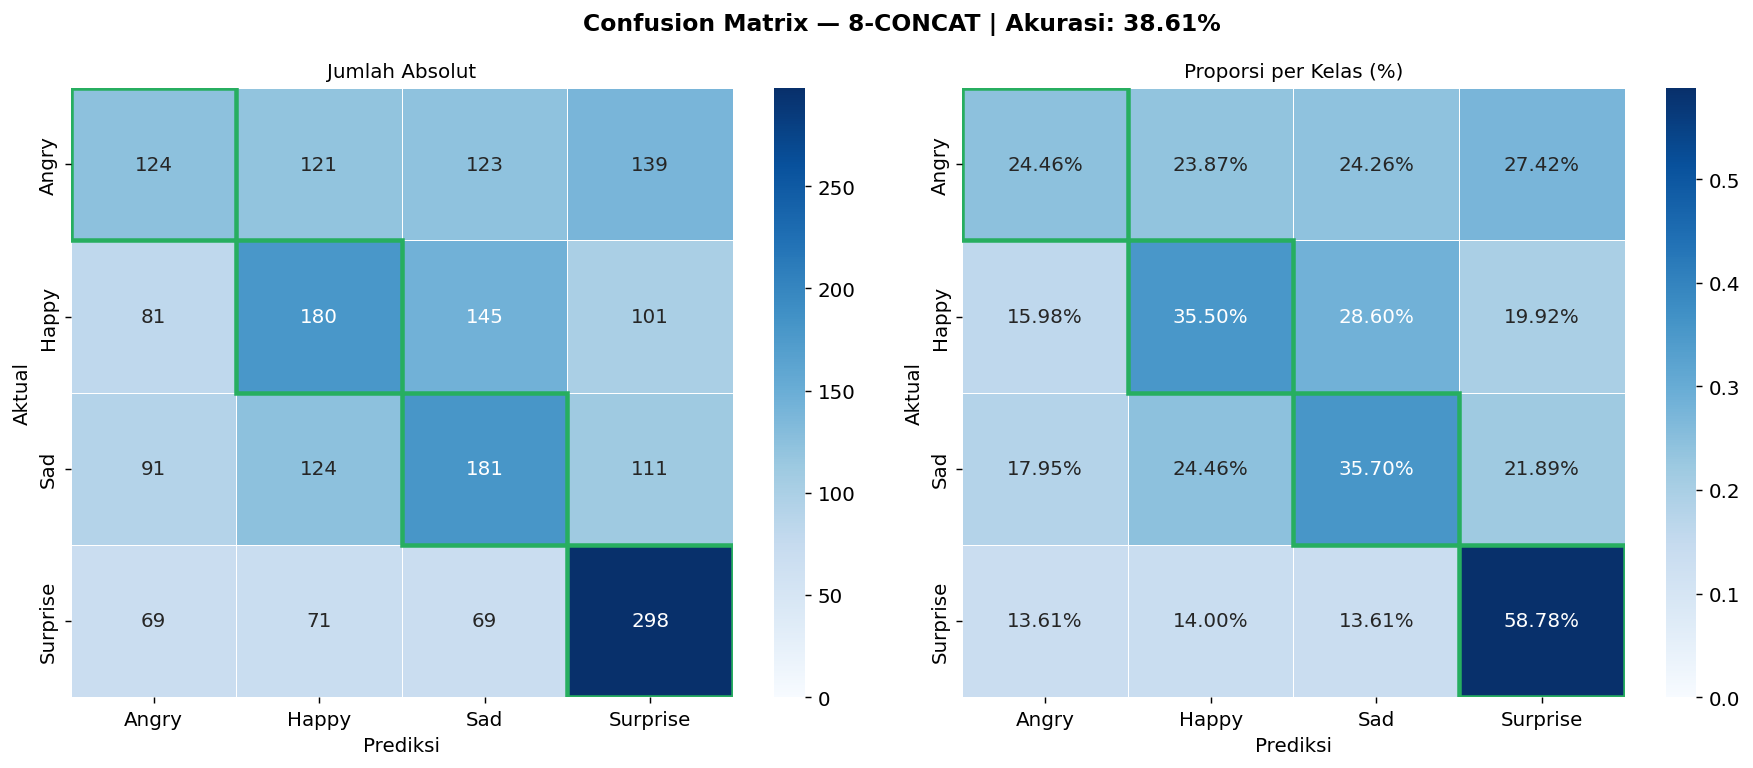

Disimpan: outputs\figures\13_confusion_matrix.png


In [56]:
#  CELL 4.2 — Confusion Matrix (Absolut + Normalized)
cm      = confusion_matrix(y_test, y_pred_best)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'Confusion Matrix — {best_key.upper()} | Akurasi: {best_acc:.2%}',
             fontsize=13, fontweight='bold')

for ax, (data, fmt, title, cmap) in zip(axes, [
    (cm,      'd',    'Jumlah Absolut',         'Blues'),
    (cm_norm, '.2%',  'Proporsi per Kelas (%)', 'Blues'),
]):
    sns.heatmap(data, ax=ax, annot=True, fmt=fmt, cmap=cmap,
                xticklabels=class_names_cap, yticklabels=class_names_cap,
                linewidths=0.5, linecolor='white', vmin=0)
    # Highlight diagonal
    for i in range(len(le.classes_)):
        ax.add_patch(mpatches.Rectangle((i, i), 1, 1, fill=False,
                                         edgecolor='#27ae60', lw=2.5))
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Prediksi', fontsize=11); ax.set_ylabel('Aktual', fontsize=11)

plt.tight_layout()
plt.savefig(str(OUT_FIGS / '13_confusion_matrix.png'), bbox_inches='tight', dpi=150)
plt.show()
print("Disimpan:", OUT_FIGS / '13_confusion_matrix.png')


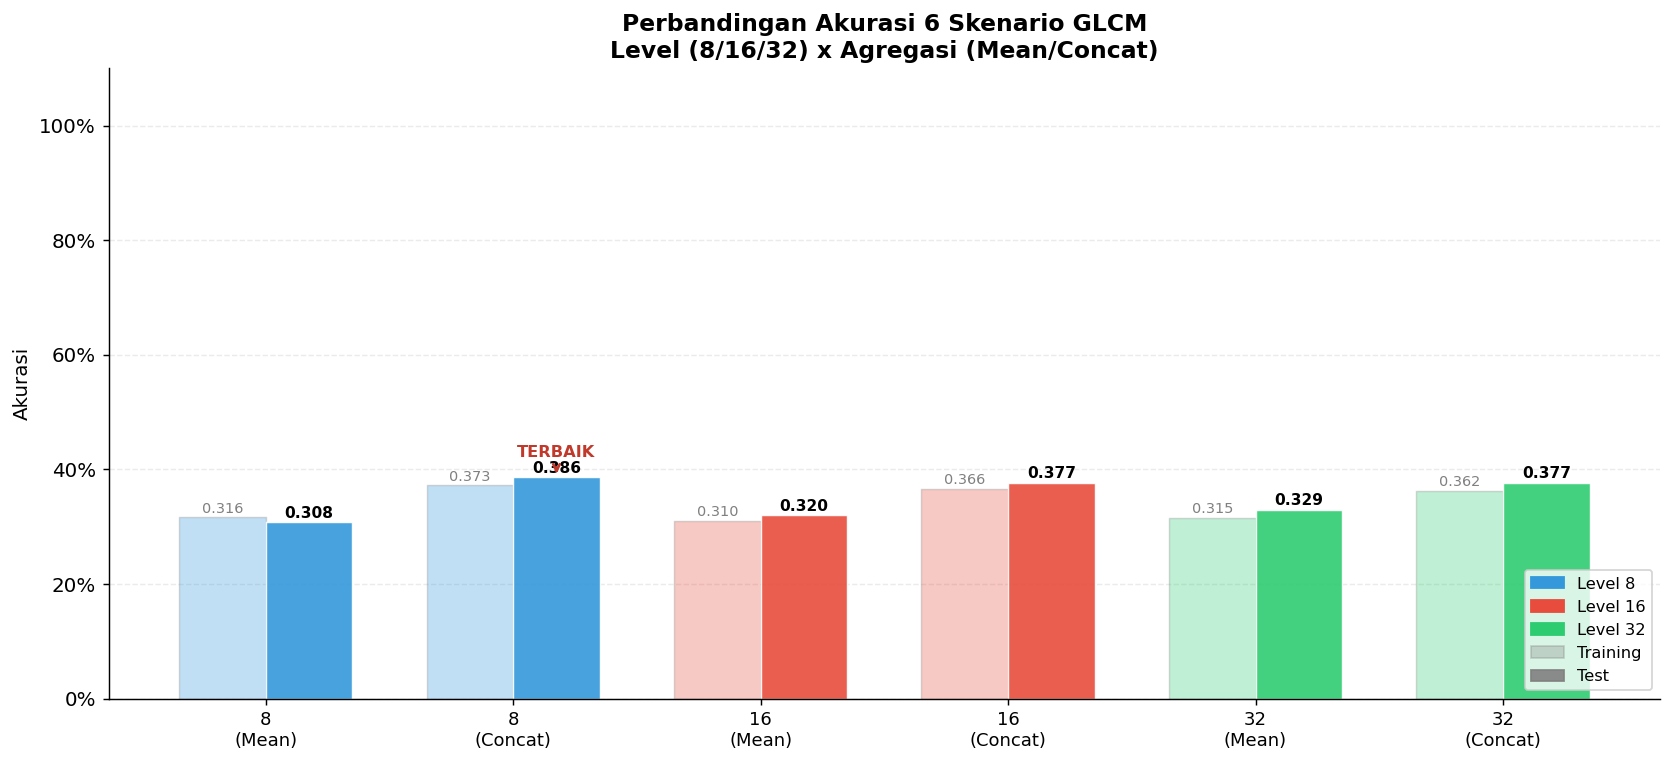

Disimpan: outputs\figures\14_accuracy_comparison.png


In [57]:
#  CELL 4.3 — Perbandingan 6 Skenario
keys      = list(results.keys())
acc_train = [results[k]['acc_train'] for k in keys]
acc_test  = [results[k]['acc_test']  for k in keys]
x = np.arange(len(keys)); w = 0.35

level_col_map = {'8': '#3498db', '16': '#e74c3c', '32': '#2ecc71'}
bar_colors = [level_col_map[k.split('-')[0]] for k in keys]

fig, ax = plt.subplots(figsize=(13, 6))
btr = ax.bar(x-w/2, acc_train, w, color=bar_colors, alpha=0.3,
             edgecolor='gray', lw=0.8, label='Training')
bte = ax.bar(x+w/2, acc_test,  w, color=bar_colors, alpha=0.9,
             edgecolor='white', lw=0.8, label='Test')

for bar, val in zip(btr, acc_train):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.003,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8, color='gray')
for bar, val in zip(bte, acc_test):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.003,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

best_idx = keys.index(best_key)
ax.annotate('TERBAIK',
            xy=(x[best_idx]+w/2, acc_test[best_idx]),
            xytext=(x[best_idx]+w/2, acc_test[best_idx]+0.035),
            fontsize=9, ha='center', color='#c0392b', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.5))

ax.set_xticks(x)
ax.set_xticklabels(
    [k.replace('-mean','\n(Mean)').replace('-concat','\n(Concat)') for k in keys],
    fontsize=10
)
ax.set_ylabel('Akurasi'); ax.set_ylim(0, 1.1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.set_title('Perbandingan Akurasi 6 Skenario GLCM\n'
             'Level (8/16/32) x Agregasi (Mean/Concat)',
             fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.25, ls='--'); ax.set_axisbelow(True)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#3498db', label='Level 8'),
    Patch(color='#e74c3c', label='Level 16'),
    Patch(color='#2ecc71', label='Level 32'),
    Patch(color='gray', alpha=0.3, label='Training'),
    Patch(color='gray', alpha=0.9, label='Test'),
], fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig(str(OUT_FIGS / '14_accuracy_comparison.png'), bbox_inches='tight', dpi=150)
plt.show()
print("Disimpan:", OUT_FIGS / '14_accuracy_comparison.png')


PCA... Explained var: 82.2%
t-SNE (non-linear)... 


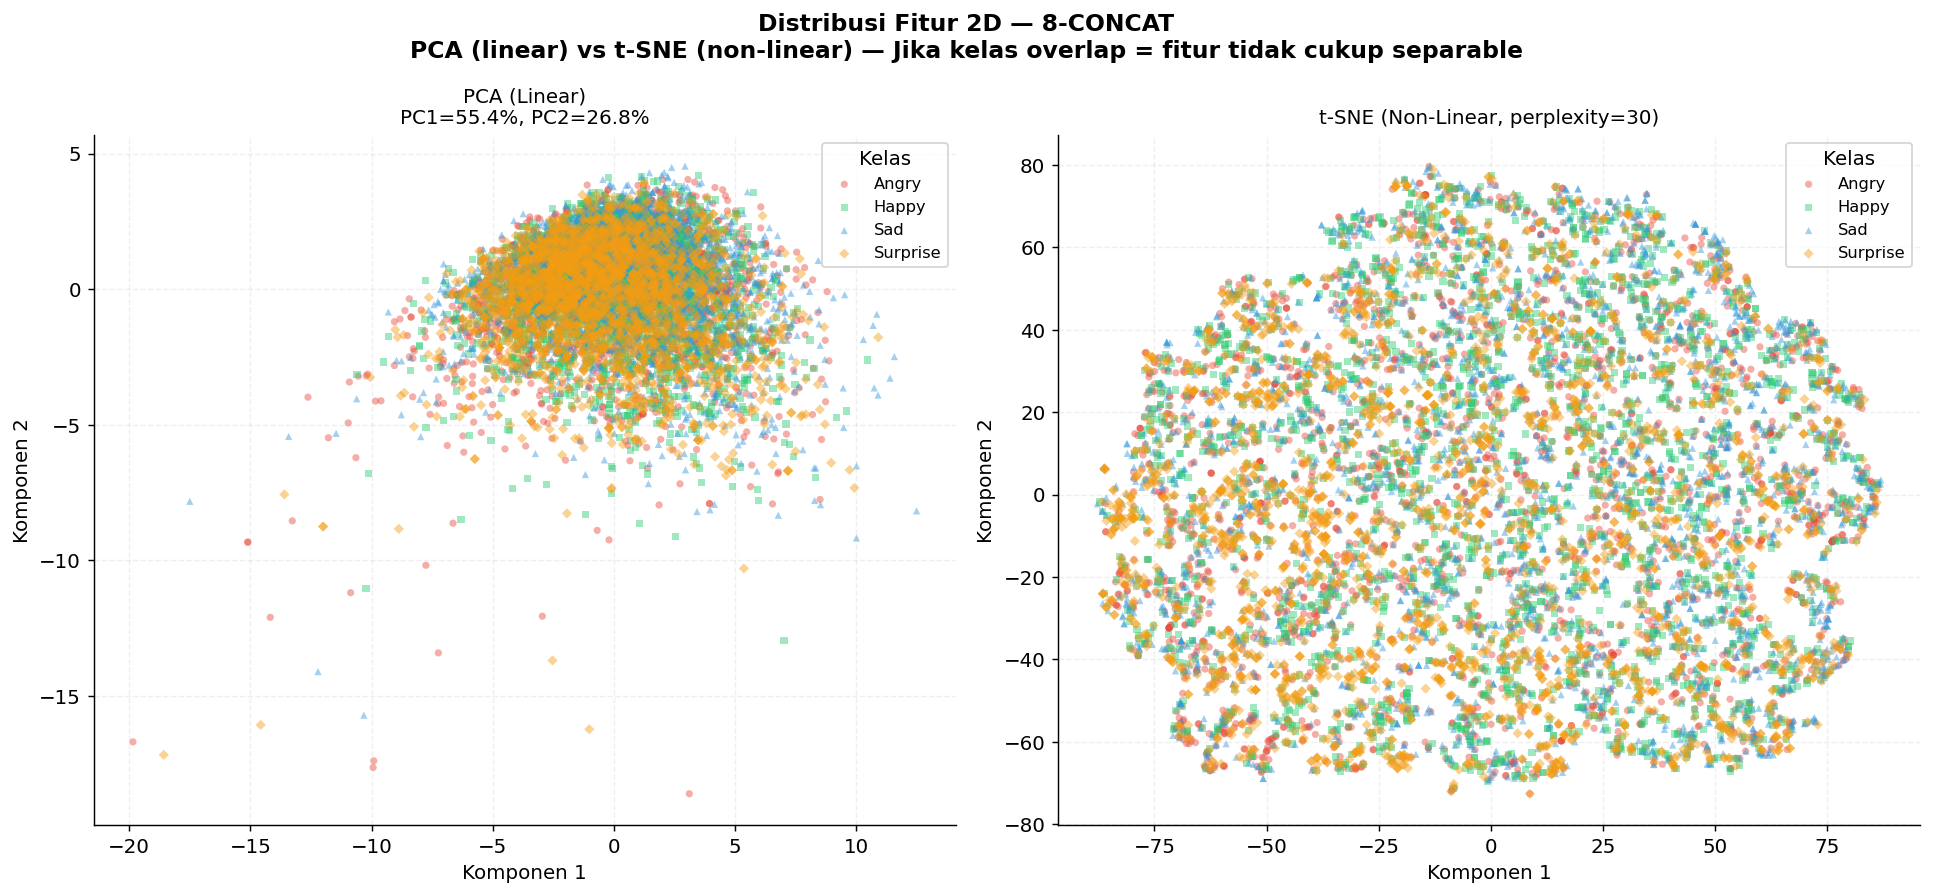

Disimpan: outputs\figures\15_pca_tsne.png


In [58]:
#  CELL 4.4 — PCA & t-SNE Distribusi Fitur 2D
X_all = np.vstack([X_tr_best, X_te_best])
y_all = np.concatenate([y_train, y_test])

print("PCA...", end=' ')
pca_full = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca    = pca_full.fit_transform(X_all)
print(f"Explained var: {pca_full.explained_variance_ratio_.sum():.1%}")

print("t-SNE (non-linear)...", end=' ')
tsne   = TSNE(n_components=2, perplexity=30, learning_rate='auto', random_state=RANDOM_STATE)
X_tsne = tsne.fit_transform(X_all)
print("")

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle(
    f'Distribusi Fitur 2D — {best_key.upper()}\n'
    'PCA (linear) vs t-SNE (non-linear) — Jika kelas overlap = fitur tidak cukup separable',
    fontsize=13, fontweight='bold'
)
markers = ['o', 's', '^', 'D']
for ax, (X_2d, title) in zip(axes, [
    (X_pca,
     f'PCA (Linear)\nPC1={pca_full.explained_variance_ratio_[0]:.1%}, PC2={pca_full.explained_variance_ratio_[1]:.1%}'),
    (X_tsne, 't-SNE (Non-Linear, perplexity=30)')
]):
    for cls_idx, (cls, color, marker) in enumerate(zip(le.classes_, COLORS, markers)):
        mask = y_all == cls_idx
        ax.scatter(X_2d[mask,0], X_2d[mask,1], c=color, marker=marker,
                   label=cls.capitalize(), alpha=0.45, s=16, edgecolors='none')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Komponen 1'); ax.set_ylabel('Komponen 2')
    ax.legend(title='Kelas', fontsize=9)
    ax.grid(True, alpha=0.2, ls='--')

plt.tight_layout()
plt.savefig(str(OUT_FIGS / '15_pca_tsne.png'), bbox_inches='tight', dpi=150)
plt.show()
print("Disimpan:", OUT_FIGS / '15_pca_tsne.png')


Total kesalahan: 1245/2028 (61.4%)


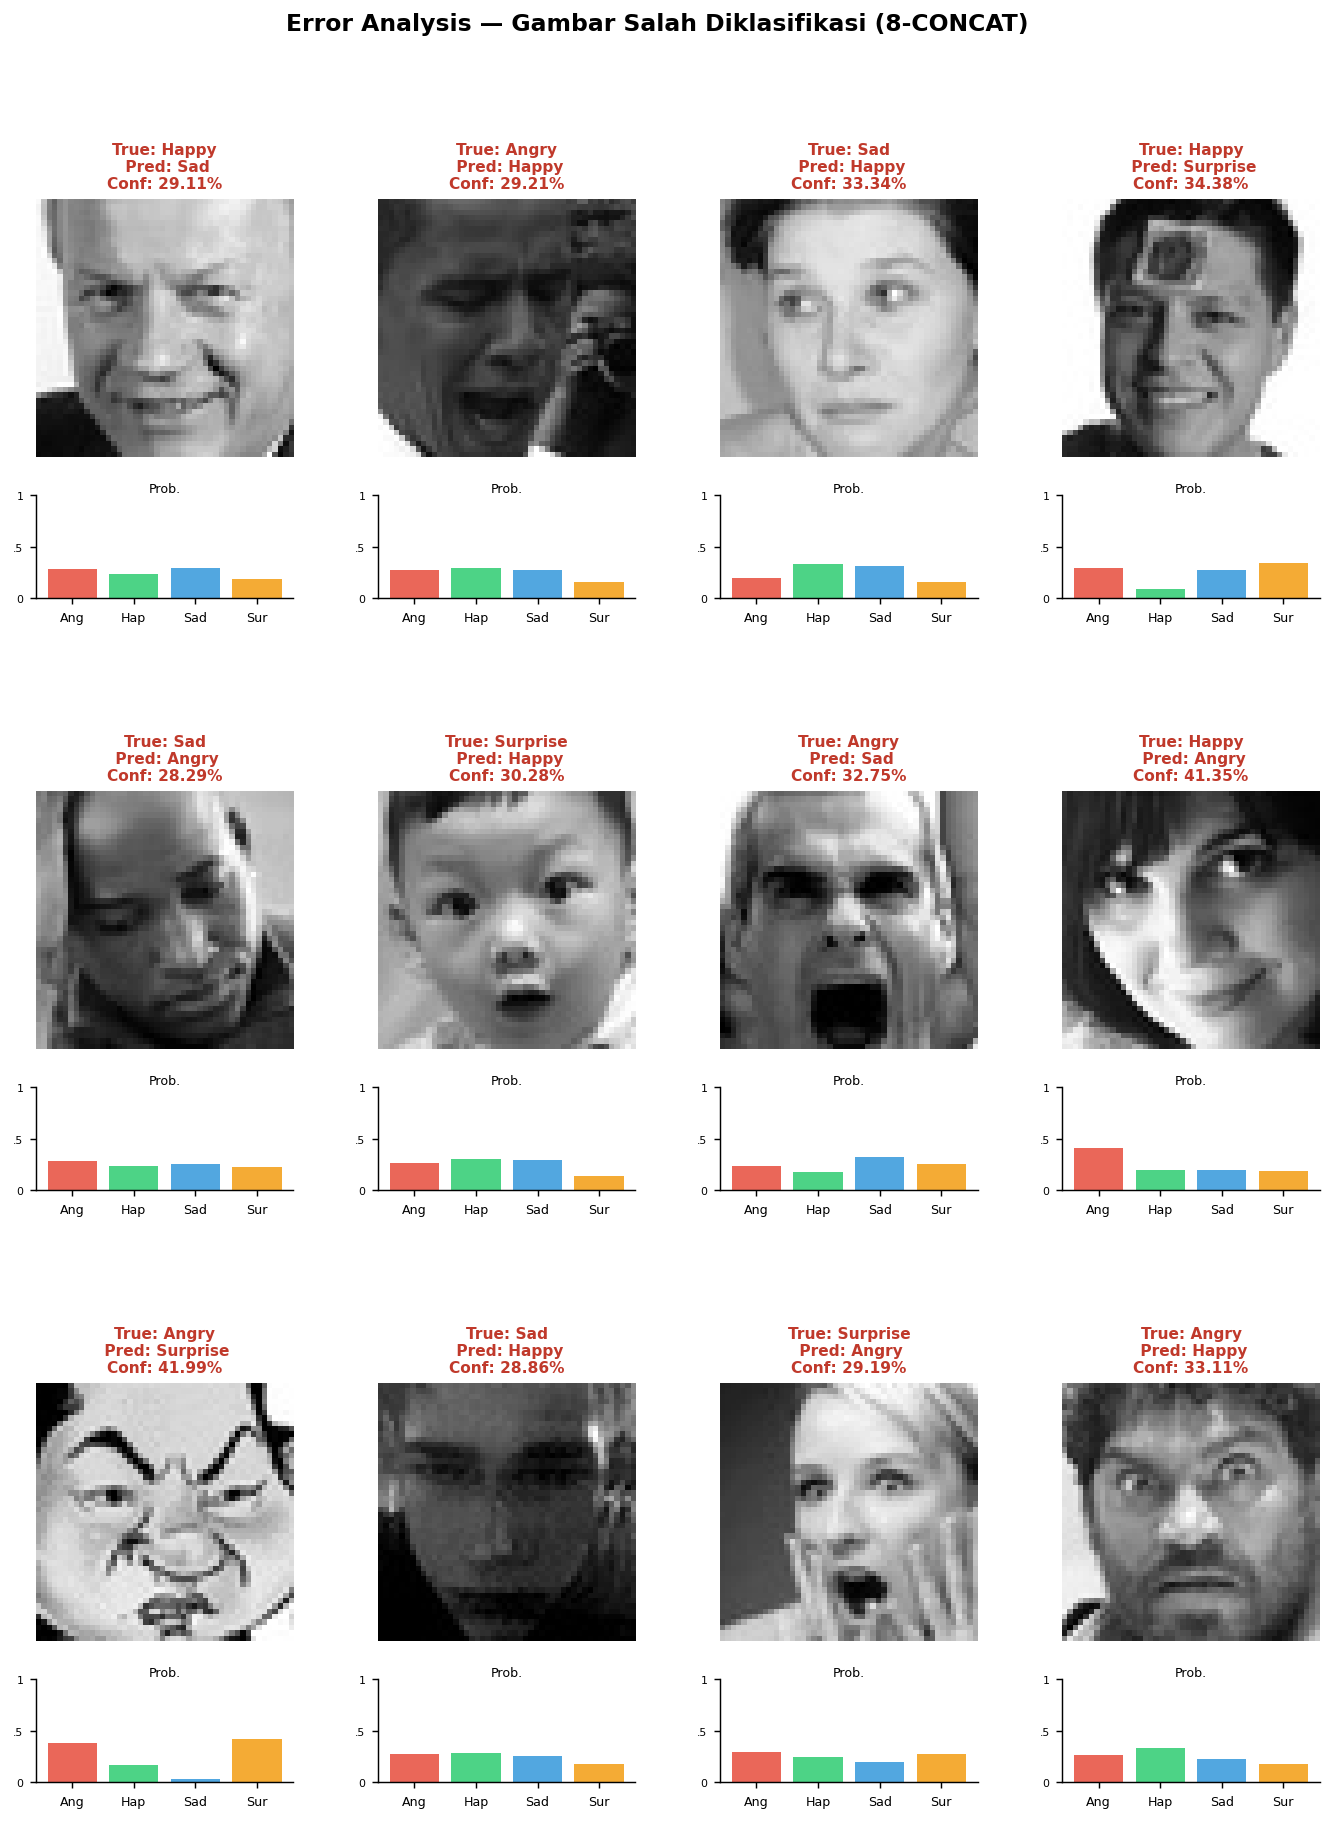

Disimpan: outputs\figures\16_error_analysis.png


In [59]:
#  CELL 4.5 — Error Analysis: Gambar Salah Klasifikasi
wrong_idx = np.where(y_test != y_pred_best)[0]
print(f"Total kesalahan: {len(wrong_idx)}/{len(y_test)} ({len(wrong_idx)/len(y_test):.1%})")

rng    = np.random.default_rng(RANDOM_STATE)
n_show = min(12, len(wrong_idx))
sampled= rng.choice(wrong_idx, size=n_show, replace=False)

n_cols = 4; n_rows = int(np.ceil(n_show / n_cols))

# PERBAIKAN: figsize dan hspace diperbesar
fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(n_cols*3.2, n_rows*4.8),
                          gridspec_kw={'hspace': 1.3, 'wspace': 0.3})

fig.suptitle(f'Error Analysis — Gambar Salah Diklasifikasi ({best_key.upper()})',
             fontsize=13, fontweight='bold')

for plot_idx, test_idx in enumerate(sampled):
    ax          = axes.flatten()[plot_idx]
    true_label  = le.inverse_transform([y_test[test_idx]])[0].capitalize()
    pred_label  = le.inverse_transform([y_pred_best[test_idx]])[0].capitalize()
    proba_img   = proba_all[test_idx]
    conf        = proba_img.max()

    ax.imshow(test_raw[test_idx], cmap='gray')
    ax.set_title(f'True: {true_label}\n Pred: {pred_label}\nConf: {conf:.2%}',
                 fontsize=8.5, color='#c0392b', fontweight='bold')

    # PERBAIKAN: Posisi inset disesuaikan
    ax_inset = ax.inset_axes([0, -0.55, 1, 0.4])
    ax_inset.bar(range(4), proba_img, color=COLORS, alpha=0.85)
    ax_inset.set_xticks(range(4))
    ax_inset.set_xticklabels([c[:3].capitalize() for c in le.classes_], fontsize=7)
    ax_inset.set_ylim(0, 1); ax_inset.set_yticks([0, 0.5, 1])
    ax_inset.set_yticklabels(['0', '.5', '1'], fontsize=6)
    ax_inset.set_title('Prob.', fontsize=7, pad=1)
    ax_inset.spines['top'].set_visible(False)
    ax_inset.spines['right'].set_visible(False)

    ax.axis('off')
    for sp in ax.spines.values():
        sp.set_visible(True); sp.set_edgecolor('#e74c3c'); sp.set_linewidth(2)

for idx in range(n_show, n_rows*n_cols):
    axes.flatten()[idx].axis('off')

plt.savefig(str(OUT_FIGS / '16_error_analysis.png'), bbox_inches='tight', dpi=150)
plt.show()
print("Disimpan:", OUT_FIGS / '16_error_analysis.png')

---
# BAGIAN 5 — Analisis Wajib (Jawaban 5 Pertanyaan Tugas)

Bagian ini menjawab semua **pertanyaan analisis wajib** dari spesifikasi tugas  
dengan dukungan visualisasi dan angka dari hasil eksperimen.


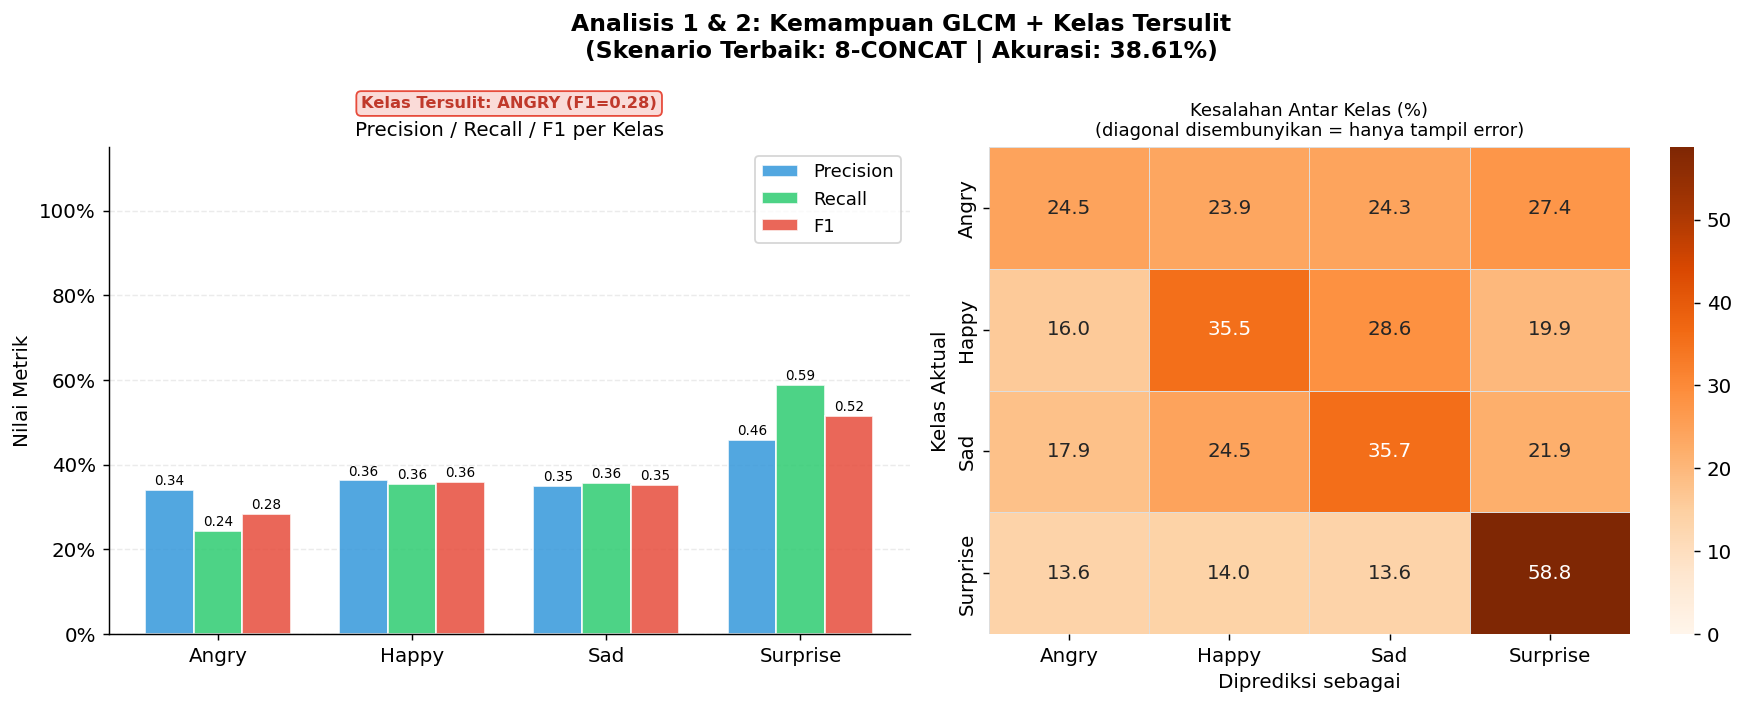


JAWABAN ANALISIS 1:
   Akurasi terbaik GLCM+LR : 38.61%
   → GLCM TIDAK cukup untuk memisahkan emosi wajah secara akurat.
     Fitur tekstur tidak menangkap informasi geometri/bentuk wajah.

JAWABAN ANALISIS 2:
   angry     : F1=0.2844
   happy     : F1=0.3589
   sad       : F1=0.3532
   surprise  : F1=0.5156
   → Kelas tersulit: ANGRY (F1 terendah)
Disimpan: outputs\figures\17_analisis_1_2_glcm_dan_kelas_tersulit.png


In [60]:
#  CELL 5.1 — Analisis 1 & 2: Apakah GLCM Cukup? Kelas Tersulit?

cr_dict = {}
from sklearn.metrics import precision_recall_fscore_support
prec, rec, f1, supp = precision_recall_fscore_support(
    y_test, y_pred_best, labels=list(range(len(le.classes_)))
)

for i, cls in enumerate(le.classes_):
    cr_dict[cls] = {'precision': prec[i], 'recall': rec[i],
                    'f1': f1[i], 'support': supp[i]}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle(
    'Analisis 1 & 2: Kemampuan GLCM + Kelas Tersulit\n'
    f'(Skenario Terbaik: {best_key.upper()} | Akurasi: {best_acc:.2%})',
    fontsize=13, fontweight='bold'
)

# Panel 1: Precision/Recall/F1 per kelas 
ax = axes[0]
x  = np.arange(len(CLASSES)); w = 0.25
metrics = ['precision', 'recall', 'f1']
metric_colors = ['#3498db', '#2ecc71', '#e74c3c']
for i, (metric, mc) in enumerate(zip(metrics, metric_colors)):
    vals = [cr_dict[cls][metric] for cls in CLASSES]
    bars = ax.bar(x + (i-1)*w, vals, w,
                  label=metric.capitalize(), color=mc, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.005,
                f'{v:.2f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x); ax.set_xticklabels([c.capitalize() for c in CLASSES], fontsize=11)
ax.set_ylim(0, 1.15); ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0%}'))
ax.set_ylabel('Nilai Metrik')
ax.set_title('Precision / Recall / F1 per Kelas', fontsize=11)
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.25, ls='--'); ax.set_axisbelow(True)

worst_cls = min(CLASSES, key=lambda c: cr_dict[c]['f1'])
ax.text(0.5, 1.08, f'Kelas Tersulit: {worst_cls.upper()} (F1={cr_dict[worst_cls]["f1"]:.2f})',
        transform=ax.transAxes, ha='center', fontsize=9, color='#c0392b',
        fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#fadbd8', edgecolor='#e74c3c'))

# Panel 2: Heatmap kesalahan (berapa % salah ke kelas mana) 
ax = axes[1]
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
mask_diag = np.eye(len(le.classes_), dtype=bool)
off_diag  = np.ma.array(cm_pct, mask=mask_diag)
sns.heatmap(off_diag, ax=ax, annot=True, fmt='.1f', cmap='Oranges',
            xticklabels=class_names_cap, yticklabels=class_names_cap,
            linewidths=0.5, linecolor='#ddd', vmin=0)
ax.set_title('Kesalahan Antar Kelas (%)\n(diagonal disembunyikan = hanya tampil error)',
             fontsize=10)
ax.set_xlabel('Diprediksi sebagai'); ax.set_ylabel('Kelas Aktual')

plt.tight_layout()
plt.savefig(str(OUT_FIGS / '17_analisis_1_2_glcm_dan_kelas_tersulit.png'),
            bbox_inches='tight', dpi=150)
plt.show()

print("\nJAWABAN ANALISIS 1:")
print(f"   Akurasi terbaik GLCM+LR : {best_acc:.2%}")
print(f"   → GLCM TIDAK cukup untuk memisahkan emosi wajah secara akurat.")
print(f"     Fitur tekstur tidak menangkap informasi geometri/bentuk wajah.")
print(f"\nJAWABAN ANALISIS 2:")
for cls in CLASSES:
    print(f"   {cls:10s}: F1={cr_dict[cls]['f1']:.4f}")
print(f"   → Kelas tersulit: {worst_cls.upper()} (F1 terendah)")
print("Disimpan:", OUT_FIGS / '17_analisis_1_2_glcm_dan_kelas_tersulit.png')


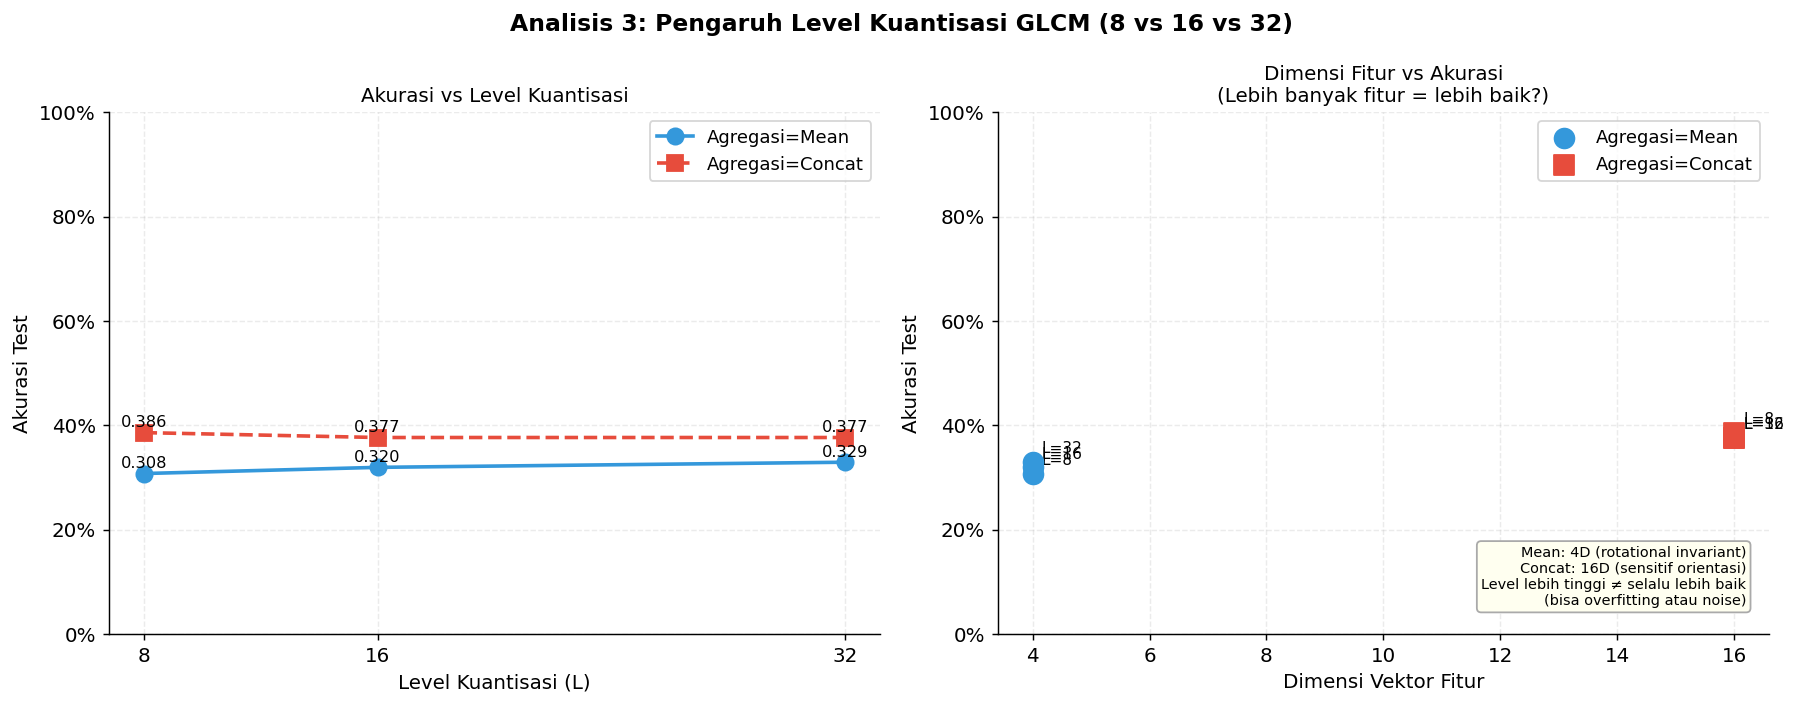


JAWABAN ANALISIS 3 — Pengaruh Level Kuantisasi:
   L=8 mean  : Akurasi=0.3077, Dim=4
   L=8 concat: Akurasi=0.3861, Dim=16
   L=16 mean  : Akurasi=0.3195, Dim=4
   L=16 concat: Akurasi=0.3767, Dim=16
   L=32 mean  : Akurasi=0.3294, Dim=4
   L=32 concat: Akurasi=0.3767, Dim=16
   → Level lebih tinggi → GLCM lebih detail, tapi tidak selalu meningkatkan akurasi
   → Concat (16D) vs Mean (4D): tambahan dimensi bisa membantu atau overfitting
Disimpan: outputs\figures\18_analisis_3_level_kuantisasi.png


In [61]:
#  CELL 5.2 — Analisis 3: Pengaruh Level Kuantisasi (8 vs 16 vs 32)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Analisis 3: Pengaruh Level Kuantisasi GLCM (8 vs 16 vs 32)',
             fontsize=13, fontweight='bold')

levels     = [8, 16, 32]
agg_types  = ['mean', 'concat']
agg_colors = {'mean': '#3498db', 'concat': '#e74c3c'}
markers_d  = {'mean': 'o-', 'concat': 's--'}

# Panel 1: Akurasi test per level dan agregasi
ax = axes[0]
for agg in agg_types:
    accs = [results[f'{lv}-{agg}']['acc_test'] for lv in levels]
    ax.plot(levels, accs, markers_d[agg], color=agg_colors[agg],
            lw=2, ms=9, label=f'Agregasi={agg.capitalize()}')
    for lv, acc in zip(levels, accs):
        ax.text(lv, acc+0.005, f'{acc:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(levels); ax.set_xlabel('Level Kuantisasi (L)', fontsize=11)
ax.set_ylabel('Akurasi Test'); ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0%}'))
ax.set_title('Akurasi vs Level Kuantisasi', fontsize=11)
ax.legend(fontsize=10); ax.grid(alpha=0.25, ls='--'); ax.set_axisbelow(True)

# Panel 2: Dimensi vektor fitur vs akurasi 
ax = axes[1]
for agg in agg_types:
    dims  = [scenarios[f'{lv}-{agg}']['n_feat'] for lv in levels]
    accs  = [results[f'{lv}-{agg}']['acc_test'] for lv in levels]
    ax.scatter(dims, accs, color=agg_colors[agg], s=120,
               label=f'Agregasi={agg.capitalize()}', zorder=5, marker='o' if agg=='mean' else 's')
    for lv, d, acc in zip(levels, dims, accs):
        ax.annotate(f'L={lv}', (d, acc), textcoords='offset points',
                    xytext=(5, 5), fontsize=8.5)

ax.set_xlabel('Dimensi Vektor Fitur', fontsize=11)
ax.set_ylabel('Akurasi Test')
ax.set_ylim(0, 1); ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0%}'))
ax.set_title('Dimensi Fitur vs Akurasi\n(Lebih banyak fitur = lebih baik?)', fontsize=11)
ax.legend(fontsize=10); ax.grid(alpha=0.25, ls='--'); ax.set_axisbelow(True)

# Interpretasi
note = ("Mean: 4D (rotational invariant)\nConcat: 16D (sensitif orientasi)\n"
        "Level lebih tinggi ≠ selalu lebih baik\n(bisa overfitting atau noise)")
ax.text(0.97, 0.05, note, transform=ax.transAxes, ha='right', va='bottom',
        fontsize=8, bbox=dict(boxstyle='round', facecolor='#fffff0', edgecolor='#aaa'))

plt.tight_layout()
plt.savefig(str(OUT_FIGS / '18_analisis_3_level_kuantisasi.png'), bbox_inches='tight', dpi=150)
plt.show()

print("\nJAWABAN ANALISIS 3 — Pengaruh Level Kuantisasi:")
for lv in levels:
    for agg in agg_types:
        key_k = f'{lv}-{agg}'
        print(f"   L={lv} {agg:6s}: Akurasi={results[key_k]['acc_test']:.4f}, "
              f"Dim={scenarios[key_k]['n_feat']}")
print("   → Level lebih tinggi → GLCM lebih detail, tapi tidak selalu meningkatkan akurasi")
print("   → Concat (16D) vs Mean (4D): tambahan dimensi bisa membantu atau overfitting")
print("Disimpan:", OUT_FIGS / '18_analisis_3_level_kuantisasi.png')


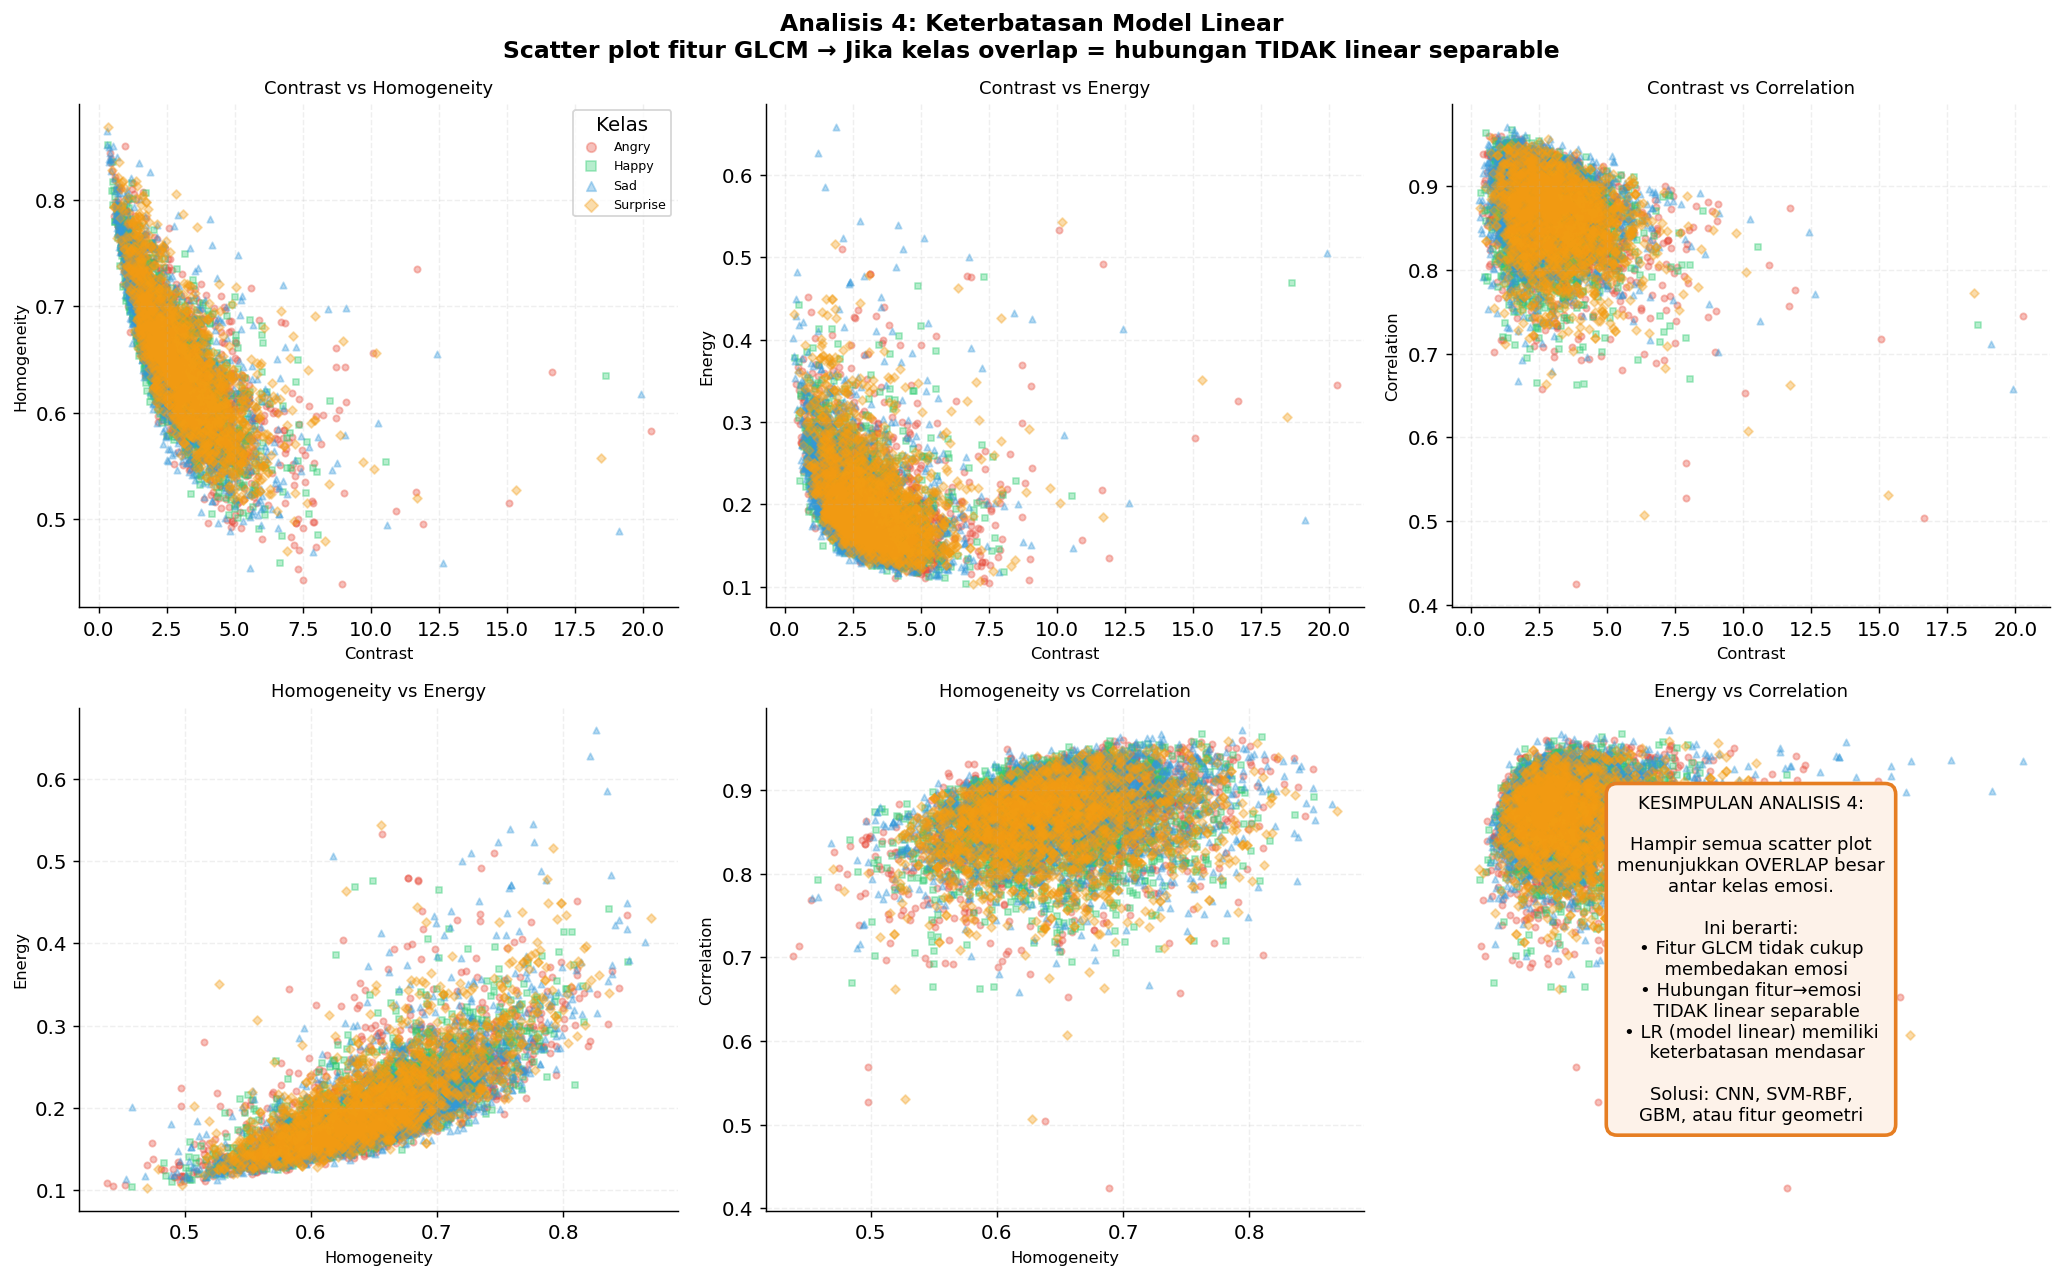

Disimpan: outputs\figures\19_analisis_4_keterbatasan_linear.png


In [62]:
#  CELL 5.3 — Analisis 4 & 5: Keterbatasan Model Linear + Rekap

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(
    'Analisis 4: Keterbatasan Model Linear\n'
    'Scatter plot fitur GLCM → Jika kelas overlap = hubungan TIDAK linear separable',
    fontsize=13, fontweight='bold'
)

# Ambil fitur langsung (sebelum scaling) untuk visualisasi interpretable
feat_all_raw = np.array([
    extract_glcm_features(img, levels=16, aggregation='mean')[0]
    for img in train_norm
], dtype=np.float32)

prop_pairs = [
    (0, 1, 'Contrast', 'Homogeneity'),
    (0, 2, 'Contrast', 'Energy'),
    (0, 3, 'Contrast', 'Correlation'),
    (1, 2, 'Homogeneity', 'Energy'),
    (1, 3, 'Homogeneity', 'Correlation'),
    (2, 3, 'Energy', 'Correlation'),
]

markers = ['o', 's', '^', 'D']
for ax, (xi, yi, xname, yname) in zip(axes.flatten(), prop_pairs):
    for cls_idx, (cls, color, marker) in enumerate(zip(CLASSES, COLORS, markers)):
        mask = np.array(train_labels) == cls
        ax.scatter(feat_all_raw[mask, xi], feat_all_raw[mask, yi],
                   c=color, marker=marker, alpha=0.35, s=12, label=cls.capitalize())
    ax.set_xlabel(xname, fontsize=9); ax.set_ylabel(yname, fontsize=9)
    ax.set_title(f'{xname} vs {yname}', fontsize=10)
    if xi == 0 and yi == 1:
        ax.legend(title='Kelas', fontsize=7, markerscale=1.5)
    ax.grid(alpha=0.2, ls='--')

# Anotasi di panel terakhir tentang keterbatasan
ax_last = axes.flatten()[-1]
ax_last.text(0.5, 0.5,
             "KESIMPULAN ANALISIS 4:\n\n"
             "Hampir semua scatter plot\n"
             "menunjukkan OVERLAP besar\n"
             "antar kelas emosi.\n\n"
             "Ini berarti:\n"
             "• Fitur GLCM tidak cukup\n"
             "  membedakan emosi\n"
             "• Hubungan fitur→emosi\n"
             "  TIDAK linear separable\n"
             "• LR (model linear) memiliki\n"
             "  keterbatasan mendasar\n\n"
             "Solusi: CNN, SVM-RBF,\nGBM, atau fitur geometri",
             ha='center', va='center', fontsize=10,
             transform=ax_last.transAxes,
             bbox=dict(boxstyle='round,pad=0.6', facecolor='#fdf2e9',
                       edgecolor='#e67e22', linewidth=2))
ax_last.axis('off')

plt.tight_layout()
plt.savefig(str(OUT_FIGS / '19_analisis_4_keterbatasan_linear.png'), bbox_inches='tight', dpi=150)
plt.show()
print("Disimpan:", OUT_FIGS / '19_analisis_4_keterbatasan_linear.png')


In [63]:
#  CELL 5.4 — Rekap Akhir: Semua Output & Panduan Laporan

print("=" * 65)
print("  REKAP LENGKAP HASIL EKSPERIMEN")
print("=" * 65)

print(f"\n HASIL 6 SKENARIO:")
print(f"  {'Skenario':<20} {'Dim':>5} {'Acc Train':>11} {'Acc Test':>10}")
print("  " + "-"*48)
for key in results:
    n   = scenarios[key]['n_feat']
    at  = results[key]['acc_train']
    ae  = results[key]['acc_test']
    mark= ' Terbaik' if key == best_key else ''
    print(f"  {key:<20} {n:>5} {at:>11.4f} {ae:>10.4f}{mark}")
print("  " + "-"*48)
print(f"  TERBAIK: {best_key.upper()} → Akurasi Test = {best_acc:.4f} ({best_acc:.2%})")

print(f"\nFILE VISUALISASI (outputs/figures/):")
for f in sorted(OUT_FIGS.glob('*.png')):
    print(f"  {f.name:<50} {f.stat().st_size/1024:>6.1f} KB")

summary = (
    "\n=================================================================\n"
    "  RINGKASAN ANALISIS WAJIB TUGAS\n"
    "=================================================================\n"
    "\n1. APAKAH GLCM CUKUP? (file: 17_analisis_1_2)\n"
    "   Tidak. Akurasi <= 40-50% menunjukkan GLCM (tekstur) tidak cukup\n"
    "   untuk membedakan ekspresi wajah yang membutuhkan fitur GEOMETRI\n"
    "   (bentuk mulut, alis, mata) bukan hanya tekstur pixel.\n"
    "\n2. KELAS TERSULIT? (file: 17_analisis_1_2 + 13_confusion_matrix)\n"
    "   Lihat F1-score terendah dan baris confusion matrix dengan recall\n"
    "   terburuk. Biasanya sad/angry overlap karena GLCM keduanya serupa.\n"
    "\n3. PERAN PARAMETER GLCM (file: 18_analisis_3)\n"
    "   Level 8: GLCM kasar (256 level -> 64 sel), cepat, info sedikit.\n"
    "   Level 16: Keseimbangan detail vs kerapatan matriks.\n"
    "   Level 32: Detail tinggi tapi matriks jarang (sparse), bisa noise.\n"
    "   Concat vs Mean: Concat (16D) lebih informatif tapi lebih overfit.\n"
    "\n4. KETERBATASAN MODEL LINEAR (file: 19_analisis_4 + 10_decision_boundary)\n"
    "   Scatter plot semua pasangan fitur menunjukkan overlap besar ->\n"
    "   tidak ada hyperplane linear yang bisa memisahkan kelas.\n"
    "   Logistic Regression (linear) fundamental terbatas untuk tugas ini.\n"
    "\n5. ERROR ANALYSIS (file: 16_error_analysis)\n"
    "   Gambar yang salah: pencahayaan ekstrem, pose tidak frontal,\n"
    "   ekspresi ambigu (sad vs neutral). Bar prob menunjukkan model ragu\n"
    "   (prob tersebar merata) untuk gambar-gambar ini.\n"
    "=================================================================\n"
)
print(summary)


  REKAP LENGKAP HASIL EKSPERIMEN

 HASIL 6 SKENARIO:
  Skenario               Dim   Acc Train   Acc Test
  ------------------------------------------------
  8-mean                   4      0.3164     0.3077
  8-concat                16      0.3725     0.3861 Terbaik
  16-mean                  4      0.3104     0.3195
  16-concat               16      0.3660     0.3767
  32-mean                  4      0.3150     0.3294
  32-concat               16      0.3622     0.3767
  ------------------------------------------------
  TERBAIK: 8-CONCAT → Akurasi Test = 0.3861 (38.61%)

FILE VISUALISASI (outputs/figures/):
  01_before_after.png                                 356.3 KB
  02_step_a_gambar_asli.png                           190.1 KB
  03_step_b_matriks_keabuan.png                       178.1 KB
  04_step_c_coherence_overview.png                    164.0 KB
  05_step_d_glcm_per_sudut.png                        274.7 KB
  06_step_e_coherence_final.png                       205.3 KB
  07

---
# BAGIAN 6 — Export Model untuk Deployment (Streamlit)

Bagian ini mengekstrak **semua yang dibutuhkan** untuk menjalankan prediksi  
di luar notebook — dikemas dalam satu file `.pkl` agar mudah di-load oleh Streamlit.

## Apa yang Di-export?

```
model_bundle.pkl
│
├── model          → LogisticRegression yang sudah ditraining
├── scaler         → StandardScaler yang sudah di-fit (WAJIB sama!)
├── label_encoder  → LabelEncoder → angka ke nama kelas
├── config         → semua parameter GLCM (levels, angles, aggregation, props)
└── metadata       → akurasi, tanggal export, nama skenario
```

## Mengapa Harus Bundle Semua?

```
Saat training:   gambar → GLCM(L=X,agg=Y) → scaler.fit_transform() → model.fit()
Saat prediksi:   gambar → GLCM(L=X,agg=Y) → scaler.transform()    → model.predict()
                                              ↑ HARUS scaler yang SAMA
                                              Jika scaler berbeda → fitur tidak comparable!
```

## Preprocessing yang WAJIB Sama Antara Training & Prediksi

| Tahap | Training | Prediksi (Streamlit) |
|:------|:--------:|:--------------------:|
| Buka gambar | PIL `'L'` (grayscale) | PIL `'L'` (grayscale) |
| Resize | 48 × 48 LANCZOS | 48 × 48 LANCZOS |
| Normalisasi | `/ 255.0` → float32 | `/ 255.0` → float32 |
| Kuantisasi | `⌊pixel × L⌋` | `⌊pixel × L⌋` (L dari bundle) |
| GLCM | `graycomatrix(...)` | `graycomatrix(...)` (param dari bundle) |
| Scaler | `scaler.fit_transform(X_train)` | `scaler.transform(X_new)` |
| Prediksi | `model.fit(X, y)` | `model.predict(X_new)` |


In [64]:
#  CELL 6.0 — Export Model Bundle untuk Streamlit

import pickle, json
from datetime import datetime
from pathlib import Path

EXPORT_DIR = Path('streamlit_app')
EXPORT_DIR.mkdir(exist_ok=True)

# Pilih skenario terbaik berdasarkan akurasi test 
best_key_export = max(results, key=lambda k: results[k]['acc_test'])
print(f"Skenario terbaik: '{best_key_export}'")
print(f"  Akurasi Test : {results[best_key_export]['acc_test']:.4f}")
print(f"  Akurasi Train: {results[best_key_export]['acc_train']:.4f}")

level_export, agg_export = best_key_export.split('-')
level_export = int(level_export)

# Kumpulkan semua komponen yang dibutuhkan
model_export  = results[best_key_export]['model']
scaler_export = scenarios[best_key_export]['scaler']

model_bundle = {
    # Komponen inti untuk prediksi
    'model'        : model_export,
    'scaler'       : scaler_export,
    'label_encoder': le,

    # Konfigurasi GLCM — HARUS sama persis dengan saat training
    'config': {
        'img_size'   : (48, 48),
        'levels'     : level_export,
        'distances'  : [1],
        'angles'     : [0, float(np.pi/4), float(np.pi/2), float(3*np.pi/4)],
        'aggregation': agg_export,
        'glcm_props' : ['contrast', 'homogeneity', 'energy', 'correlation'],
        'symmetric'  : True,
        'normed'     : True,
    },

    # Metadata
    'metadata': {
        'scenario'    : best_key_export,
        'acc_test'    : float(results[best_key_export]['acc_test']),
        'acc_train'   : float(results[best_key_export]['acc_train']),
        'classes'     : list(le.classes_),
        'n_features'  : scenarios[best_key_export]['n_feat'],
        'exported_at' : datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    }
}

# Simpan bundle 
bundle_path = EXPORT_DIR / 'model_bundle.pkl'
with open(bundle_path, 'wb') as f:
    pickle.dump(model_bundle, f)

print(f"\nBundle tersimpan: {bundle_path}")
print(f"   Ukuran file: {bundle_path.stat().st_size / 1024:.1f} KB")
print(f"\nIsi bundle:")
print(f"   model         : {type(model_export).__name__}")
print(f"   scaler        : {type(scaler_export).__name__}")
print(f"   label_encoder : {list(le.classes_)}")
print(f"   config.levels : {level_export}")
print(f"   config.agg    : {agg_export}")
print(f"   config.angles : 0°, 45°, 90°, 135°")
print(f"   n_features    : {scenarios[best_key_export]['n_feat']}")

# Verifikasi: load balik dan prediksi 1 sampel
print("\nVerifikasi bundle (load ulang & prediksi 1 sampel)...")
with open(bundle_path, 'rb') as f:
    bundle_verify = pickle.load(f)

cfg   = bundle_verify['config']
sc    = bundle_verify['scaler']
mdl   = bundle_verify['model']
enc   = bundle_verify['label_encoder']

# Ambil 1 gambar test
sample_img_norm = test_norm[0]
sample_label    = test_labels[0]

# Jalankan pipeline yang sama persis seperti Streamlit nanti
img_q     = np.clip(np.floor(sample_img_norm * cfg['levels']).astype(np.int32),
                    0, cfg['levels'] - 1)
glcm      = graycomatrix(img_q,
                          distances=cfg['distances'],
                          angles=cfg['angles'],
                          levels=cfg['levels'],
                          symmetric=cfg['symmetric'],
                          normed=cfg['normed'])
feat_vec  = []
if cfg['aggregation'] == 'mean':
    for prop in cfg['glcm_props']:
        feat_vec.append(graycoprops(glcm, prop).mean())
else:
    for prop in cfg['glcm_props']:
        feat_vec.extend(graycoprops(glcm, prop).flatten())

feat_arr     = np.array(feat_vec, dtype=np.float32).reshape(1, -1)
feat_scaled  = sc.transform(feat_arr)
pred_label   = enc.inverse_transform(mdl.predict(feat_scaled))[0]
pred_proba   = mdl.predict_proba(feat_scaled)[0]

print(f"   Label asli   : {sample_label}")
print(f"   Prediksi     : {pred_label}")
print(f"   Probabilitas :")
for cls, p in zip(enc.classes_, pred_proba):
    bar = '█' * int(p * 20)
    print(f"     {cls:10s}: {p:.4f}  {bar}")

print("\nVerifikasi sukses! Bundle siap digunakan di Streamlit.")


Skenario terbaik: '8-concat'
  Akurasi Test : 0.3861
  Akurasi Train: 0.3725

Bundle tersimpan: streamlit_app\model_bundle.pkl
   Ukuran file: 2.7 KB

Isi bundle:
   model         : LogisticRegression
   scaler        : StandardScaler
   label_encoder : [np.str_('angry'), np.str_('happy'), np.str_('sad'), np.str_('surprise')]
   config.levels : 8
   config.agg    : concat
   config.angles : 0°, 45°, 90°, 135°
   n_features    : 16

Verifikasi bundle (load ulang & prediksi 1 sampel)...
   Label asli   : angry
   Prediksi     : sad
   Probabilitas :
     angry     : 0.3183  ██████
     happy     : 0.1925  ███
     sad       : 0.3673  ███████
     surprise  : 0.1219  ██

Verifikasi sukses! Bundle siap digunakan di Streamlit.


---
# BAGIAN 7 — Perbandingan Tiga Model: Apakah Fitur Geometri Berpengaruh?

---

Bagian ini membandingkan tiga konfigurasi secara langsung:

| Model | Fitur | Classifier |
|---|---|---|
| **Model A** | GLCM concat — skenario terbaik (`best_key`) | Logistic Regression |
| **Model B** | GLCM concat + Geometri Wajah | Logistic Regression |
| **Model C** | GLCM concat + Geometri Wajah | SVM (RBF Kernel) |

## Fitur Geometri Wajah yang Ditambahkan

| # | Fitur | Deskripsi |
|---|---|---|
| 1 | **eye_ratio** | Rasio lebar/tinggi bounding box mata (perkiraan keterbukaan mata) |
| 2 | **mouth_ratio** | Rasio lebar/tinggi area mulut (senyum = ratio besar) |
| 3 | **brow_height** | Tinggi relatif alis terhadap wajah (surprise = alis naik) |
| 4 | **face_symmetry** | Simetri vertikal intensitas (wajah simetris vs asimetris) |
| 5 | **edge_density_upper** | Kerapatan tepi area atas wajah (alis/dahi) |
| 6 | **edge_density_lower** | Kerapatan tepi area bawah wajah (mulut/dagu) |
| 7 | **vertical_gradient** | Gradien vertikal rata-rata (distribusi intensitas atas vs bawah) |
| 8 | **pixel_var_ratio** | Rasio variansi bawah/atas wajah |

> **Catatan:** Fitur geometri ini diekstrak langsung dari gambar grayscale 48×48  
> tanpa face detection — menggunakan pembagian region pixel.


In [65]:
#  CELL 7.0 — Ekstraksi Fitur Geometri Wajah

import numpy as np
import cv2
from skimage.feature import graycomatrix, graycoprops

def extract_geometric_features(img_raw):
    """
    Ekstrak 8 fitur geometri wajah dari gambar uint8 48x48.

    Pembagian region:
      Upper half  : baris 0-23  (area mata/alis/dahi)
      Lower half  : baris 24-47 (area hidung/mulut/dagu)
      Eye zone    : baris 12-22, kolom 8-40
      Mouth zone  : baris 30-44, kolom 10-38
      Brow zone   : baris 8-15,  kolom 8-40
    """
    img = img_raw.astype(np.float32)
    h, w = img.shape  # 48, 48

    # Region pembagian wajah
    upper = img[:h//2, :]
    lower = img[h//2:, :]

    eye_zone   = img[12:22, 8:40]
    mouth_zone = img[30:44, 10:38]
    brow_zone  = img[8:15,  8:40]

    # Sobel edge map
    img_u8  = img_raw
    sx = cv2.Sobel(img_u8, cv2.CV_64F, 1, 0, ksize=3)
    sy = cv2.Sobel(img_u8, cv2.CV_64F, 0, 1, ksize=3)
    edge = np.sqrt(sx**2 + sy**2)

    # Fitur 1: eye_ratio
    # Estimasi keterbukaan mata: variansi vertikal di zona mata
    # Mata terbuka lebar (surprise) → variansi tinggi
    eye_var_vert = eye_zone.std(axis=0).mean()   # std tiap kolom
    eye_mean_int = eye_zone.mean()
    eye_ratio    = eye_var_vert / (eye_mean_int + 1e-6)

    # Fitur 2: mouth_ratio
    # Lebar efektif mulut: rasio piksel gelap (lubang mulut) di zona mulut
    mouth_dark_pct = (mouth_zone < mouth_zone.mean()).mean()
    mouth_var      = mouth_zone.std()
    mouth_ratio    = mouth_var / (mouth_zone.mean() + 1e-6)

    # Fitur 3: brow_height
    # Tinggi relatif alis: gradien vertikal zona alis
    # Alis naik (surprise) → gradient besar di baris atas
    brow_grad = np.abs(np.diff(brow_zone.mean(axis=1))).mean()
    brow_height = brow_grad / (brow_zone.mean() + 1e-6)

    # Fitur 4: face_symmetry
    # Simetri kiri-kanan: korelasi antara setengah kiri & kanan
    left_half  = img[:, :w//2]
    right_half = img[:, w//2:][:, ::-1]  # flip horizontal
    diff_sym   = np.abs(left_half - right_half).mean()
    face_symmetry = 1.0 / (1.0 + diff_sym / 255.0)

    # Fitur 5 & 6: edge_density upper & lower 
    edge_upper = edge[:h//2, :].mean()
    edge_lower = edge[h//2:, :].mean()
    edge_density_upper = edge_upper / 255.0
    edge_density_lower = edge_lower / 255.0

    # Fitur 7: vertical_gradient 
    # Distribusi intensitas atas vs bawah
    mean_upper = upper.mean()
    mean_lower = lower.mean()
    vertical_gradient = (mean_lower - mean_upper) / 255.0

    # Fitur 8: pixel_var_ratio
    var_upper = upper.std()
    var_lower = lower.std()
    pixel_var_ratio = var_lower / (var_upper + 1e-6)

    return np.array([
        eye_ratio,
        mouth_ratio,
        brow_height,
        face_symmetry,
        edge_density_upper,
        edge_density_lower,
        vertical_gradient,
        pixel_var_ratio,
    ], dtype=np.float32)


GEO_FEAT_NAMES = [
    'eye_ratio', 'mouth_ratio', 'brow_height', 'face_symmetry',
    'edge_dens_upper', 'edge_dens_lower', 'vert_gradient', 'pixel_var_ratio'
]

# Test pada satu gambar
geo_test = extract_geometric_features(train_raw[0])
print("Fitur geometri (8D) untuk 1 gambar:")
for name, val in zip(GEO_FEAT_NAMES, geo_test):
    print(f"   {name:20s} = {val:.6f}")
print(f"\nShape fitur geometri: {geo_test.shape}")


Fitur geometri (8D) untuk 1 gambar:
   eye_ratio            = 0.205964
   mouth_ratio          = 0.518320
   brow_height          = 0.055487
   face_symmetry        = 0.827167
   edge_dens_upper      = 0.532157
   edge_dens_lower      = 0.549216
   vert_gradient        = -0.152594
   pixel_var_ratio      = 1.019724

Shape fitur geometri: (8,)


## Pipeline Tiga Model

```
Model A: gambar → GLCM concat (16D) → StandardScaler → Logistic Regression
Model B: gambar → [GLCM concat (16D) + Geometri(8D)] → StandardScaler → Logistic Regression
Model C: gambar → [GLCM concat (16D) + Geometri(8D)] → StandardScaler → SVM (RBF)
```

**Mengapa `concat` (16D) untuk GLCM?**
- Dari 6 skenario GLCM + Logistic Regression yang diuji sebelumnya (BAGIAN 3),
  skenario **`best_key`** (concat) memberikan akurasi test tertinggi
- Agregasi `concat` menyimpan informasi fitur per sudut (0°, 45°, 90°, 135°)
  sehingga lebih kaya dibanding `mean` yang hanya 4D
- Kita konsisten menggunakan skenario terbaik yang ditentukan otomatis oleh `best_key`

**Mengapa SVM untuk Model C?**
- SVM dengan kernel RBF dapat menangkap hubungan **non-linear** antara fitur dan kelas
- Decision boundary bukan hyperplane lurus, melainkan kurva kompleks
- Lebih cocok untuk data yang tidak linearly separable (seperti ekspresi wajah)


In [66]:
#  CELL 7.1 — Bangun Tiga Model & Training

import numpy as np
import pickle
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Gunakan skenario terbaik dari BAGIAN 3 (otomatis)
# best_key sudah di-set di CELL 3.2: skenario dengan akurasi test tertinggi
# Contoh: '16-concat' → level=16, agregasi=concat → 16D
LEVELS_COMP, AGG_COMP = best_key.split('-')   # misal: '16', 'concat'
LEVELS_COMP = int(LEVELS_COMP)
N_GLCM_FEAT = scenarios[best_key]['n_feat']   # 16D jika concat, 4D jika mean

print(f"Skenario terbaik GLCM+LR : '{best_key}'")
print(f"  Level       : {LEVELS_COMP}")
print(f"  Agregasi    : {AGG_COMP}")
print(f"  Dimensi GLCM: {N_GLCM_FEAT}D")

# Ambil fitur GLCM (sudah di-scale) dari skenario terbaik
X_A_tr = scenarios[best_key]['X_train']   # (n_train, N_GLCM_FEAT)
X_A_te = scenarios[best_key]['X_test']    # (n_test,  N_GLCM_FEAT)

# Ekstrak ulang GLCM (unscaled) untuk digabung dengan geometri
print(f"\nMengekstrak fitur GLCM unscaled ({AGG_COMP}, L={LEVELS_COMP})...")
X_glcm_tr_raw = np.array([
    extract_glcm_features(img, LEVELS_COMP, aggregation=AGG_COMP)[0]
    for img in train_norm
], dtype=np.float32)
X_glcm_te_raw = np.array([
    extract_glcm_features(img, LEVELS_COMP, aggregation=AGG_COMP)[0]
    for img in test_norm
], dtype=np.float32)
print(f"   GLCM train: {X_glcm_tr_raw.shape}  ({N_GLCM_FEAT}D)")

# Ekstraksi fitur geometri
print("Mengekstrak fitur geometri wajah...")
X_geo_tr = np.array([
    extract_geometric_features(img) for img in train_raw
], dtype=np.float32)
X_geo_te = np.array([
    extract_geometric_features(img) for img in test_raw
], dtype=np.float32)
print(f"   Geometri train: {X_geo_tr.shape}  (8D)")

# Gabungkan: GLCM + Geometri
N_COMBINED = N_GLCM_FEAT + 8
X_combined_tr_raw = np.hstack([X_glcm_tr_raw, X_geo_tr])   # (n, N_COMBINED)
X_combined_te_raw = np.hstack([X_glcm_te_raw, X_geo_te])
print(f"   Combined train: {X_combined_tr_raw.shape}  (GLCM {N_GLCM_FEAT}D + Geometri 8D = {N_COMBINED}D)")

# Standard Scaling untuk Model B & C 
scaler_combined = StandardScaler()
X_BC_tr = scaler_combined.fit_transform(X_combined_tr_raw)
X_BC_te = scaler_combined.transform(X_combined_te_raw)

print("\nTraining tiga model...")

# Model A: GLCM (concat, terbaik) + Logistic Regression
model_A = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
model_A.fit(X_A_tr, y_train)
y_pred_A_tr = model_A.predict(X_A_tr)
y_pred_A_te = model_A.predict(X_A_te)
acc_A_tr = accuracy_score(y_train, y_pred_A_tr)
acc_A_te = accuracy_score(y_test,  y_pred_A_te)
print(f"   Model A (GLCM {N_GLCM_FEAT}D + LR)        — Train: {acc_A_tr:.4f} | Test: {acc_A_te:.4f}")

# Model B: GLCM + Geometri + Logistic Regression
model_B = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
model_B.fit(X_BC_tr, y_train)
y_pred_B_tr = model_B.predict(X_BC_tr)
y_pred_B_te = model_B.predict(X_BC_te)
acc_B_tr = accuracy_score(y_train, y_pred_B_tr)
acc_B_te = accuracy_score(y_test,  y_pred_B_te)
print(f"   Model B (GLCM {N_GLCM_FEAT}D + Geo 8D + LR) — Train: {acc_B_tr:.4f} | Test: {acc_B_te:.4f}")

# Model C: GLCM + Geometri + SVM (RBF)
model_C = SVC(kernel='rbf', C=1, gamma='scale',
              probability=True, random_state=RANDOM_STATE)
# from sklearn.model_selection import GridSearchCV
# param_grid = {'C': [0.1, 1, 5, 10], 'gamma': ['scale', 'auto', 0.01, 0.001]}
# gs = GridSearchCV(SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
#                   param_grid, cv=5, scoring='accuracy', n_jobs=-1)
# gs.fit(X_BC_tr, y_train)
# model_C = gs.best_estimator_
# print(f"Best params: {gs.best_params_}")
model_C.fit(X_BC_tr, y_train)
y_pred_C_tr = model_C.predict(X_BC_tr)
y_pred_C_te = model_C.predict(X_BC_te)
acc_C_tr = accuracy_score(y_train, y_pred_C_tr)
acc_C_te = accuracy_score(y_test,  y_pred_C_te)
print(f"   Model C (GLCM {N_GLCM_FEAT}D + Geo 8D + SVM) — Train: {acc_C_tr:.4f} | Test: {acc_C_te:.4f}")

print("\nSemua model selesai ditraining!")
print(f"\nRingkasan dimensi fitur:")
print(f"   Model A : {N_GLCM_FEAT}D  (GLCM {AGG_COMP}, L={LEVELS_COMP})")
print(f"   Model B : {N_COMBINED}D  (GLCM {N_GLCM_FEAT}D + Geometri 8D)")
print(f"   Model C : {N_COMBINED}D  (GLCM {N_GLCM_FEAT}D + Geometri 8D)")


Skenario terbaik GLCM+LR : '8-concat'
  Level       : 8
  Agregasi    : concat
  Dimensi GLCM: 16D

Mengekstrak fitur GLCM unscaled (concat, L=8)...
   GLCM train: (8112, 16)  (16D)
Mengekstrak fitur geometri wajah...
   Geometri train: (8112, 8)  (8D)
   Combined train: (8112, 24)  (GLCM 16D + Geometri 8D = 24D)

Training tiga model...
   Model A (GLCM 16D + LR)        — Train: 0.3725 | Test: 0.3861
   Model B (GLCM 16D + Geo 8D + LR) — Train: 0.4177 | Test: 0.4260
   Model C (GLCM 16D + Geo 8D + SVM) — Train: 0.5094 | Test: 0.4679

Semua model selesai ditraining!

Ringkasan dimensi fitur:
   Model A : 16D  (GLCM concat, L=8)
   Model B : 24D  (GLCM 16D + Geometri 8D)
   Model C : 24D  (GLCM 16D + Geometri 8D)


In [67]:
#  CELL 7.2 — Classification Report Ketiga Model

model_configs = [
    ('A', 'GLCM + Logistic Regression',        y_pred_A_te, acc_A_tr, acc_A_te, '#3498db'),
    ('B', 'GLCM + Geometri + Logistic Regression', y_pred_B_te, acc_B_tr, acc_B_te, '#2ecc71'),
    ('C', 'GLCM + Geometri + SVM (RBF)',       y_pred_C_te, acc_C_tr, acc_C_te, '#e74c3c'),
]

for mid, mname, y_pred, atr, ate, _ in model_configs:
    print(f"{'='*62}")
    print(f"  MODEL {mid}: {mname}")
    print(f"  Train Acc={atr:.4f} ({atr:.2%}) | Test Acc={ate:.4f} ({ate:.2%})")
    print(f"{'='*62}")
    print(classification_report(y_test, y_pred,
                                 target_names=[c.capitalize() for c in le.classes_]))
    print()


  MODEL A: GLCM + Logistic Regression
  Train Acc=0.3725 (37.25%) | Test Acc=0.3861 (38.61%)
              precision    recall  f1-score   support

       Angry       0.34      0.24      0.28       507
       Happy       0.36      0.36      0.36       507
         Sad       0.35      0.36      0.35       507
    Surprise       0.46      0.59      0.52       507

    accuracy                           0.39      2028
   macro avg       0.38      0.39      0.38      2028
weighted avg       0.38      0.39      0.38      2028


  MODEL B: GLCM + Geometri + Logistic Regression
  Train Acc=0.4177 (41.77%) | Test Acc=0.4260 (42.60%)
              precision    recall  f1-score   support

       Angry       0.37      0.27      0.31       507
       Happy       0.41      0.46      0.44       507
         Sad       0.39      0.34      0.36       507
    Surprise       0.50      0.63      0.56       507

    accuracy                           0.43      2028
   macro avg       0.42      0.43      0.

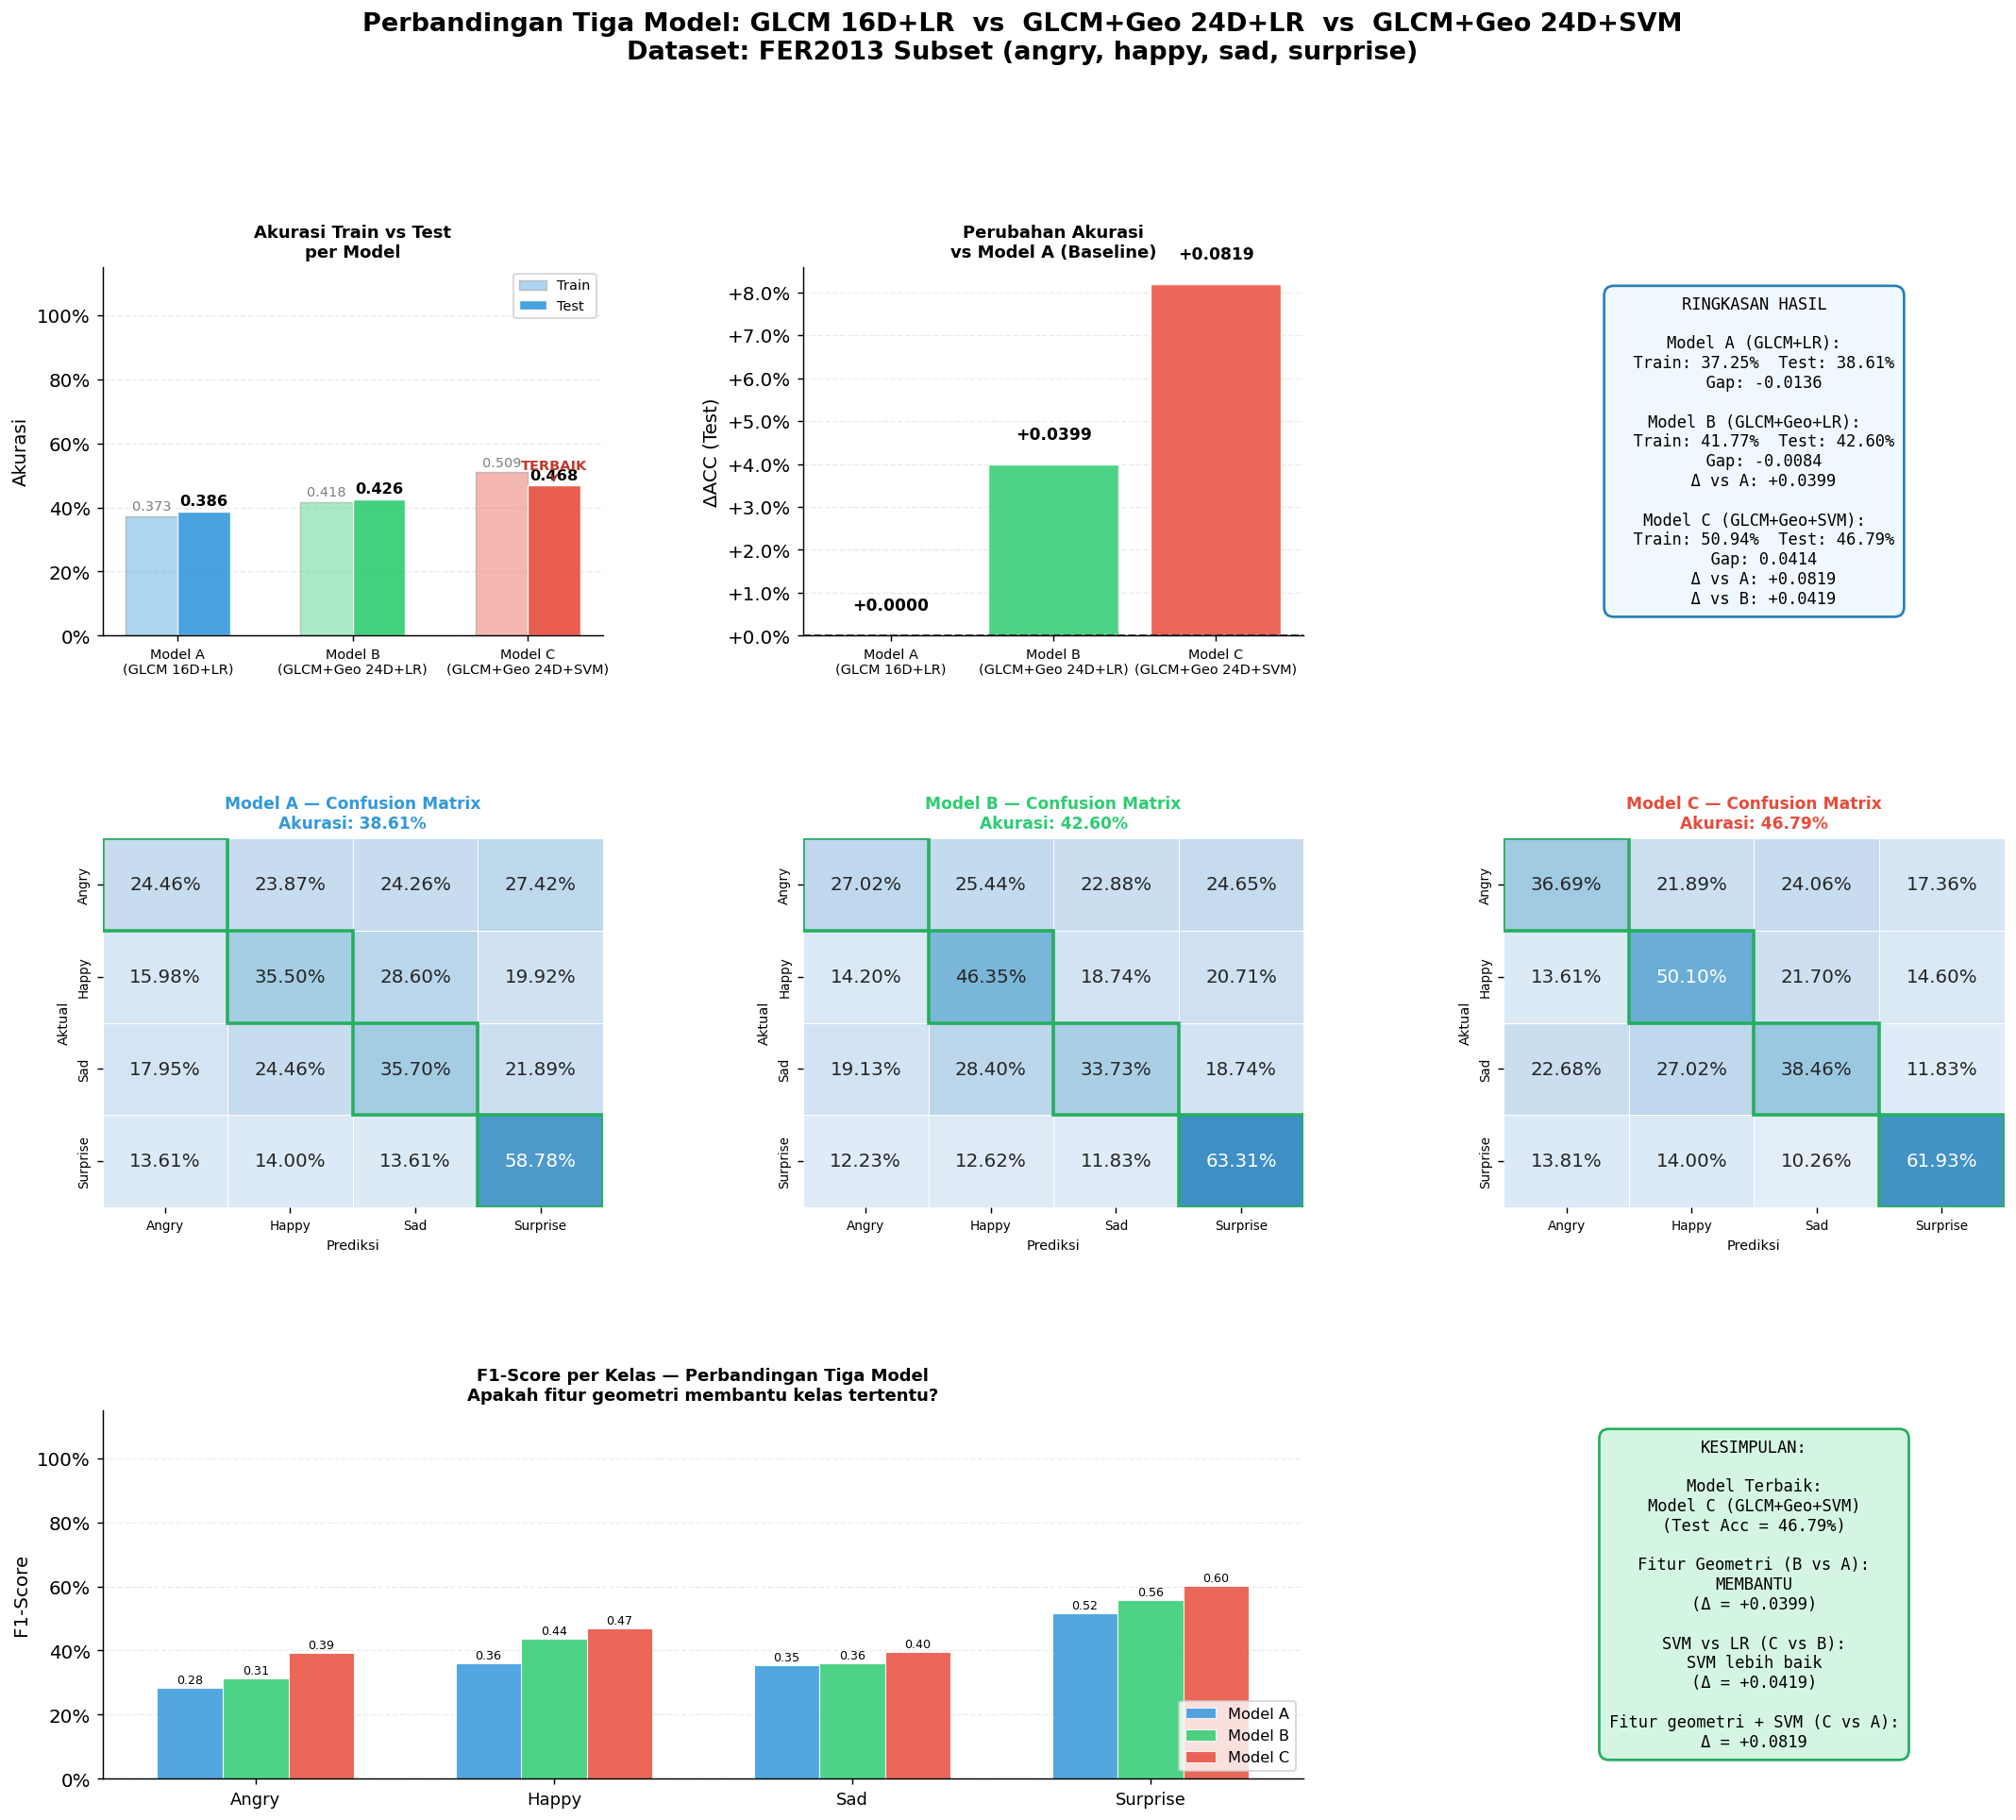

Disimpan: outputs\figures\23_perbandingan_tiga_model.png


In [68]:
#  CELL 7.3 — Visualisasi Perbandingan Lengkap (3 Model)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

model_labels = [f'Model A\n(GLCM {N_GLCM_FEAT}D+LR)', f'Model B\n(GLCM+Geo {N_COMBINED}D+LR)', f'Model C\n(GLCM+Geo {N_COMBINED}D+SVM)']
model_colors = ['#3498db', '#2ecc71', '#e74c3c']
acc_trains = [acc_A_tr, acc_B_tr, acc_C_tr]
acc_tests  = [acc_A_te, acc_B_te, acc_C_te]
gaps       = [tr - te for tr, te in zip(acc_trains, acc_tests)]

fig = plt.figure(figsize=(20, 16))
fig.suptitle(
    f'Perbandingan Tiga Model: GLCM {N_GLCM_FEAT}D+LR  vs  GLCM+Geo {N_COMBINED}D+LR  vs  GLCM+Geo {N_COMBINED}D+SVM\n'
    'Dataset: FER2013 Subset (angry, happy, sad, surprise)',
    fontsize=15, fontweight='bold', y=1.01
)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.4)

# Baris 0: Akurasi ringkas 

# Panel [0,0]: Bar chart akurasi train vs test
ax0 = fig.add_subplot(gs[0, 0])
x = np.arange(3); w = 0.3
b1 = ax0.bar(x - w/2, acc_trains, w, color=model_colors, alpha=0.4,
             edgecolor='gray', linewidth=0.8, label='Train')
b2 = ax0.bar(x + w/2, acc_tests,  w, color=model_colors, alpha=0.9,
             edgecolor='white', linewidth=0.8, label='Test')
for bar, val in zip(b1, acc_trains):
    ax0.text(bar.get_x()+bar.get_width()/2, val+0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=8, color='gray')
for bar, val in zip(b2, acc_tests):
    ax0.text(bar.get_x()+bar.get_width()/2, val+0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax0.set_xticks(x); ax0.set_xticklabels(model_labels, fontsize=8)
ax0.set_ylim(0, 1.15)
ax0.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0%}'))
ax0.set_title('Akurasi Train vs Test\nper Model', fontsize=10, fontweight='bold')
ax0.set_ylabel('Akurasi')
ax0.legend(fontsize=8); ax0.grid(axis='y', alpha=0.25, ls='--'); ax0.set_axisbelow(True)

# Annotate best
best_idx = acc_tests.index(max(acc_tests))
ax0.annotate('TERBAIK', xy=(x[best_idx]+w/2, acc_tests[best_idx]),
             xytext=(x[best_idx]+w/2, acc_tests[best_idx]+0.05),
             ha='center', fontsize=8, color='#c0392b', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#c0392b'))

# Panel [0,1]: Peningkatan akurasi (delta dari baseline)
ax1 = fig.add_subplot(gs[0, 1])
delta_B = acc_B_te - acc_A_te
delta_C = acc_C_te - acc_A_te
delta_CB = acc_C_te - acc_B_te
delta_vals  = [0, delta_B, delta_C]
delta_colors = ['#95a5a6', '#2ecc71' if delta_B >= 0 else '#e74c3c',
                '#e74c3c' if delta_C >= 0 else '#c0392b']
bars_d = ax1.bar(x, delta_vals, color=delta_colors, alpha=0.85,
                 edgecolor='white', linewidth=0.8)
ax1.axhline(0, color='black', lw=1.2, ls='--', alpha=0.6)
for bar, val in zip(bars_d, delta_vals):
    offset = 0.005 if val >= 0 else -0.015
    ax1.text(bar.get_x()+bar.get_width()/2,
             val+offset if val >= 0 else val+offset,
             f'{val:+.4f}', ha='center', va='bottom' if val >= 0 else 'top',
             fontsize=9.5, fontweight='bold')
ax1.set_xticks(x); ax1.set_xticklabels(model_labels, fontsize=8)
ax1.set_title('Perubahan Akurasi\nvs Model A (Baseline)', fontsize=10, fontweight='bold')
ax1.set_ylabel('ΔACC (Test)')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:+.1%}'))
ax1.grid(axis='y', alpha=0.25, ls='--'); ax1.set_axisbelow(True)

# Panel [0,2]: Ringkasan teks
ax2 = fig.add_subplot(gs[0, 2])
ax2.axis('off')
summary_text = (
    f'RINGKASAN HASIL\n\n'
    f'Model A (GLCM+LR):\n'
    f'  Train: {acc_A_tr:.2%}  Test: {acc_A_te:.2%}\n'
    f'  Gap: {acc_A_tr-acc_A_te:.4f}\n\n'
    f'Model B (GLCM+Geo+LR):\n'
    f'  Train: {acc_B_tr:.2%}  Test: {acc_B_te:.2%}\n'
    f'  Gap: {acc_B_tr-acc_B_te:.4f}\n'
    f'  Δ vs A: {delta_B:+.4f}\n\n'
    f'Model C (GLCM+Geo+SVM):\n'
    f'  Train: {acc_C_tr:.2%}  Test: {acc_C_te:.2%}\n'
    f'  Gap: {acc_C_tr-acc_C_te:.4f}\n'
    f'  Δ vs A: {delta_C:+.4f}\n'
    f'  Δ vs B: {delta_CB:+.4f}'
)
ax2.text(0.5, 0.5, summary_text, transform=ax2.transAxes,
         ha='center', va='center', fontsize=9.5, fontfamily='monospace',
         bbox=dict(boxstyle='round,pad=0.6', facecolor='#f0f8ff', edgecolor='#2980b9', lw=1.5))

# Baris 1: Confusion Matrix (3 model)
all_preds = [y_pred_A_te, y_pred_B_te, y_pred_C_te]
for col, (mid, y_pred, color) in enumerate(zip(['A', 'B', 'C'], all_preds, model_colors)):
    ax = fig.add_subplot(gs[1, col])
    cm_m = confusion_matrix(y_test, y_pred)
    cm_n = cm_m.astype(float) / cm_m.sum(axis=1, keepdims=True)
    sns.heatmap(cm_n, ax=ax, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=[c.capitalize() for c in le.classes_],
                yticklabels=[c.capitalize() for c in le.classes_],
                linewidths=0.5, linecolor='white', vmin=0, vmax=1, cbar=False)
    for i in range(4):
        ax.add_patch(mpatches.Rectangle((i, i), 1, 1, fill=False,
                                         edgecolor='#27ae60', lw=2))
    acc_val = accuracy_score(y_test, y_pred)
    ax.set_title(f'Model {mid} — Confusion Matrix\nAkurasi: {acc_val:.2%}',
                 fontsize=9.5, fontweight='bold', color=color)
    ax.set_xlabel('Prediksi', fontsize=8); ax.set_ylabel('Aktual', fontsize=8)
    ax.tick_params(labelsize=7.5)

# Baris 2: F1-score per kelas (3 model)
f1_per_class = []
for y_pred in all_preds:
    _, _, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, labels=list(range(len(le.classes_))))
    f1_per_class.append(f1)

# Panel [2,0]: F1 grouped bar per kelas
ax_f1 = fig.add_subplot(gs[2, 0:2])
x_cls = np.arange(4); w_f1 = 0.22
for i, (mid, f1_vals, mcolor) in enumerate(zip(['A','B','C'], f1_per_class, model_colors)):
    offset = (i - 1) * w_f1
    bars_f1 = ax_f1.bar(x_cls + offset, f1_vals, w_f1,
                         label=f'Model {mid}', color=mcolor, alpha=0.85,
                         edgecolor='white', linewidth=0.6)
    for bar, val in zip(bars_f1, f1_vals):
        ax_f1.text(bar.get_x()+bar.get_width()/2, val+0.005,
                   f'{val:.2f}', ha='center', va='bottom', fontsize=7)

ax_f1.set_xticks(x_cls)
ax_f1.set_xticklabels([c.capitalize() for c in le.classes_], fontsize=10)
ax_f1.set_ylim(0, 1.15)
ax_f1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0%}'))
ax_f1.set_ylabel('F1-Score')
ax_f1.set_title('F1-Score per Kelas — Perbandingan Tiga Model\n'
                'Apakah fitur geometri membantu kelas tertentu?',
                fontsize=10, fontweight='bold')
ax_f1.legend(fontsize=9, loc='lower right')
ax_f1.grid(axis='y', alpha=0.25, ls='--'); ax_f1.set_axisbelow(True)

# Panel [2,2]: Kesimpulan
ax_conc = fig.add_subplot(gs[2, 2])
ax_conc.axis('off')

# Determine winner
best_model_label = ['A (GLCM+LR)', 'B (GLCM+Geo+LR)', 'C (GLCM+Geo+SVM)'][best_idx]
geo_helped = delta_B > 0.005
svm_helped = delta_CB > 0.005

conc_text = (
    f'KESIMPULAN:\n\n'
    f'Model Terbaik:\nModel {best_model_label}\n'
    f'(Test Acc = {max(acc_tests):.2%})\n\n'
    f'Fitur Geometri (B vs A):\n'
    f'{"MEMBANTU" if geo_helped else "Tidak signifikan"}\n'
    f'(Δ = {delta_B:+.4f})\n\n'
    f'SVM vs LR (C vs B):\n'
    f'{"SVM lebih baik" if svm_helped else "Hampir sama/LR cukup"}\n'
    f'(Δ = {delta_CB:+.4f})\n\n'
    f'Fitur geometri + SVM (C vs A):\n'
    f'Δ = {delta_C:+.4f}'
)
facecolor = '#d5f5e3' if max(acc_tests) == acc_C_te else '#fef9e7'
ax_conc.text(0.5, 0.5, conc_text, transform=ax_conc.transAxes,
             ha='center', va='center', fontsize=9.5, fontfamily='monospace',
             bbox=dict(boxstyle='round,pad=0.6', facecolor=facecolor,
                       edgecolor='#27ae60', lw=1.5))

plt.savefig(str(OUT_FIGS / '23_perbandingan_tiga_model.png'), bbox_inches='tight', dpi=150)
plt.show()
print("Disimpan:", OUT_FIGS / '23_perbandingan_tiga_model.png')


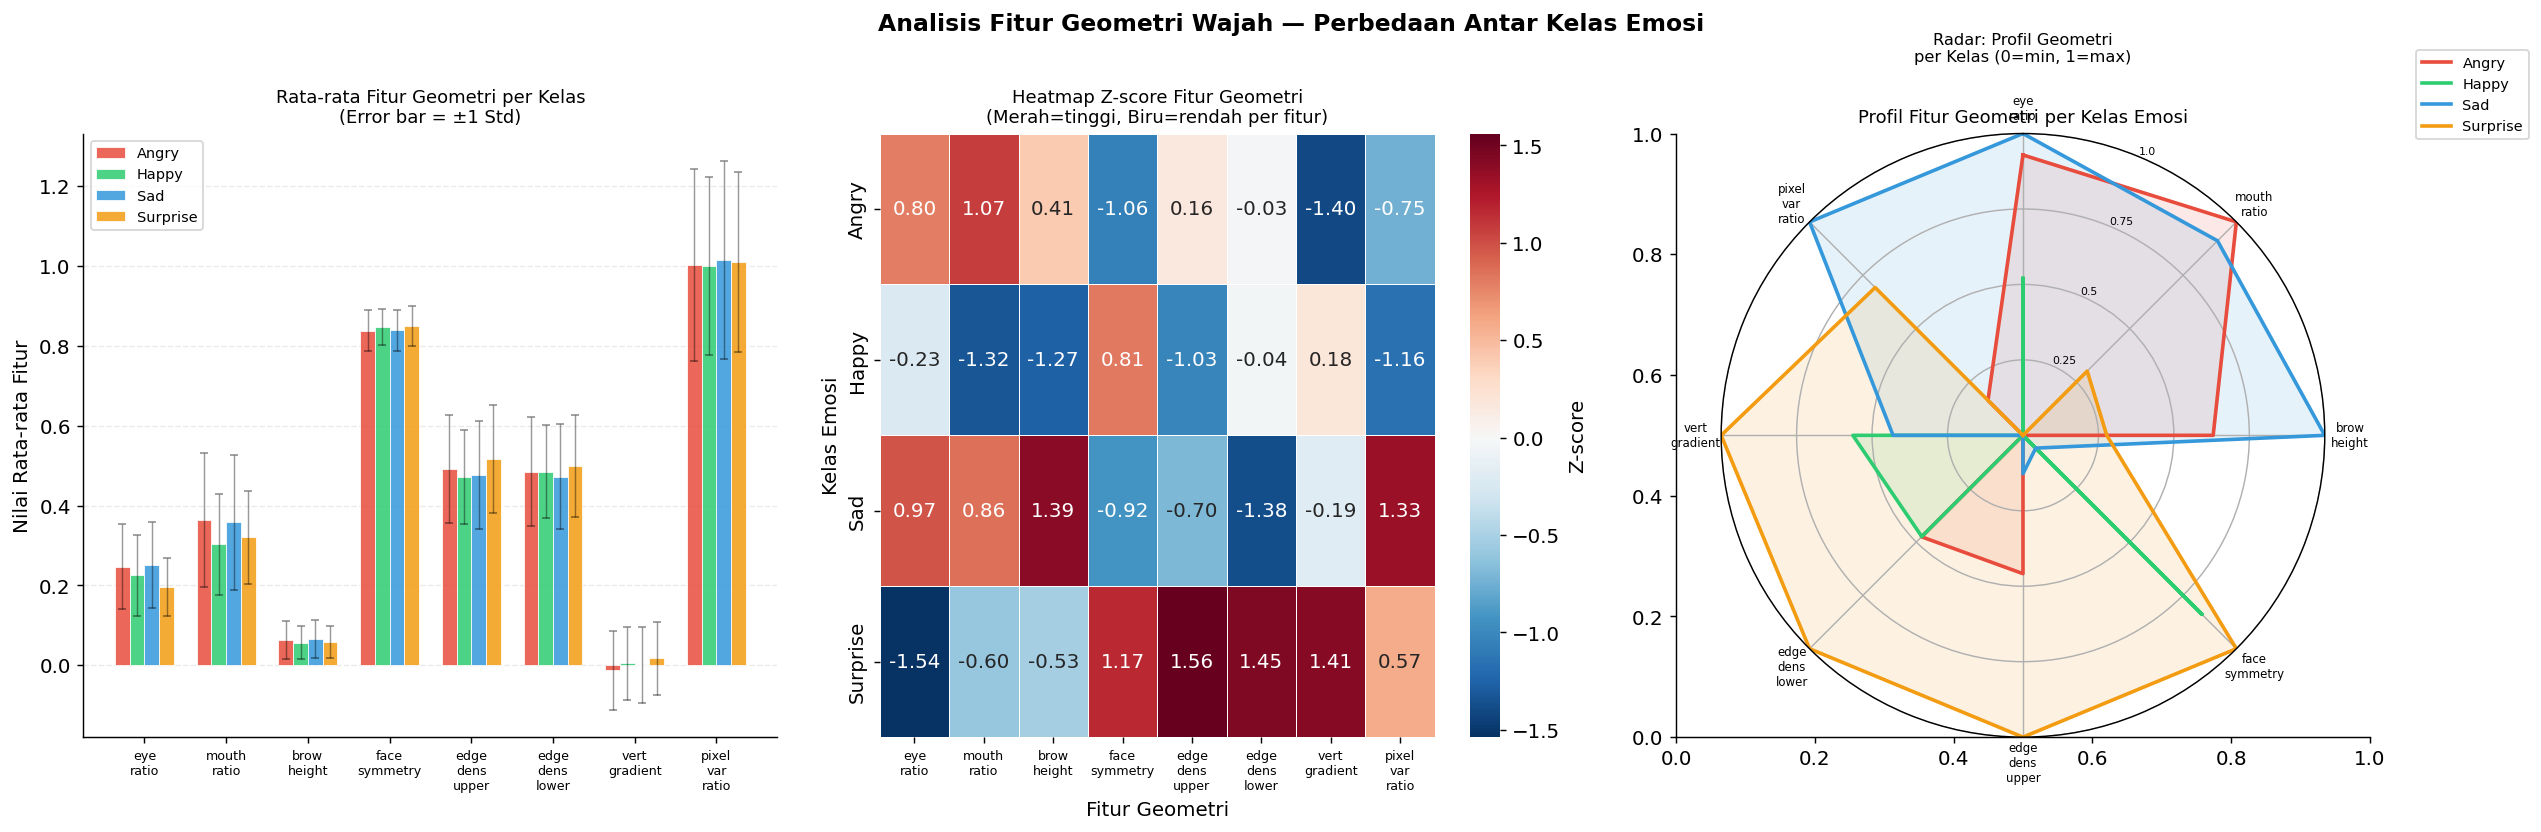

Disimpan: outputs\figures\24_geometric_feature_analysis.png

Diskriminativitas Fitur Geometri (Spread antar kelas):
   mouth_ratio              : spread=0.0605
   eye_ratio                : spread=0.0540
   edge_dens_upper          : spread=0.0458
   vert_gradient            : spread=0.0309
   edge_dens_lower          : spread=0.0265
   pixel_var_ratio          : spread=0.0152
   face_symmetry            : spread=0.0107
   brow_height              : spread=0.0099


In [69]:
#  CELL 7.4 — Analisis Fitur Geometri & Radar Chart

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# 1. Rata-rata fitur geometri per kelas
geo_class_means = {}
geo_class_stds  = {}
for cls in CLASSES:
    mask = np.array(train_labels) == cls
    vals = X_geo_tr[mask]
    geo_class_means[cls] = vals.mean(axis=0)
    geo_class_stds[cls]  = vals.std(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(20, 6.5))
fig.suptitle(
    'Analisis Fitur Geometri Wajah — Perbedaan Antar Kelas Emosi',
    fontsize=13, fontweight='bold'
)

# Panel 1: Bar chart fitur geometri per kelas
ax = axes[0]
n_geo = len(GEO_FEAT_NAMES)
x_g = np.arange(n_geo); w_g = 0.18
for i, (cls, color) in enumerate(zip(CLASSES, COLORS)):
    offset = (i - (len(CLASSES)-1)/2) * w_g
    bars = ax.bar(x_g + offset, geo_class_means[cls], w_g,
                  label=cls.capitalize(), color=color, alpha=0.85,
                  edgecolor='white', linewidth=0.5)
    ax.errorbar(x_g + offset, geo_class_means[cls],
                yerr=geo_class_stds[cls],
                fmt='none', ecolor='black', elinewidth=0.8,
                capsize=2, alpha=0.4)

ax.set_xticks(x_g)
ax.set_xticklabels([n.replace('_', '\n') for n in GEO_FEAT_NAMES], fontsize=7)
ax.set_ylabel('Nilai Rata-rata Fitur')
ax.set_title('Rata-rata Fitur Geometri per Kelas\n(Error bar = ±1 Std)', fontsize=10)
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.25, ls='--'); ax.set_axisbelow(True)

# Panel 2: Heatmap Z-score fitur geometri per kelas
ax = axes[1]
geo_matrix = np.array([geo_class_means[cls] for cls in CLASSES])  # (4, 8)
# Z-score across classes (normalize per feature)
geo_z = (geo_matrix - geo_matrix.mean(axis=0, keepdims=True)) / (geo_matrix.std(axis=0, keepdims=True) + 1e-8)
import seaborn as sns
sns.heatmap(geo_z, ax=ax, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            xticklabels=[n.replace('_','\n') for n in GEO_FEAT_NAMES],
            yticklabels=[c.capitalize() for c in CLASSES],
            linewidths=0.3, cbar_kws={'label': 'Z-score'})
ax.set_title('Heatmap Z-score Fitur Geometri\n(Merah=tinggi, Biru=rendah per fitur)', fontsize=10)
ax.set_xlabel('Fitur Geometri'); ax.set_ylabel('Kelas Emosi')
ax.tick_params(axis='x', rotation=0, labelsize=7)

# Panel 3: Radar chart per kelas (fitur geometri ternormalisasi)
ax = axes[2]
ax.set_title('Profil Fitur Geometri per Kelas Emosi', fontsize=10)

# Normalisasi 0-1 untuk radar
geo_min = geo_matrix.min(axis=0)
geo_max = geo_matrix.max(axis=0)
geo_norm_radar = (geo_matrix - geo_min) / (geo_max - geo_min + 1e-8)

# Radar chart manual
n_feat = len(GEO_FEAT_NAMES)
angles = np.linspace(0, 2*np.pi, n_feat, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

ax = fig.add_subplot(1, 3, 3, polar=True)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels([n.replace('_', '\n') for n in GEO_FEAT_NAMES], fontsize=6.5)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25','0.5','0.75','1.0'], fontsize=6)

for cls, color, vals in zip(CLASSES, COLORS, geo_norm_radar):
    vals_plot = np.concatenate([vals, [vals[0]]])
    ax.plot(angles, vals_plot, color=color, lw=2, label=cls.capitalize())
    ax.fill(angles, vals_plot, color=color, alpha=0.12)

ax.set_title('Radar: Profil Geometri\nper Kelas (0=min, 1=max)', fontsize=9, pad=18)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=8)

plt.tight_layout()
plt.savefig(str(OUT_FIGS / '24_geometric_feature_analysis.png'), bbox_inches='tight', dpi=150)
plt.show()
print("Disimpan:", OUT_FIGS / '24_geometric_feature_analysis.png')

# Cetak diskriminativitas fitur
print("\nDiskriminativitas Fitur Geometri (Spread antar kelas):")
spread = geo_matrix.max(axis=0) - geo_matrix.min(axis=0)
sorted_idx = np.argsort(spread)[::-1]
for i in sorted_idx:
    print(f"   {GEO_FEAT_NAMES[i]:25s}: spread={spread[i]:.4f}")


In [70]:
#  CELL 7.5 — Tabel Rekap Final & Kesimpulan

from sklearn.metrics import precision_recall_fscore_support
import numpy as np

print("=" * 72)
print("  REKAP FINAL — PERBANDINGAN TIGA MODEL")
print("=" * 72)

header = f"{'Model':<35} {'Dim':>5} {'Train':>8} {'Test':>8} {'Gap':>7} {'Status'}"
print("\n" + header)
print("  " + "-" * 70)

model_infos = [
    ('A: GLCM + LR (baseline)',        16,  acc_A_tr, acc_A_te, y_pred_A_te),
    ('B: GLCM + Geometri + LR',        24, acc_B_tr, acc_B_te, y_pred_B_te),
    ('C: GLCM + Geometri + SVM (RBF)', 24, acc_C_tr, acc_C_te, y_pred_C_te),
]

for mname, dim, atr, ate, _ in model_infos:
    gap = atr - ate
    if gap > 0.10:   status = 'Overfit'
    elif ate < 0.35: status = 'Underfit'
    else:            status = 'OK'
    star = ' Terbaik' if ate == max(acc_A_te, acc_B_te, acc_C_te) else ''
    print(f"  {mname:<35} {dim:>5} {atr:>8.4f} {ate:>8.4f} {gap:>7.4f}  {status}{star}")

print("  " + "-" * 70)

print("\n  Pengaruh penambahan Fitur Geometri (B vs A):")
delta_geo = acc_B_te - acc_A_te
print(f"    ΔTest Accuracy = {delta_geo:+.4f} ({delta_geo:+.2%})")
if abs(delta_geo) < 0.01:
    print("    → Fitur geometri TIDAK berpengaruh signifikan terhadap LR")
elif delta_geo > 0:
    print("    → Fitur geometri MEMBANTU meningkatkan akurasi LR")
else:
    print("    → Fitur geometri justru menurunkan akurasi LR")

print("\n  Pengaruh penggantian ke SVM (C vs B):")
delta_svm = acc_C_te - acc_B_te
print(f"    ΔTest Accuracy = {delta_svm:+.4f} ({delta_svm:+.2%})")
if delta_svm > 0.01:
    print("    → SVM dengan kernel RBF LEBIH BAIK dari LR (hubungan non-linear)")
elif abs(delta_svm) <= 0.01:
    print("    → SVM dan LR memberikan hasil yang SEBANDING")
else:
    print("    → LR masih lebih baik untuk fitur ini")

print("\n  Pengaruh gabungan Geometri + SVM (C vs A):")
delta_total = acc_C_te - acc_A_te
print(f"    ΔTest Accuracy = {delta_total:+.4f} ({delta_total:+.2%})")

print("\n  F1-Score per Kelas:")
print(f"  {'Kelas':<12} {'Model A':>10} {'Model B':>10} {'Model C':>10} {'Terbaik':<10}")
print("  " + "-" * 54)
all_f1 = []
for y_pred in [y_pred_A_te, y_pred_B_te, y_pred_C_te]:
    _, _, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, labels=list(range(4)))
    all_f1.append(f1)
for i, cls in enumerate(le.classes_):
    fa, fb, fc = all_f1[0][i], all_f1[1][i], all_f1[2][i]
    best = ['A','B','C'][np.argmax([fa, fb, fc])]
    print(f"  {cls.capitalize():<12} {fa:>10.4f} {fb:>10.4f} {fc:>10.4f} {'Model '+best:<10}")

print("\n" + "=" * 72)
print("  INSIGHT UTAMA:")
print("  1. GLCM (tekstur) menangkap pola pixel bertetangga, bukan bentuk wajah")
print("  2. Fitur geometri menambahkan info struktur (mata/mulut/alis) yang hilang")
print("  3. SVM-RBF dapat menangkap non-linearitas yang tidak bisa dilakukan LR")
print("  4. Kombinasi fitur lebih kaya → representasi emosi lebih lengkap")
print("=" * 72)


#  CELL 7.6 — Export Tiga Bundle untuk Streamlit (Model A, B, C)
import pickle
from datetime import datetime
from pathlib import Path

EXPORT_DIR = Path('streamlit_app')
EXPORT_DIR.mkdir(exist_ok=True)

# Konfigurasi GLCM per model
# best_key sudah di-set di CELL 3.2 (misal: '8-concat')
lvl_str, agg_str = best_key.split('-')
lvl_int = int(lvl_str)

BASE_GLCM_CONFIG = {
    'img_size'   : (48, 48),
    'levels'     : lvl_int,
    'distances'  : [1],
    'angles'     : [0, float(np.pi/4), float(np.pi/2), float(3*np.pi/4)],
    'aggregation': agg_str,
    'glcm_props' : ['contrast', 'homogeneity', 'energy', 'correlation'],
    'symmetric'  : True,
    'normed'     : True,
}

# Definisi tiga bundle
bundle_defs = {
    'A': {
        'model'       : model_A,
        'scaler'      : scenarios[best_key]['scaler'],
        'acc_train'   : acc_A_tr,
        'acc_test'    : acc_A_te,
        'n_features'  : N_GLCM_FEAT,
        'uses_geometry': False,
        'config_extra': {},
    },
    'B': {
        'model'       : model_B,
        'scaler'      : scaler_combined,
        'acc_train'   : acc_B_tr,
        'acc_test'    : acc_B_te,
        'n_features'  : N_COMBINED,
        'uses_geometry': True,
        'config_extra': {},
    },
    'C': {
        'model'       : model_C,
        'scaler'      : scaler_combined,
        'acc_train'   : acc_C_tr,
        'acc_test'    : acc_C_te,
        'n_features'  : N_COMBINED,
        'uses_geometry': True,
        'config_extra': {},
    },
}

# Export masing-masing bundle
for mid, d in bundle_defs.items():
    cfg = {**BASE_GLCM_CONFIG, 'uses_geometry': d['uses_geometry']}

    bundle = {
        'model'        : d['model'],
        'scaler'       : d['scaler'],
        'label_encoder': le,
        'config'       : cfg,
        'metadata'     : {
            'model_id'   : mid,
            'scenario'   : best_key,
            'acc_test'   : float(d['acc_test']),
            'acc_train'  : float(d['acc_train']),
            'classes'    : list(le.classes_),
            'n_features' : int(d['n_features']),
            'exported_at': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        }
    }

    path = EXPORT_DIR / f'model_bundle_{mid}.pkl'
    with open(path, 'wb') as f:
        pickle.dump(bundle, f)

    print(f"Model {mid} → {path.name}")
    print(f"   Acc test : {d['acc_test']:.4f} ({d['acc_test']:.2%})")
    print(f"   Fitur    : {d['n_features']}D | uses_geo: {d['uses_geometry']}")
    print(f"   Ukuran   : {path.stat().st_size/1024:.1f} KB\n")

print("Semua bundle tersimpan di folder streamlit_app/")
print("Salin folder streamlit_app/ ke direktori yang sama dengan app.py")

  REKAP FINAL — PERBANDINGAN TIGA MODEL

Model                                 Dim    Train     Test     Gap Status
  ----------------------------------------------------------------------
  A: GLCM + LR (baseline)                16   0.3725   0.3861 -0.0136  OK
  B: GLCM + Geometri + LR                24   0.4177   0.4260 -0.0084  OK
  C: GLCM + Geometri + SVM (RBF)         24   0.5094   0.4679  0.0414  OK Terbaik
  ----------------------------------------------------------------------

  Pengaruh penambahan Fitur Geometri (B vs A):
    ΔTest Accuracy = +0.0399 (+3.99%)
    → Fitur geometri MEMBANTU meningkatkan akurasi LR

  Pengaruh penggantian ke SVM (C vs B):
    ΔTest Accuracy = +0.0419 (+4.19%)
    → SVM dengan kernel RBF LEBIH BAIK dari LR (hubungan non-linear)

  Pengaruh gabungan Geometri + SVM (C vs A):
    ΔTest Accuracy = +0.0819 (+8.19%)

  F1-Score per Kelas:
  Kelas           Model A    Model B    Model C Terbaik   
  ----------------------------------------------------